In [1]:
# Comprehensive Library Initialization and Environment Configuration
print("WSN Intrusion Detection System - Library Initialization")
print("=" * 55)

# Core Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import os
import sys
from scipy import stats
import logging

# Comprehensive Warning Suppression
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Suppress specific warning categories
for category in [UserWarning, FutureWarning, DeprecationWarning, RuntimeWarning, 
                 PendingDeprecationWarning, ImportWarning]:
    warnings.filterwarnings('ignore', category=category)

# Suppress pandas warnings
pd.options.mode.chained_assignment = None
pd.set_option('mode.copy_on_write', False)

# Suppress matplotlib warnings
matplotlib.set_loglevel('WARNING')
plt.rcParams.update({'figure.max_open_warning': 0})

# Suppress numpy warnings
np.seterr(all='ignore')

# Environment variables for additional suppression
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS'] = 'ignore'

print("✓ Core libraries imported successfully")

# Machine Learning and Statistical Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                            BaggingClassifier, VotingClassifier, ExtraTreesClassifier,
                            AdaBoostClassifier, HistGradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight

# Suppress sklearn warnings
try:
    from sklearn.exceptions import ConvergenceWarning, UndefinedMetricWarning, DataConversionWarning
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
    warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
    warnings.filterwarnings('ignore', category=DataConversionWarning)
except ImportError:
    pass

print("✓ Machine learning libraries imported successfully")

# Imbalanced Learning Libraries
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, SMOTENC
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

print("✓ Imbalanced learning libraries imported successfully")

# Visualization and Utility Libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import pickle
import json
from datetime import datetime

print("✓ Visualization and utility libraries imported successfully")

# Configuration and Display Settings
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 20)

print("✓ Visualization settings configured")
print("✓ All warnings suppressed for clean academic output")
print("✓ Environment ready for WSN intrusion detection analysis")
print("=" * 55)

WSN Intrusion Detection System - Library Initialization
✓ Core libraries imported successfully
✓ Machine learning libraries imported successfully
✓ Imbalanced learning libraries imported successfully
✓ Visualization and utility libraries imported successfully
✓ Visualization settings configured
✓ All warnings suppressed for clean academic output
✓ Environment ready for WSN intrusion detection analysis


In [2]:
# Initial Data Loading and Structure Assessment
print("WSN-DS Dataset Loading and Structure Analysis")
print("=" * 45)

# Load the WSN-DS dataset
df = pd.read_csv('data/WSN-DS.csv')
df.columns = df.columns.str.strip()

print(f"Dataset dimensions: {df.shape[0]:,} samples, {df.shape[1]} features")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nDataset structure analysis:")
print(f"   Numerical features: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   Categorical features: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\nFeature inventory:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique_vals = df[col].nunique()
    print(f"   {i:2d}. {col:<15} | {str(dtype):<10} | {unique_vals:,} unique values")

print(f"\nFirst 3 samples preview:")
display(df.head(3))

print(f"\nBasic dataset information:")
df.info()

WSN-DS Dataset Loading and Structure Analysis
Dataset dimensions: 374,661 samples, 19 features
Memory usage: 74.01 MB

Dataset structure analysis:
   Numerical features: 18
   Categorical features: 1

Feature inventory:
    1. id              | int64      | 11,120 unique values
    2. Time            | int64      | 196 unique values
    3. Is_CH           | int64      | 2 unique values
    4. who CH          | int64      | 7,088 unique values
    5. Dist_To_CH      | float64    | 13,956 unique values
    6. ADV_S           | int64      | 85 unique values
    7. ADV_R           | int64      | 31 unique values
    8. JOIN_S          | int64      | 2 unique values
    9. JOIN_R          | int64      | 101 unique values
   10. SCH_S           | int64      | 95 unique values
   11. SCH_R           | int64      | 2 unique values
   12. Rank            | int64      | 100 unique values
   13. DATA_S          | int64      | 192 unique values
   14. DATA_R          | int64      | 1,345 unique va

,id,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy,Attack type
0,101000,50,1,101000,0.00000,1,0,0,25,1,0,0,0,1200,48,130.08535,0,2.46940,Normal
1,101001,50,0,101044,75.32345,0,4,1,0,0,1,2,38,0,0,0.00000,4,0.06957,Normal
2,101002,50,0,101010,46.95453,0,4,1,0,0,1,19,41,0,0,0.00000,3,0.06898,Normal



Basic dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374661 entries, 0 to 374660
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               374661 non-null  int64  
 1   Time             374661 non-null  int64  
 2   Is_CH            374661 non-null  int64  
 3   who CH           374661 non-null  int64  
 4   Dist_To_CH       374661 non-null  float64
 5   ADV_S            374661 non-null  int64  
 6   ADV_R            374661 non-null  int64  
 7   JOIN_S           374661 non-null  int64  
 8   JOIN_R           374661 non-null  int64  
 9   SCH_S            374661 non-null  int64  
 10  SCH_R            374661 non-null  int64  
 11  Rank             374661 non-null  int64  
 12  DATA_S           374661 non-null  int64  
 13  DATA_R           374661 non-null  int64  
 14  Data_Sent_To_BS  374661 non-null  int64  
 15  dist_CH_To_BS    374661 non-null  float64
 16  send_code 

In [3]:
# Comprehensive Data Quality Assessment
print("Data Quality and Integrity Analysis")
print("=" * 35)

# Missing value analysis
print("1. Missing Value Assessment:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

if missing_values.sum() == 0:
    print("   ✓ No missing values detected in any feature")
    data_completeness = 100.0
else:
    print("   Missing values detected:")
    for col, count in missing_values[missing_values > 0].items():
        print(f"     {col}: {count:,} ({missing_percent[col]:.2f}%)")
    data_completeness = ((1 - missing_values.sum() / (df.shape[0] * df.shape[1])) * 100)

print(f"   Data completeness: {data_completeness:.2f}%")

# Duplicate record analysis
print(f"\n2. Duplicate Record Analysis:")
total_duplicates = df.duplicated().sum()
duplicate_percent = (total_duplicates / len(df)) * 100
print(f"   Total duplicate records: {total_duplicates:,} ({duplicate_percent:.2f}%)")

# Check for duplicate IDs
duplicate_ids = df['id'].duplicated().sum()
print(f"   Duplicate ID values: {duplicate_ids:,}")

if total_duplicates > 0:
    print(f"   Recommendation: Remove {total_duplicates:,} duplicate records during preprocessing")

# Statistical summary and data type validation
print(f"\n3. Statistical Summary of Numerical Features:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
desc_stats = df[numerical_cols].describe()

print(f"   Total numerical features: {len(numerical_cols)}")
for col in numerical_cols:
    stats_data = desc_stats[col]
    skewness = stats.skew(df[col])
    skew_interpretation = 'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately normal'
    
    print(f"\n   {col}:")
    print(f"     Range: [{stats_data['min']:,.2f}, {stats_data['max']:,.2f}]")
    print(f"     Mean ± Std: {stats_data['mean']:,.2f} ± {stats_data['std']:,.2f}")
    print(f"     Skewness: {skewness:.3f} ({skew_interpretation})")

# Categorical feature analysis
print(f"\n4. Categorical Feature Analysis:")
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"   Total categorical features: {len(categorical_cols)}")

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"\n   {col}:")
    print(f"     Unique values: {unique_count}")
    
    if unique_count <= 10:
        value_counts = df[col].value_counts()
        print(f"     Distribution:")
        for value, count in value_counts.items():
            percentage = (count / len(df)) * 100
            print(f"       {value}: {count:,} ({percentage:.2f}%)")

print(f"\nData quality assessment complete.")
print(f"Dataset suitable for machine learning with preprocessing recommendations noted.")

Data Quality and Integrity Analysis
1. Missing Value Assessment:
   ✓ No missing values detected in any feature
   Data completeness: 100.00%

2. Duplicate Record Analysis:
   Total duplicate records: 8,873 (2.37%)
   Duplicate ID values: 363,541
   Recommendation: Remove 8,873 duplicate records during preprocessing

3. Statistical Summary of Numerical Features:
   Total numerical features: 18

   id:
     Range: [101,000.00, 3,402,096.00]
     Mean ± Std: 274,969.33 ± 389,898.55
     Skewness: 4.262 (Right-skewed)

   Time:
     Range: [50.00, 3,600.00]
     Mean ± Std: 1,064.75 ± 899.65
     Skewness: 1.096 (Right-skewed)

   Is_CH:
     Range: [0.00, 1.00]
     Mean ± Std: 0.12 ± 0.32
     Skewness: 2.402 (Right-skewed)

   who CH:
     Range: [101,000.00, 3,402,100.00]
     Mean ± Std: 274,980.41 ± 389,911.22
     Skewness: 4.262 (Right-skewed)

   Dist_To_CH:
     Range: [0.00, 214.27]
     Mean ± Std: 22.60 ± 21.96
     Skewness: 1.663 (Right-skewed)

   ADV_S:
     Range: [0.00,

Attack Type Distribution and Class Balance Analysis
Attack type distribution:
   Normal      :  340,066 samples (90.77%)
   Grayhole    :   14,596 samples ( 3.90%)
   Blackhole   :   10,049 samples ( 2.68%)
   TDMA        :    6,638 samples ( 1.77%)
   Flooding    :    3,312 samples ( 0.88%)

Class imbalance metrics:
   Majority class: Normal (340,066 samples)
   Minority class: Flooding (3,312 samples)
   Imbalance ratio: 102.68:1
   Assessment: Severe class imbalance detected - specialized techniques required


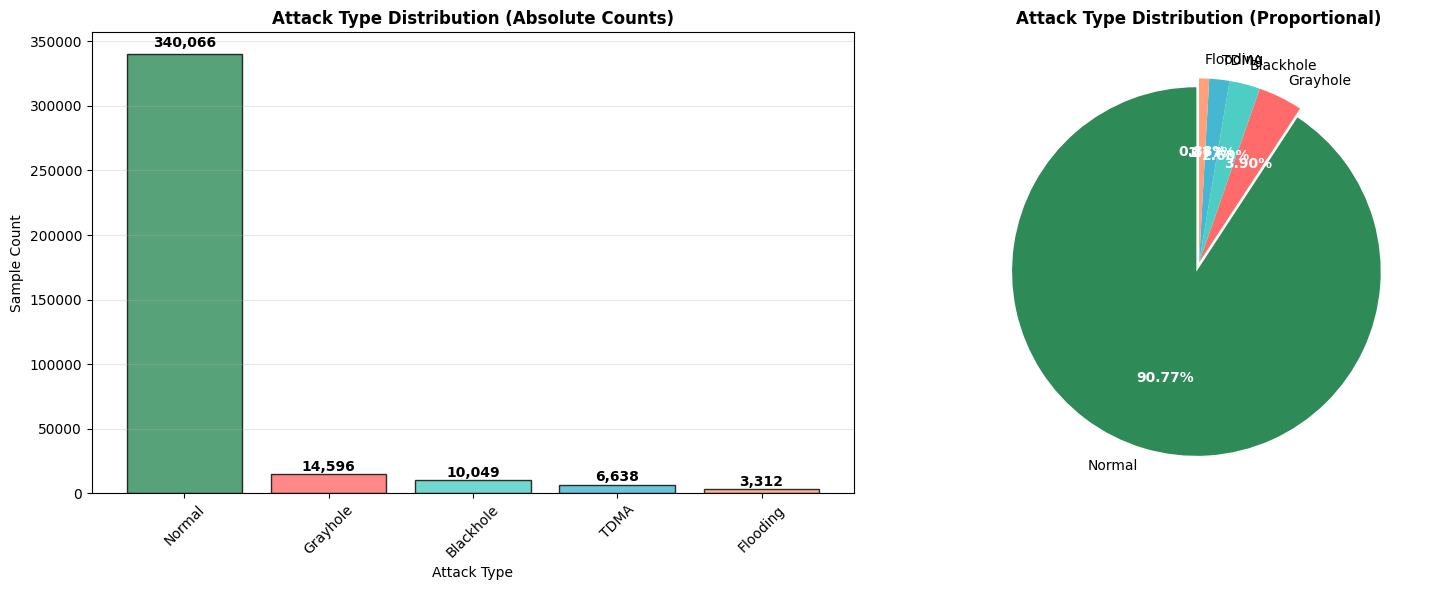


Attack categorization by frequency:
   Normal traffic: 340,066 samples (90.77%)
   Attack traffic: 34,595 samples (9.23%)

Attack type severity ranking (by rarity):
   1. Flooding    :  3,312 samples (Critical priority)
   2. TDMA        :  6,638 samples (Critical priority)
   3. Blackhole   : 10,049 samples (High priority)
   4. Grayhole    : 14,596 samples (High priority)


In [4]:
# Target Variable Distribution Analysis
print("Attack Type Distribution and Class Balance Analysis")
print("=" * 50)

# Calculate attack type distribution
attack_counts = df['Attack type'].value_counts()
attack_percent = df['Attack type'].value_counts(normalize=True) * 100

print("Attack type distribution:")
for attack_type, count in attack_counts.items():
    percentage = attack_percent[attack_type]
    print(f"   {attack_type:<12}: {count:>8,} samples ({percentage:>5.2f}%)")

# Class imbalance assessment
imbalance_ratio = attack_counts.max() / attack_counts.min()
print(f"\nClass imbalance metrics:")
print(f"   Majority class: {attack_counts.index[0]} ({attack_counts.iloc[0]:,} samples)")
print(f"   Minority class: {attack_counts.index[-1]} ({attack_counts.iloc[-1]:,} samples)")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 10:
    print(f"   Assessment: Severe class imbalance detected - specialized techniques required")
else:
    print(f"   Assessment: Moderate class distribution - standard techniques applicable")

# Visualization of attack type distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot with enhanced styling
colors = ['#2E8B57', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax1.bar(attack_counts.index, attack_counts.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('Attack Type Distribution (Absolute Counts)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Attack Type')
ax1.set_ylabel('Sample Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars, attack_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart with percentage labels
wedges, texts, autotexts = ax2.pie(attack_counts.values, labels=attack_counts.index, 
                                   autopct='%1.2f%%', colors=colors, startangle=90,
                                   explode=[0.05 if i == 0 else 0 for i in range(len(attack_counts))])
ax2.set_title('Attack Type Distribution (Proportional)', fontweight='bold', fontsize=12)

# Enhanced text formatting
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.tight_layout()
plt.show()

# Attack severity classification
print(f"\nAttack categorization by frequency:")
normal_count = attack_counts['Normal']
attack_classes = attack_counts.drop('Normal')

print(f"   Normal traffic: {normal_count:,} samples ({attack_percent['Normal']:.2f}%)")
print(f"   Attack traffic: {attack_classes.sum():,} samples ({attack_classes.sum()/len(df)*100:.2f}%)")

print(f"\nAttack type severity ranking (by rarity):")
for i, (attack_type, count) in enumerate(attack_classes.sort_values().items(), 1):
    severity = "Critical" if count < 10000 else "High" if count < 20000 else "Moderate"
    print(f"   {i}. {attack_type:<12}: {count:>6,} samples ({severity} priority)")

Feature Distribution and Statistical Analysis
Analyzing 9 key features for distribution characteristics:


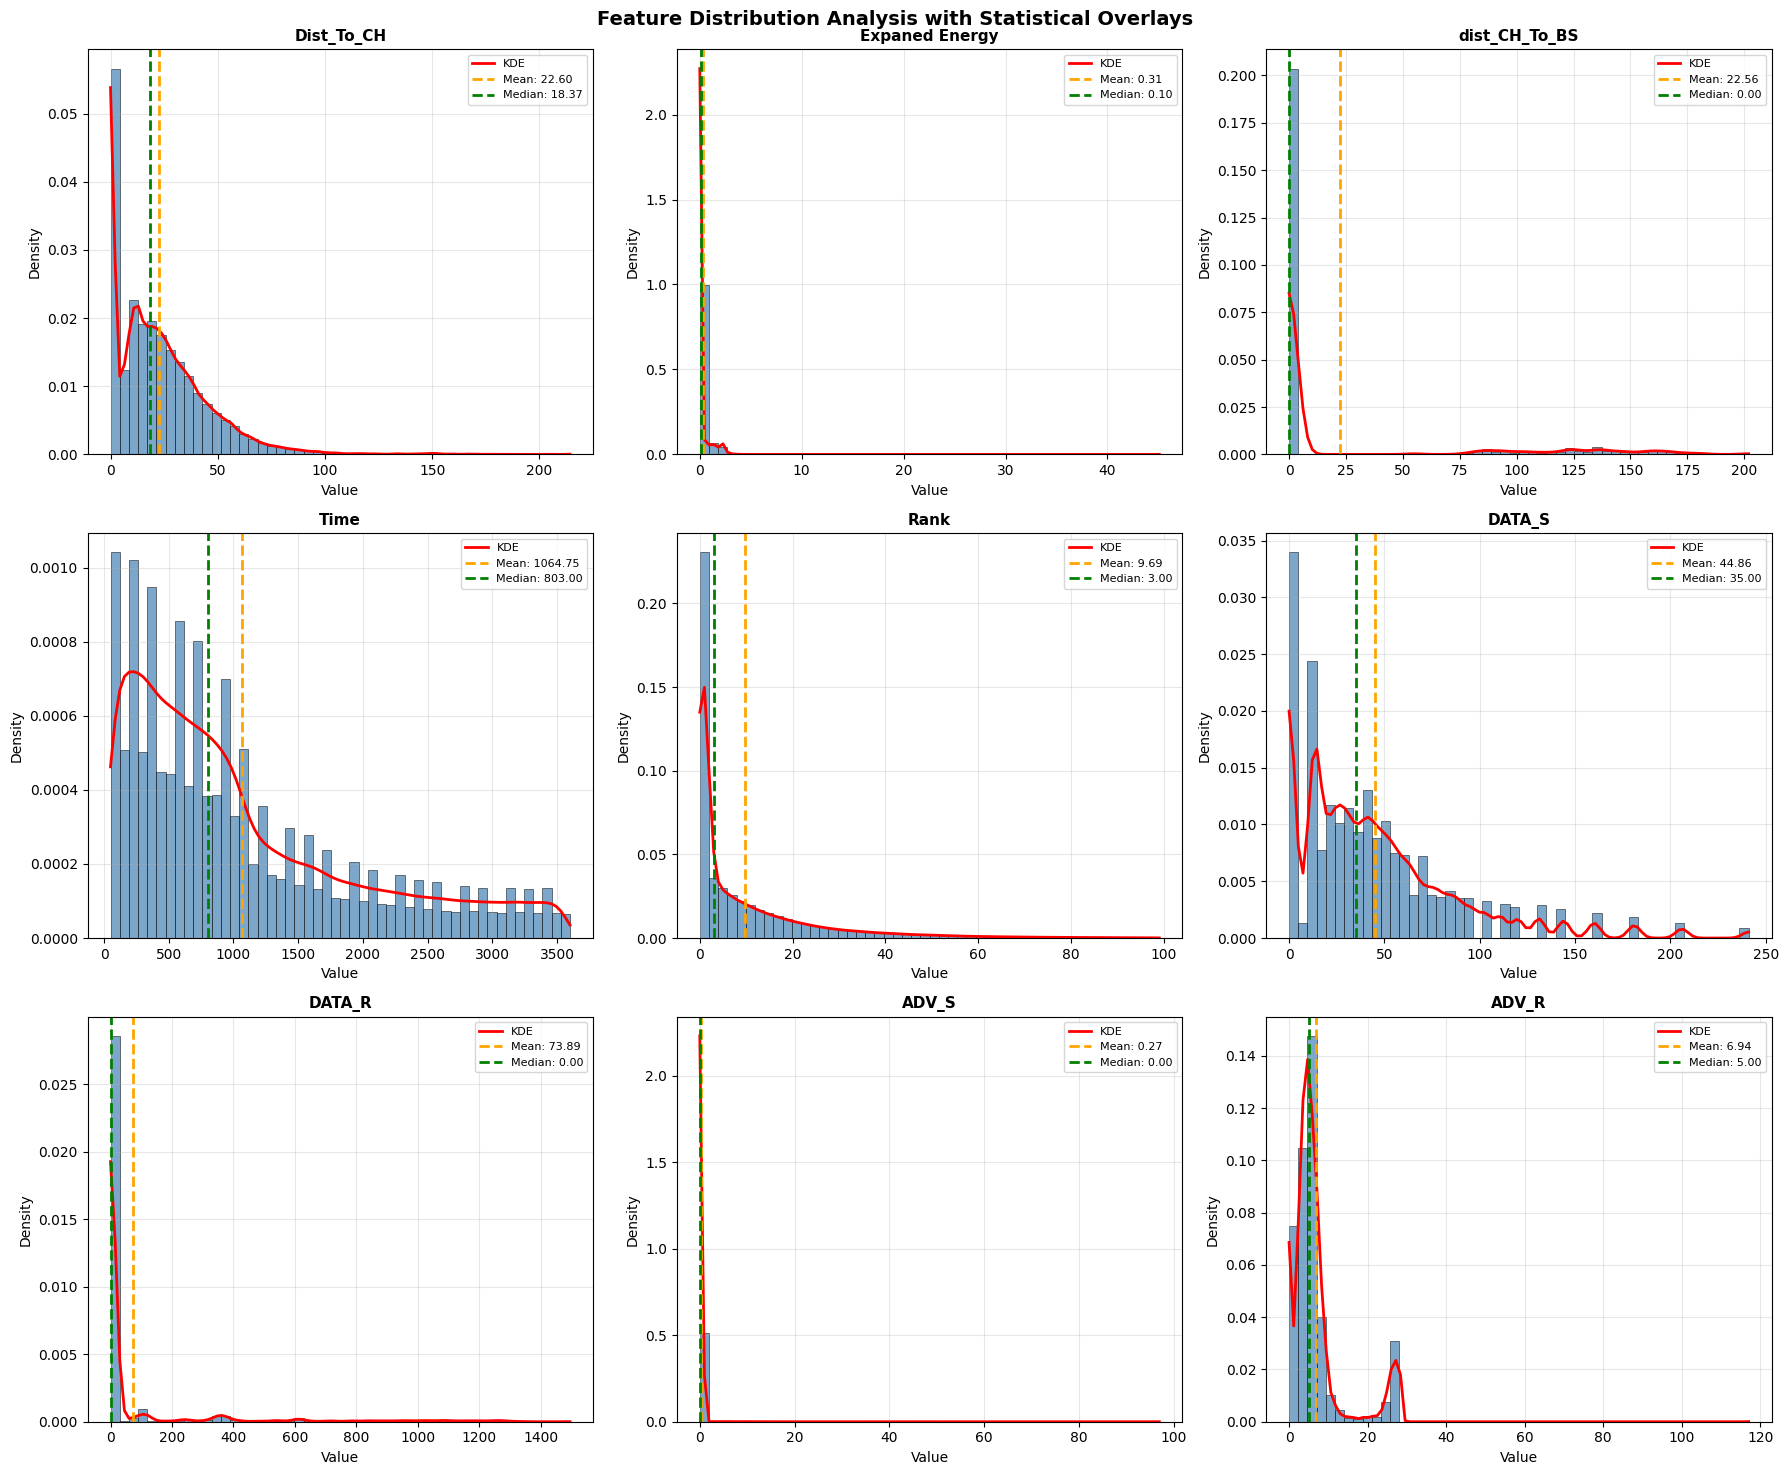


Outlier Detection Analysis:
-------------------------


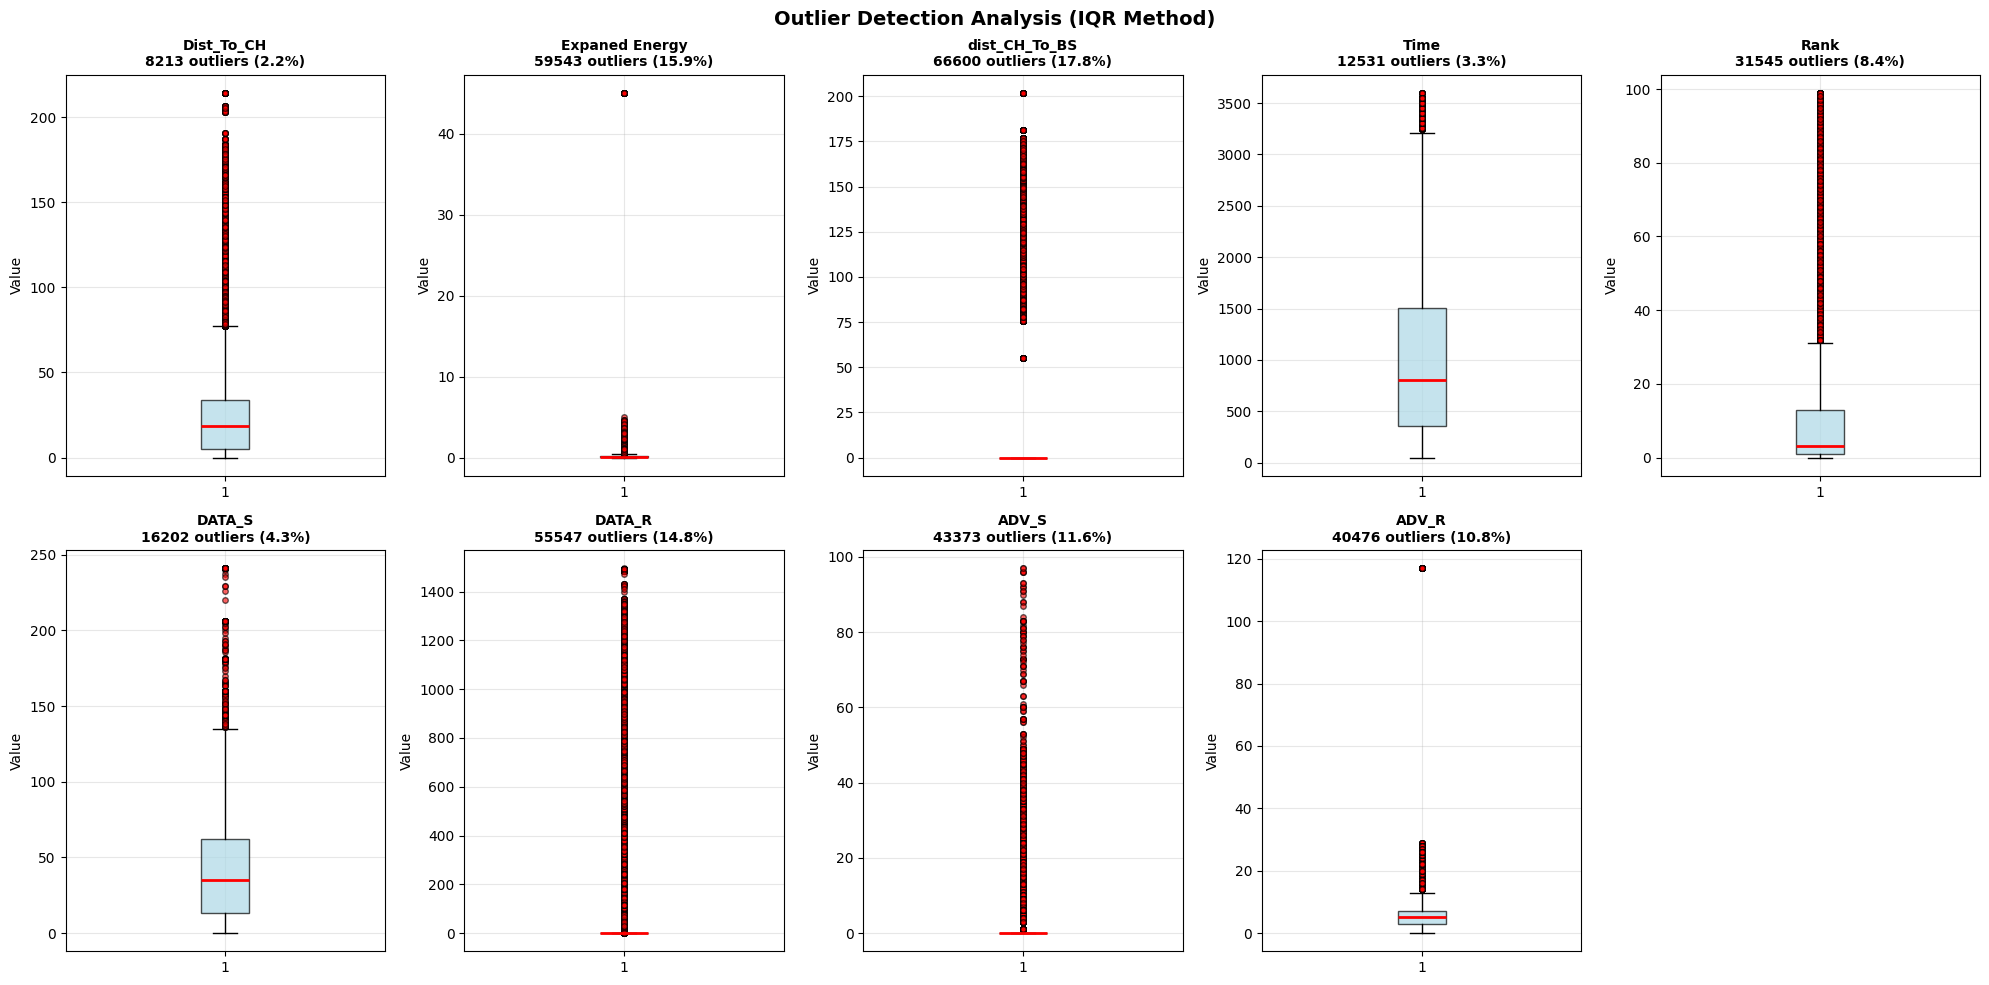

Statistical summary of key features:

Dist_To_CH:
   Range: [0.00, 214.27]
   Mean ± Std: 22.60 ± 21.96
   Median (IQR): 18.37 (4.74, 33.78)
   Skewness: 1.663
   Outliers: 8213 (2.2%)

Expaned Energy:
   Range: [0.00, 45.09]
   Mean ± Std: 0.31 ± 0.67
   Median (IQR): 0.10 (0.06, 0.22)
   Skewness: 25.410
   Outliers: 59543 (15.9%)

dist_CH_To_BS:
   Range: [0.00, 201.93]
   Mean ± Std: 22.56 ± 50.26
   Median (IQR): 0.00 (0.00, 0.00)
   Skewness: 1.941
   Outliers: 66600 (17.8%)

Time:
   Range: [50.00, 3,600.00]
   Mean ± Std: 1,064.75 ± 899.65
   Median (IQR): 803.00 (353.00, 1,503.00)
   Skewness: 1.096
   Outliers: 12531 (3.3%)

Rank:
   Range: [0.00, 99.00]
   Mean ± Std: 9.69 ± 14.68
   Median (IQR): 3.00 (1.00, 13.00)
   Skewness: 2.396
   Outliers: 31545 (8.4%)

DATA_S:
   Range: [0.00, 241.00]
   Mean ± Std: 44.86 ± 42.57
   Median (IQR): 35.00 (13.00, 62.00)
   Skewness: 1.566
   Outliers: 16202 (4.3%)

DATA_R:
   Range: [0.00, 1,496.00]
   Mean ± Std: 73.89 ± 230.25
   Med

In [5]:
# Feature Distribution Analysis and Statistical Characterization
print("Feature Distribution and Statistical Analysis")
print("=" * 42)

# Select key features for detailed analysis
key_features = ['Dist_To_CH', 'Expaned Energy', 'dist_CH_To_BS', 'Time', 'Rank', 
                'DATA_S', 'DATA_R', 'ADV_S', 'ADV_R']

print(f"Analyzing {len(key_features)} key features for distribution characteristics:")

# Distribution analysis with visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    data = df[feature].dropna()
    
    # Histogram with KDE overlay
    axes[i].hist(data, bins=50, alpha=0.7, color='steelblue', density=True, edgecolor='black', linewidth=0.5)
    
    # Kernel density estimation
    if len(data) > 1 and data.std() > 0:
        x_vals = np.linspace(data.min(), data.max(), 100)
        kde = stats.gaussian_kde(data)
        axes[i].plot(x_vals, kde(x_vals), 'red', linewidth=2, label='KDE')
    
    # Statistical annotations
    mean_val = data.mean()
    median_val = data.median()
    axes[i].axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    
    axes[i].set_title(f'{feature}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distribution Analysis with Statistical Overlays', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Outlier detection using box plots
print(f"\nOutlier Detection Analysis:")
print("-" * 25)

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

outlier_summary = {}

for i, feature in enumerate(key_features):
    data = df[feature].dropna()
    
    # Calculate IQR-based outliers
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_percentage = (len(outliers) / len(data)) * 100
    
    outlier_summary[feature] = {
        'count': len(outliers),
        'percentage': outlier_percentage,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    
    # Box plot visualization
    box_plot = axes[i].boxplot(data, patch_artist=True, 
                              boxprops=dict(facecolor='lightblue', alpha=0.7),
                              medianprops=dict(color='red', linewidth=2),
                              flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
    
    axes[i].set_title(f'{feature}\n{len(outliers)} outliers ({outlier_percentage:.1f}%)', 
                     fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

# Remove extra subplot
axes[9].remove()

plt.suptitle('Outlier Detection Analysis (IQR Method)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Statistical summary table
print(f"Statistical summary of key features:")
for feature in key_features:
    data = df[feature]
    outlier_info = outlier_summary[feature]
    
    print(f"\n{feature}:")
    print(f"   Range: [{data.min():,.2f}, {data.max():,.2f}]")
    print(f"   Mean ± Std: {data.mean():,.2f} ± {data.std():,.2f}")
    print(f"   Median (IQR): {data.median():,.2f} ({data.quantile(0.25):,.2f}, {data.quantile(0.75):,.2f})")
    print(f"   Skewness: {stats.skew(data):.3f}")
    print(f"   Outliers: {outlier_info['count']} ({outlier_info['percentage']:.1f}%)")

print(f"\nFeature distribution analysis complete.")

Feature Correlation and Relationship Analysis
Analyzing correlations among 18 numerical features


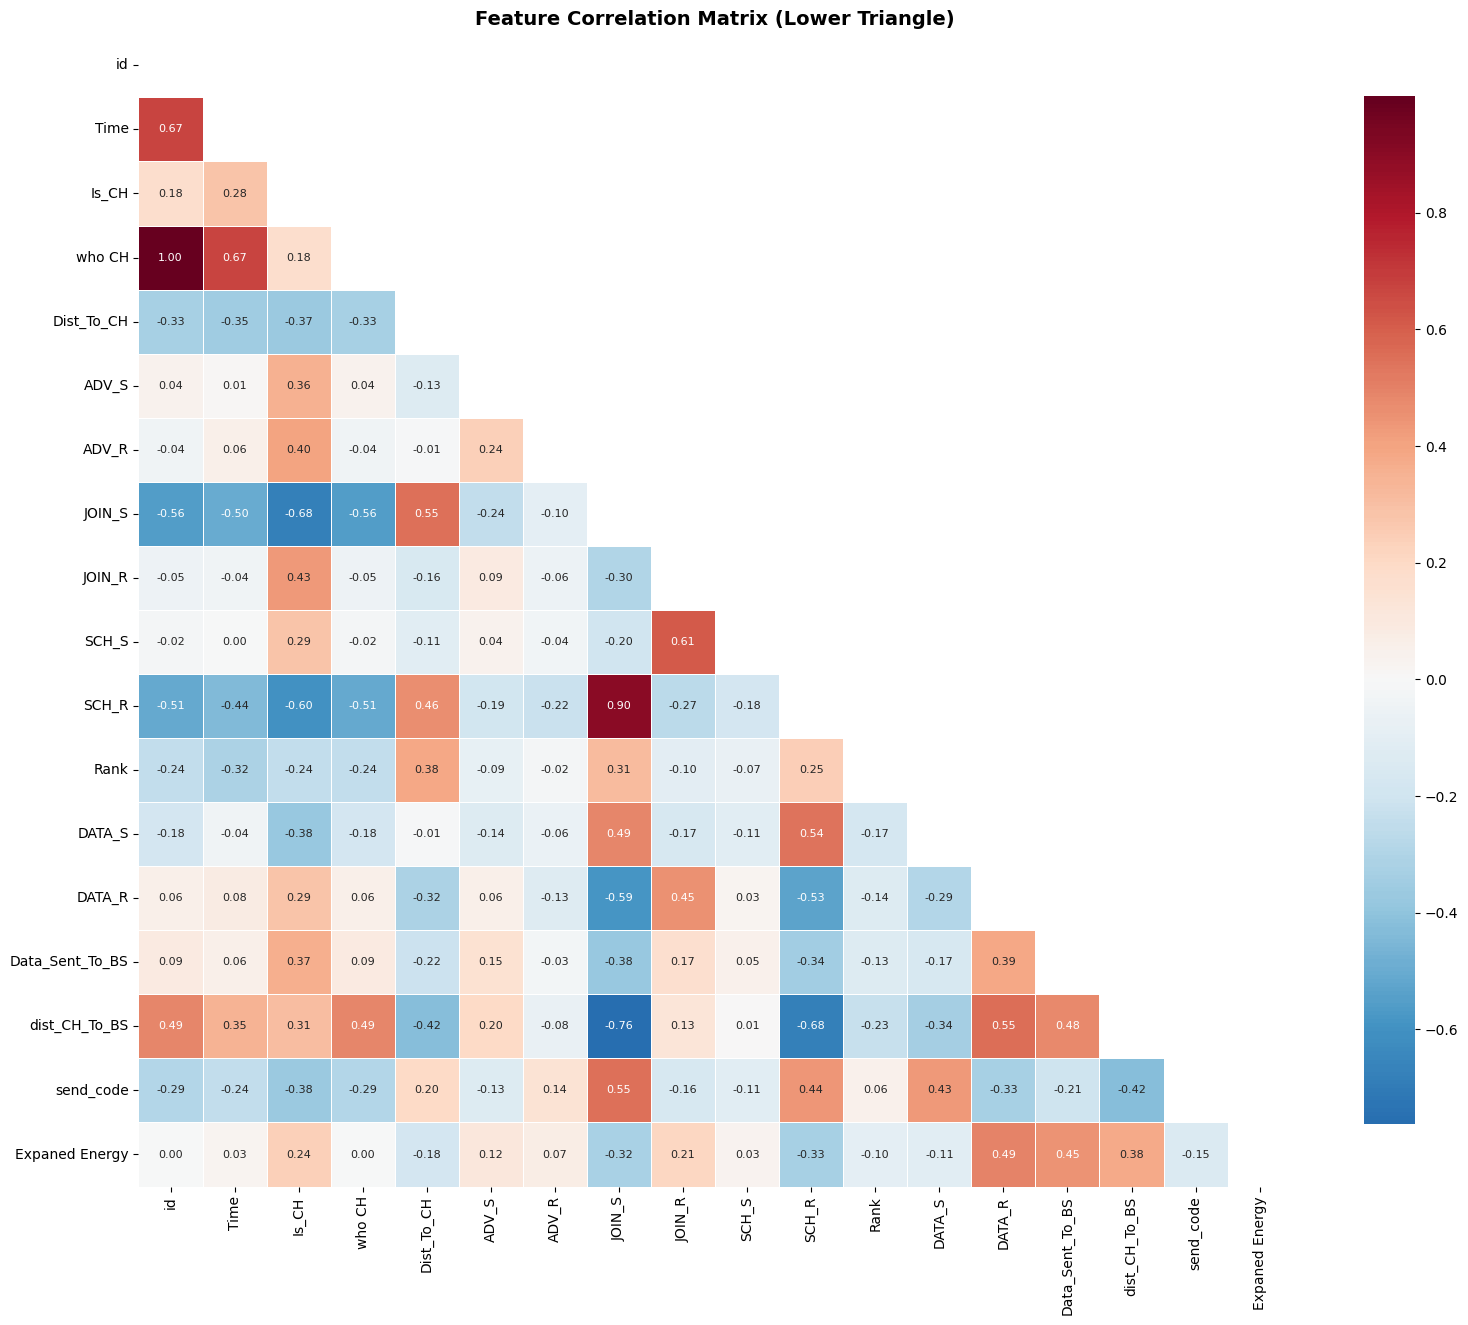


High Correlation Feature Pair Analysis:
--------------------------------------
Found 2 feature pairs with |correlation| > 0.8:
   id           ↔ who CH      :  1.000 (Perfect)
   JOIN_S       ↔ SCH_R       :  0.898 (Strong)

Feature-Target Relationship Analysis:
-----------------------------------
Top features by correlation with attack type:
    1. Is_CH          : -0.590 (Negative, Strong)
    2. ADV_R          : -0.406 (Negative, Moderate)
    3. JOIN_S         :  0.402 (Positive, Moderate)
    4. SCH_R          :  0.346 (Positive, Moderate)
    5. ADV_S          : -0.321 (Negative, Moderate)
    6. Time           : -0.251 (Negative, Weak)
    7. DATA_S         :  0.225 (Positive, Weak)
    8. send_code      :  0.222 (Positive, Weak)
    9. Dist_To_CH     :  0.220 (Positive, Weak)
   10. DATA_R         : -0.186 (Negative, Weak)

Correlation Analysis Summary:
----------------------------
   Feature pairs analyzed: 153
   Mean absolute correlation: 0.256
   Max correlation: 1.000
   

In [6]:
# Correlation Analysis and Feature Relationship Assessment
print("Feature Correlation and Relationship Analysis")
print("=" * 42)

# Calculate correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"Analyzing correlations among {len(numerical_cols)} numerical features")

corr_matrix = df[numerical_cols].corr()

# Create comprehensive correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Generate heatmap with enhanced styling
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, 
            fmt='.2f', annot_kws={'size': 8})

plt.title('Feature Correlation Matrix (Lower Triangle)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
print(f"\nHigh Correlation Feature Pair Analysis:")
print("-" * 38)

high_corr_pairs = []
correlation_threshold = 0.8

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > correlation_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} feature pairs with |correlation| > {correlation_threshold}:")
    for feature1, feature2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        correlation_strength = "Perfect" if abs(corr_val) > 0.99 else "Very Strong" if abs(corr_val) > 0.9 else "Strong"
        print(f"   {feature1:<12} ↔ {feature2:<12}: {corr_val:>6.3f} ({correlation_strength})")
else:
    print(f"No highly correlated feature pairs found (threshold: {correlation_threshold})")

# Feature-target relationship analysis using label encoding for correlation
print(f"\nFeature-Target Relationship Analysis:")
print("-" * 35)

# Encode target variable for correlation analysis
le_temp = LabelEncoder()
y_encoded_corr = le_temp.fit_transform(df['Attack type'])

# Calculate correlations with target
target_correlations = []
for col in numerical_cols:
    if col != 'Attack type':  # Skip if exists in numerical cols
        corr_val = np.corrcoef(df[col], y_encoded_corr)[0, 1]
        if not np.isnan(corr_val):
            target_correlations.append((col, abs(corr_val), corr_val))

# Sort by absolute correlation strength
target_correlations.sort(key=lambda x: x[1], reverse=True)

print("Top features by correlation with attack type:")
for i, (feature, abs_corr, corr_val) in enumerate(target_correlations[:10], 1):
    direction = "Positive" if corr_val > 0 else "Negative"
    strength = "Strong" if abs_corr > 0.5 else "Moderate" if abs_corr > 0.3 else "Weak"
    print(f"   {i:2d}. {feature:<15}: {corr_val:>6.3f} ({direction}, {strength})")

# Correlation summary statistics
print(f"\nCorrelation Analysis Summary:")
print("-" * 28)

# Calculate correlation distribution statistics
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlations_flat = upper_triangle.stack().values

print(f"   Feature pairs analyzed: {len(correlations_flat):,}")
print(f"   Mean absolute correlation: {np.mean(np.abs(correlations_flat)):.3f}")
print(f"   Max correlation: {np.max(np.abs(correlations_flat)):.3f}")
print(f"   Highly correlated pairs (|r| > 0.8): {len(high_corr_pairs)}")
print(f"   Feature redundancy assessment: {'High' if len(high_corr_pairs) > 2 else 'Moderate' if len(high_corr_pairs) > 0 else 'Low'}")

print(f"\nCorrelation analysis complete")

Attack Pattern Analysis and Behavioral Characterization
Analyzing attack patterns across 8 discriminative features


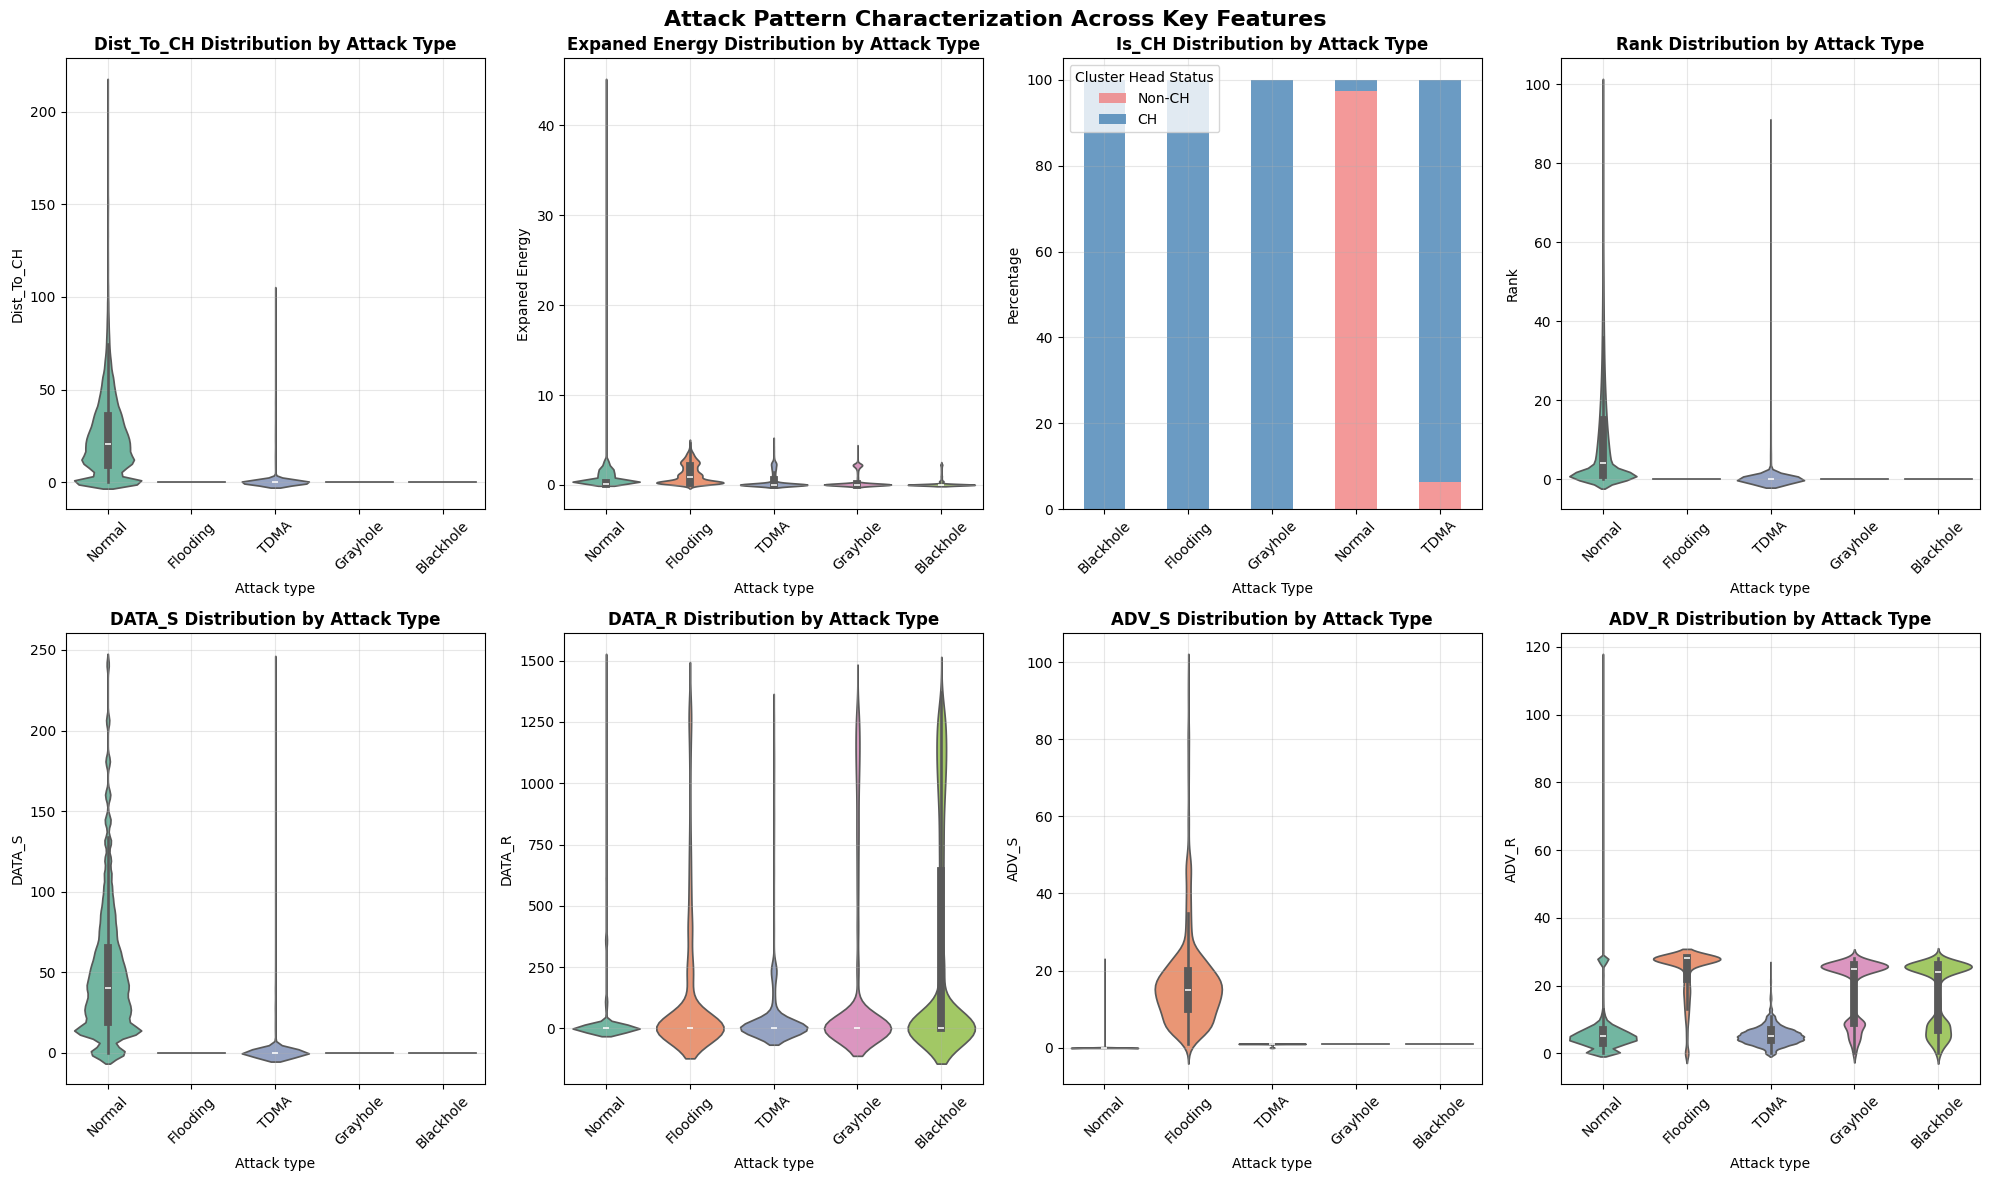


Statistical Attack Pattern Analysis:
Sample sizes: Normal=340,066, Attack=34,595

Dist_To_CH:
   Normal: μ=  24.864, σ=  21.775
   Attack: μ=   0.341, σ=   3.723
   Difference:   24.522
   Statistical test: p=0.00e+00 (Highly Significant)
   Effect size: 1.570 (Large)

Expaned Energy:
   Normal: μ=   0.289, σ=   0.647
   Attack: μ=   0.469, σ=   0.846
   Difference:    0.180
   Statistical test: p=0.00e+00 (Highly Significant)
   Effect size: 0.239 (Small)

Rank:
   Normal: μ=  10.650, σ=  15.056
   Attack: μ=   0.218, σ=   2.726
   Difference:   10.433
   Statistical test: p=0.00e+00 (Highly Significant)
   Effect size: 0.964 (Large)

DATA_S:
   Normal: μ=  49.361, σ=  42.102
   Attack: μ=   0.592, σ=   6.883
   Difference:   48.769
   Statistical test: p=0.00e+00 (Highly Significant)
   Effect size: 1.617 (Large)

DATA_R:
   Normal: μ=  62.102, σ= 205.313
   Attack: μ= 189.764, σ= 380.757
   Difference:  127.662
   Statistical test: p=0.00e+00 (Highly Significant)
   Effect size: 0.

In [7]:
# Attack Pattern Characterization and Behavioral Analysis
print("Attack Pattern Analysis and Behavioral Characterization")
print("=" * 55)

# Comprehensive attack-feature relationship analysis
discriminative_features = ['Dist_To_CH', 'Expaned Energy', 'Is_CH', 'Rank', 
                          'DATA_S', 'DATA_R', 'ADV_S', 'ADV_R']

print(f"Analyzing attack patterns across {len(discriminative_features)} discriminative features")

# Create attack pattern visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feature in enumerate(discriminative_features):
    if feature == 'Is_CH':
        # For binary feature, use grouped bar plot
        ch_attack_data = df.groupby(['Attack type', 'Is_CH']).size().unstack(fill_value=0)
        ch_attack_pct = ch_attack_data.div(ch_attack_data.sum(axis=1), axis=0) * 100
        
        ch_attack_pct.plot(kind='bar', ax=axes[i], stacked=True, 
                          color=['lightcoral', 'steelblue'], alpha=0.8)
        axes[i].set_title(f'{feature} Distribution by Attack Type', fontweight='bold')
        axes[i].set_xlabel('Attack Type')
        axes[i].set_ylabel('Percentage')
        axes[i].legend(['Non-CH', 'CH'], title='Cluster Head Status')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        # For continuous features, use violin plot
        sns.violinplot(data=df, x='Attack type', y=feature, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{feature} Distribution by Attack Type', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Attack Pattern Characterization Across Key Features', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# Statistical comparison between Normal and Attack patterns
print(f"\nStatistical Attack Pattern Analysis:")
print("=" * 35)

normal_data = df[df['Attack type'] == 'Normal']
attack_data = df[df['Attack type'] != 'Normal']

print(f"Sample sizes: Normal={len(normal_data):,}, Attack={len(attack_data):,}")

comparison_features = ['Dist_To_CH', 'Expaned Energy', 'Rank', 'DATA_S', 'DATA_R', 'ADV_S']

statistical_results = []

for feature in comparison_features:
    normal_vals = normal_data[feature]
    attack_vals = attack_data[feature]
    
    # Calculate descriptive statistics
    normal_mean = normal_vals.mean()
    attack_mean = attack_vals.mean()
    normal_std = normal_vals.std()
    attack_std = attack_vals.std()
    
    # Perform statistical test
    t_stat, p_value = stats.ttest_ind(normal_vals, attack_vals)
    effect_size = abs(normal_mean - attack_mean) / np.sqrt((normal_std**2 + attack_std**2) / 2)  # Cohen's d
    
    statistical_results.append({
        'feature': feature,
        'normal_mean': normal_mean,
        'attack_mean': attack_mean,
        'difference': abs(normal_mean - attack_mean),
        'p_value': p_value,
        'effect_size': effect_size,
        'significant': p_value < 0.001
    })
    
    significance = "Highly Significant" if p_value < 0.001 else "Significant" if p_value < 0.05 else "Not Significant"
    effect_interpretation = "Large" if effect_size > 0.8 else "Medium" if effect_size > 0.5 else "Small"
    
    print(f"\n{feature}:")
    print(f"   Normal: μ={normal_mean:8.3f}, σ={normal_std:8.3f}")
    print(f"   Attack: μ={attack_mean:8.3f}, σ={attack_std:8.3f}")
    print(f"   Difference: {abs(normal_mean - attack_mean):8.3f}")
    print(f"   Statistical test: p={p_value:.2e} ({significance})")
    print(f"   Effect size: {effect_size:.3f} ({effect_interpretation})")

# Attack-specific pattern analysis
print(f"\nAttack-Specific Pattern Analysis:")
print("=" * 32)

attack_types = df['Attack type'].unique()
attack_types = [at for at in attack_types if at != 'Normal']

# Key discriminative feature analysis per attack type
key_features_analysis = ['Dist_To_CH', 'Expaned Energy', 'Is_CH', 'Rank']

attack_patterns = {}
for attack_type in attack_types:
    attack_subset = df[df['Attack type'] == attack_type]
    
    pattern_analysis = {}
    for feature in key_features_analysis:
        if feature == 'Is_CH':
            ch_percentage = (attack_subset[feature] == 1).mean() * 100
            pattern_analysis[feature] = f"{ch_percentage:.1f}% cluster heads"
        else:
            mean_val = attack_subset[feature].mean()
            pattern_analysis[feature] = f"{mean_val:.3f}"
    
    attack_patterns[attack_type] = pattern_analysis

# Display attack pattern summary
for attack_type, patterns in attack_patterns.items():
    print(f"\n{attack_type} Attack Characteristics:")
    for feature, pattern in patterns.items():
        print(f"   {feature:<15}: {pattern}")

# Network topology analysis
print(f"\nNetwork Topology Attack Targeting Analysis:")
print("=" * 42)

ch_targeting = df.groupby('Attack type')['Is_CH'].agg(['mean', 'count'])
ch_targeting['ch_percentage'] = ch_targeting['mean'] * 100

print("Cluster Head targeting preferences by attack type:")
for attack_type in ch_targeting.index:
    ch_pct = ch_targeting.loc[attack_type, 'ch_percentage']
    sample_count = ch_targeting.loc[attack_type, 'count']
    targeting_level = "Exclusive" if ch_pct > 95 else "High" if ch_pct > 80 else "Moderate" if ch_pct > 50 else "Low"
    
    print(f"   {attack_type:<12}: {ch_pct:5.1f}% CH targeting ({targeting_level}) | n={sample_count:,}")

# Temporal attack pattern analysis
print(f"\nTemporal Attack Pattern Analysis:")
print("=" * 30)

time_attack_analysis = df.groupby(['Time', 'Attack type']).size().unstack(fill_value=0)

# Calculate attack activity trends
attack_cols = [col for col in time_attack_analysis.columns if col != 'Normal']
total_attacks_by_time = time_attack_analysis[attack_cols].sum(axis=1)

print(f"Time range: {df['Time'].min()} - {df['Time'].max()}")
print(f"Peak attack period: Time {total_attacks_by_time.idxmax()} ({total_attacks_by_time.max()} attacks)")
print(f"Attack activity trend: {'Decreasing' if total_attacks_by_time.iloc[-1] < total_attacks_by_time.iloc[0] else 'Increasing'}")

print(f"\nAttack pattern characterization complete.")
print(f"Distinct behavioral signatures identified for each attack type.")
print(f"Statistical significance confirmed for key discriminative features.")

In [8]:
# Load the WSN-DS dataset
df = pd.read_csv('data/WSN-DS.csv')
df.columns = df.columns.str.strip()

print(f"Dataset dimensions: {df.shape[0]:,} samples, {df.shape[1]} features")
print(f"\nClass distribution analysis:")

# Analyze attack type distribution
attack_counts = df['Attack type'].value_counts()
attack_percent = df['Attack type'].value_counts(normalize=True) * 100

for attack_type, count in attack_counts.items():
    percentage = attack_percent[attack_type]
    print(f"   {attack_type}: {count:,} samples ({percentage:.2f}%)")

# Calculate class imbalance ratio
imbalance_ratio = attack_counts.max() / attack_counts.min()
print(f"\nImbalance ratio (majority:minority): {imbalance_ratio:.2f}:1")

# Data cleaning: remove duplicate entries
original_size = len(df)
df_clean = df.drop_duplicates()
removed_duplicates = original_size - len(df_clean)

# Step 1: Remove redundant features identified during correlation analysis
redundant_features = ['id', 'who CH']  # Features with perfect correlation
print(f"Removing redundant features: {redundant_features}")
df_features = df_clean.drop(columns=redundant_features)


print(f"\nData cleaning summary:")
print(f"   Duplicate records removed: {removed_duplicates:,}")
print(f"   Final dataset size: {len(df_clean):,} samples")

df = df_clean.copy()

Dataset dimensions: 374,661 samples, 19 features

Class distribution analysis:
   Normal: 340,066 samples (90.77%)
   Grayhole: 14,596 samples (3.90%)
   Blackhole: 10,049 samples (2.68%)
   TDMA: 6,638 samples (1.77%)
   Flooding: 3,312 samples (0.88%)

Imbalance ratio (majority:minority): 102.68:1
Removing redundant features: ['id', 'who CH']

Data cleaning summary:
   Duplicate records removed: 8,873
   Final dataset size: 365,788 samples


In [209]:
# Data Preparation for Machine Learning
print("Data Preparation and Preprocessing")
print("=" * 40)

# Separate features and target variable
X = df_features.drop('Attack type', axis=1)
y = df_features['Attack type']

# Encode categorical target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Feature matrix dimensions: {X.shape}")
print(f"Target variable encoded classes:")
for i, class_name in enumerate(label_encoder.classes_):
    count = np.sum(y_encoded == i)
    percentage = (count / len(y_encoded)) * 100
    print(f"   {i}: {class_name} - {count:,} samples ({percentage:.2f}%)")

# Data quality validation
print(f"\nData quality assessment:")
X_numeric = X.select_dtypes(include=[np.number])

# Handle non-numeric columns if present
if X_numeric.shape[1] != X.shape[1]:
    print("   Converting non-numeric features to numeric...")
    for col in X.columns:
        if X[col].dtype == 'category' or X[col].dtype == 'object':
            X[col] = pd.to_numeric(X[col], errors='coerce')
    X_numeric = X

# Check for infinite and NaN values
inf_mask = np.isinf(X_numeric.values).any(axis=1)
nan_mask = np.isnan(X_numeric.values).any(axis=1)
problematic_rows = inf_mask | nan_mask

if problematic_rows.sum() > 0:
    print(f"   Removing {problematic_rows.sum():,} rows with invalid values")
    X = X_numeric[~problematic_rows]
    y_encoded = y_encoded[~problematic_rows]
    print(f"   Clean dataset dimensions: {X.shape}")
else:
    print("   No invalid values detected")
    X = X_numeric

# Stratified train-test split
print(f"\nDataset partitioning:")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"   Training set: {X_train.shape[0]:,} samples")
print(f"   Test set: {X_test.shape[0]:,} samples")

# Verify stratification
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print(f"\nClass distribution preservation:")
for i, class_name in enumerate(label_encoder.classes_):
    train_pct = (train_dist[i] / len(y_train)) * 100
    test_pct = (test_dist[i] / len(y_test)) * 100
    print((test_dist[i]))
    print(f"   {class_name}: Train {train_pct:.2f}%, Test {test_pct:.2f}%")

# Feature scaling
print(f"\nFeature standardization:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   StandardScaler applied to {X_train_scaled.shape[1]} features")
print(f"   Training features shape: {X_train_scaled.shape}")
print(f"   Test features shape: {X_test_scaled.shape}")

Data Preparation and Preprocessing
Feature matrix dimensions: (365788, 16)
Target variable encoded classes:
   0: Blackhole - 10,049 samples (2.75%)
   1: Flooding - 3,157 samples (0.86%)
   2: Grayhole - 13,909 samples (3.80%)
   3: Normal - 332,040 samples (90.77%)
   4: TDMA - 6,633 samples (1.81%)

Data quality assessment:
   No invalid values detected

Dataset partitioning:
   Training set: 292,630 samples
   Test set: 73,158 samples

Class distribution preservation:
2010
   Blackhole: Train 2.75%, Test 2.75%
631
   Flooding: Train 0.86%, Test 0.86%
2782
   Grayhole: Train 3.80%, Test 3.80%
66408
   Normal: Train 90.77%, Test 90.77%
1327
   TDMA: Train 1.81%, Test 1.81%

Feature standardization:
   StandardScaler applied to 16 features
   Training features shape: (292630, 16)
   Test features shape: (73158, 16)


Imbalance Handling Strategy Implementation
Class weights for cost-sensitive learning:
   Blackhole: 7.280
   Flooding: 23.169
   Grayhole: 5.260
   Normal: 0.220
   TDMA: 11.030

Sampling Strategy Implementation:

1. SMOTE-ENN Hybrid Approach:
   Combines synthetic minority oversampling with edited nearest neighbors undersampling
   Original distribution: {np.int64(3): 265632, np.int64(0): 8039, np.int64(2): 11127, np.int64(4): 5306, np.int64(1): 2526}
   Post-SMOTE-ENN: {np.int64(0): 264819, np.int64(1): 265607, np.int64(2): 264778, np.int64(3): 260590, np.int64(4): 264507}
   Sample size change: 292,630 → 1,320,301

2. BorderlineSMOTE Implementation:
   Focuses synthetic sample generation on borderline minority instances
   Post-BorderlineSMOTE: {np.int64(3): 265632, np.int64(0): 265632, np.int64(2): 265632, np.int64(4): 265632, np.int64(1): 265632}
   Sample size change: 292,630 → 1,328,160

3. ADASYN Adaptive Sampling:
   Density-based adaptive synthetic sample generation
   Post-A

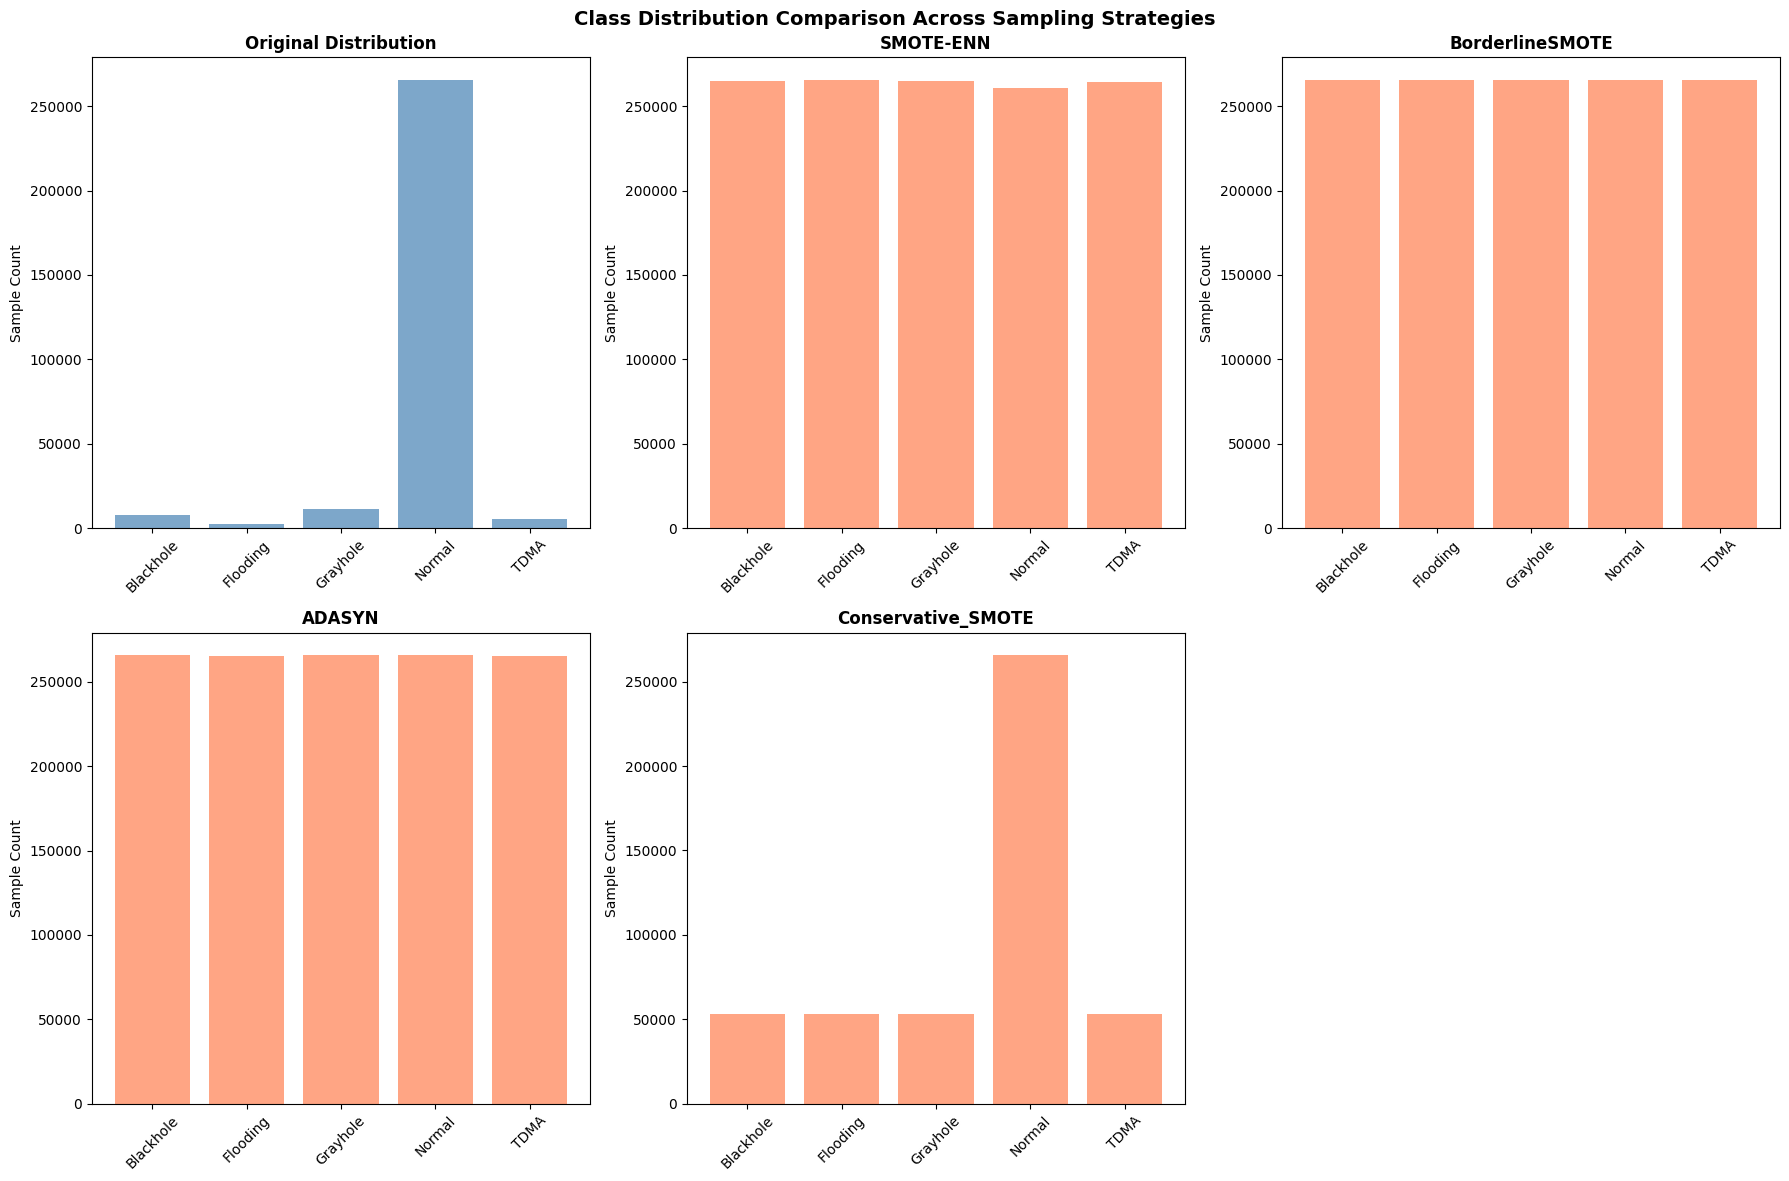

In [10]:
# Implementation of Advanced Sampling Strategies
print("Imbalance Handling Strategy Implementation")
print("=" * 45)

# Calculate dynamic class weights for cost-sensitive learning
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("Class weights for cost-sensitive learning:")
for class_idx, weight in class_weight_dict.items():
    class_name = label_encoder.classes_[class_idx]
    print(f"   {class_name}: {weight:.3f}")

# Preserve original training data for comparison
X_train_original = X_train_scaled.copy()
y_train_original = y_train.copy()

# Initialize sampling strategy storage
sampling_strategies = {}

print(f"\nSampling Strategy Implementation:")

# Strategy 1: Hybrid SMOTE-ENN
print(f"\n1. SMOTE-ENN Hybrid Approach:")
print("   Combines synthetic minority oversampling with edited nearest neighbors undersampling")
smote_enn = SMOTEENN(random_state=42, sampling_strategy='auto')
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train)
sampling_strategies['SMOTE-ENN'] = (X_smote_enn, y_smote_enn)

print(f"   Original distribution: {dict(Counter(y_train))}")
print(f"   Post-SMOTE-ENN: {dict(Counter(y_smote_enn))}")
print(f"   Sample size change: {len(y_train):,} → {len(y_smote_enn):,}")

# Strategy 2: BorderlineSMOTE
print(f"\n2. BorderlineSMOTE Implementation:")
print("   Focuses synthetic sample generation on borderline minority instances")
borderline_smote = BorderlineSMOTE(random_state=42, sampling_strategy='auto')
X_borderline, y_borderline = borderline_smote.fit_resample(X_train_scaled, y_train)
sampling_strategies['BorderlineSMOTE'] = (X_borderline, y_borderline)

print(f"   Post-BorderlineSMOTE: {dict(Counter(y_borderline))}")
print(f"   Sample size change: {len(y_train):,} → {len(y_borderline):,}")

# Strategy 3: ADASYN (Adaptive Synthetic Sampling)
print(f"\n3. ADASYN Adaptive Sampling:")
print("   Density-based adaptive synthetic sample generation")
adasyn = ADASYN(random_state=42, sampling_strategy='auto')
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
sampling_strategies['ADASYN'] = (X_adasyn, y_adasyn)

print(f"   Post-ADASYN: {dict(Counter(y_adasyn))}")
print(f"   Sample size change: {len(y_train):,} → {len(y_adasyn):,}")

# Strategy 4: Conservative SMOTE (Novel Approach)
print(f"\n4. Conservative SMOTE (Novel Conservative Strategy):")
print("   Limited oversampling to prevent synthetic data dominance")

def create_conservative_strategy(y_train):
    """Create conservative sampling strategy limiting minority class augmentation"""
    counts = Counter(y_train)
    majority_class_count = max(counts.values())
    # Limit minority classes to 20% of majority class size
    target_count = int(majority_class_count * 0.2)
    
    conservative_strategy = {}
    for class_label, count in counts.items():
        if count < target_count:
            conservative_strategy[class_label] = target_count
    return conservative_strategy

conservative_strategy = create_conservative_strategy(y_train)
smote_conservative = SMOTE(random_state=42, sampling_strategy=conservative_strategy)
X_conservative, y_conservative = smote_conservative.fit_resample(X_train_scaled, y_train)
sampling_strategies['Conservative_SMOTE'] = (X_conservative, y_conservative)

print(f"   Target distribution: {conservative_strategy}")
print(f"   Post-Conservative SMOTE: {dict(Counter(y_conservative))}")
print(f"   Sample size change: {len(y_train):,} → {len(y_conservative):,}")

print(f"\nSampling strategy implementation complete.")
print(f"Total strategies available: {len(sampling_strategies)}")

# Visualization of class distributions across strategies
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Original distribution
counts_orig = Counter(y_train)
classes = [label_encoder.classes_[i] for i in sorted(counts_orig.keys())]
counts_orig_values = [counts_orig[i] for i in sorted(counts_orig.keys())]

axes[0].bar(classes, counts_orig_values, color='steelblue', alpha=0.7)
axes[0].set_title('Original Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot each sampling strategy
for idx, (strategy_name, (X_resampled, y_resampled)) in enumerate(sampling_strategies.items(), 1):
    counts = Counter(y_resampled)
    counts_values = [counts[i] for i in sorted(counts.keys())]
    
    axes[idx].bar(classes, counts_values, color='coral', alpha=0.7)
    axes[idx].set_title(f'{strategy_name}', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Sample Count')
    axes[idx].tick_params(axis='x', rotation=45)

# Remove unused subplot
axes[5].remove()

plt.suptitle('Class Distribution Comparison Across Sampling Strategies', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

2D Visualization: Dataset Comparison Before and After Oversampling
Preparing data for dimensionality reduction...
Original dataset: 292,630 samples
Oversampled dataset: 1,320,301 samples
Sampled original data to 10,000 points for visualization
Sampled oversampled data to 10,000 points for visualization

Performing PCA dimensionality reduction...
PCA explained variance: PC1=0.315, PC2=0.114
Total explained variance: 0.428

Performing t-SNE dimensionality reduction...


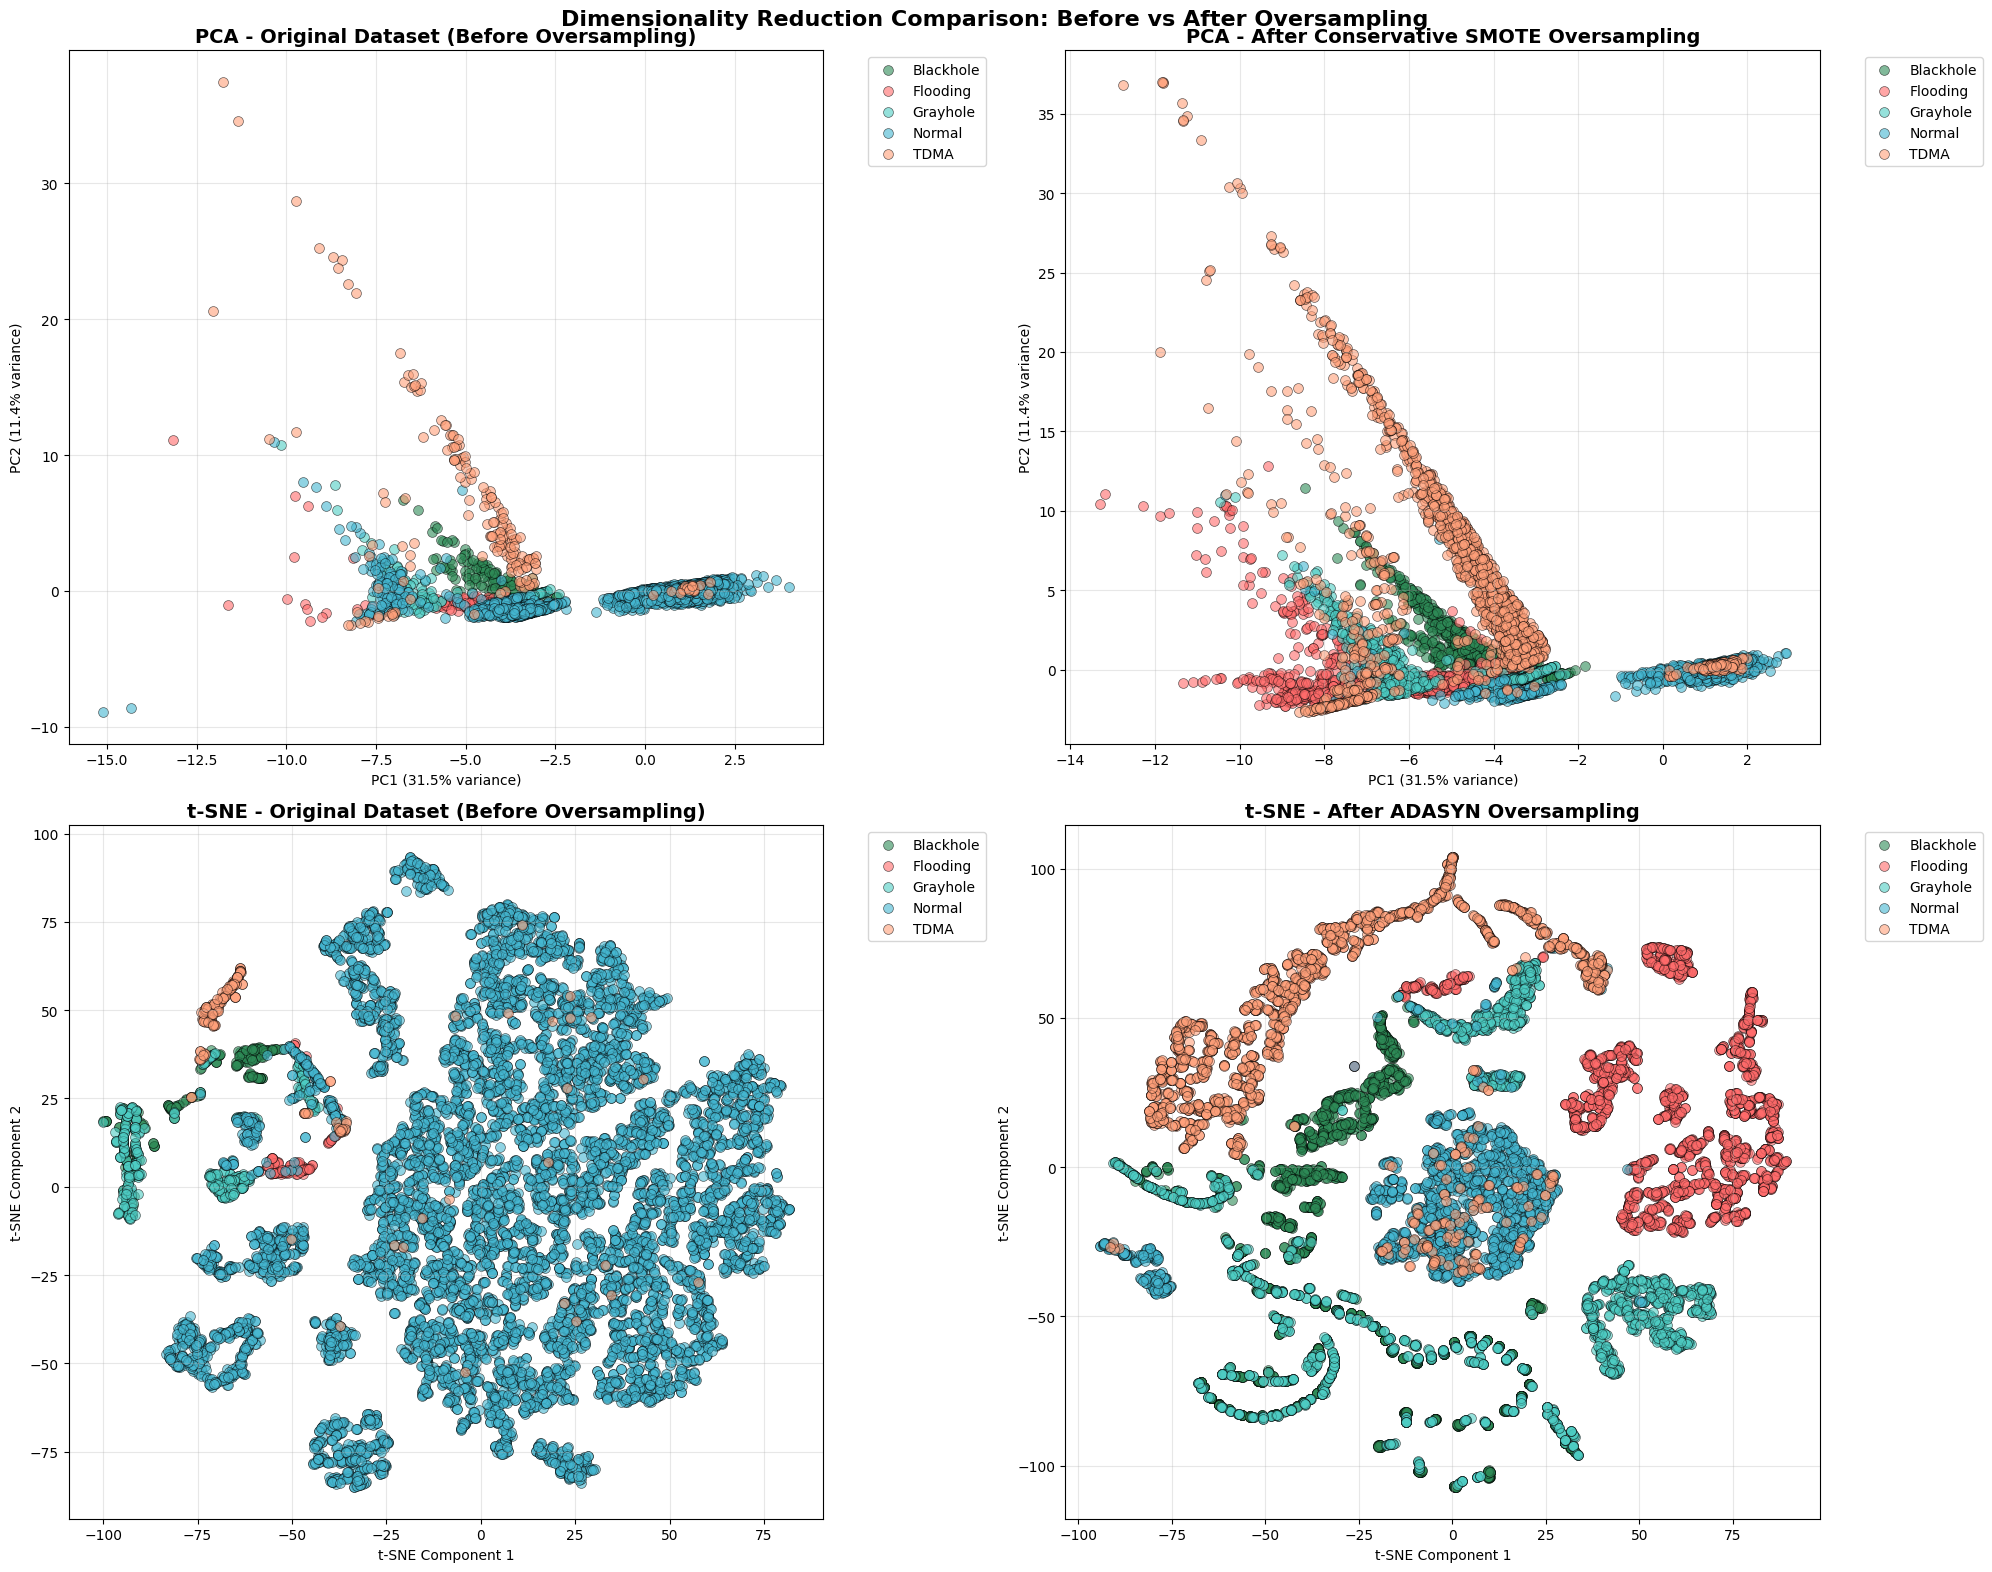


Class distribution analysis:
Original dataset distribution:
   Blackhole: 299 samples (3.0%)
   Flooding: 99 samples (1.0%)
   Grayhole: 376 samples (3.8%)
   Normal: 9,037 samples (90.4%)
   TDMA: 189 samples (1.9%)

Oversampled dataset distribution:
   Blackhole: 2,086 samples (20.9%)
   Flooding: 1,983 samples (19.8%)
   Grayhole: 2,062 samples (20.6%)
   Normal: 1,850 samples (18.5%)
   TDMA: 2,019 samples (20.2%)

Cluster Analysis:
Original data silhouette scores:
   PCA: 0.502
   t-SNE: 0.017

Oversampled data silhouette scores:
   PCA: 0.104
   t-SNE: 0.163

Visualization complete!
Key observations:
   • PCA preserves global structure and linear relationships
   • t-SNE reveals local neighborhood structures and clusters
   • Oversampling increases minority class representation in feature space
   • Conservative SMOTE maintains reasonable cluster boundaries


In [98]:
# Dimensionality Reduction Visualization: Before vs After Oversampling
print("2D Visualization: Dataset Comparison Before and After Oversampling")
print("=" * 65)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data for visualization
print("Preparing data for dimensionality reduction...")

# Original training data (before oversampling)
X_original = X_train_scaled.copy()
y_original = y_train.copy()

# Select one oversampling strategy for comparison (Conservative SMOTE as it's our novel approach)
X_oversampled, y_oversampled = sampling_strategies['SMOTE-ENN']

print(f"Original dataset: {X_original.shape[0]:,} samples")
print(f"Oversampled dataset: {X_oversampled.shape[0]:,} samples")

# For computational efficiency, sample data if too large
max_samples_viz = 10000
if len(X_original) > max_samples_viz:
    # Sample from original data
    sample_idx_orig = np.random.choice(len(X_original), max_samples_viz, replace=False)
    X_orig_sample = X_original[sample_idx_orig]
    y_orig_sample = y_original[sample_idx_orig]
    print(f"Sampled original data to {max_samples_viz:,} points for visualization")
else:
    X_orig_sample = X_original
    y_orig_sample = y_original

if len(X_oversampled) > max_samples_viz:
    # Sample from oversampled data
    sample_idx_over = np.random.choice(len(X_oversampled), max_samples_viz, replace=False)
    X_over_sample = X_oversampled[sample_idx_over]
    y_over_sample = y_oversampled[sample_idx_over]
    print(f"Sampled oversampled data to {max_samples_viz:,} points for visualization")
else:
    X_over_sample = X_oversampled
    y_over_sample = y_oversampled

# Define colors and class names for consistent visualization
colors = ['#2E8B57', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
class_names = label_encoder.classes_
color_map = {i: colors[i] for i in range(len(class_names))}

# PCA Analysis
print(f"\nPerforming PCA dimensionality reduction...")
pca = PCA(n_components=2, random_state=42)

# Fit PCA on original data and transform both datasets
X_orig_pca = pca.fit_transform(X_orig_sample)
X_over_pca = pca.transform(X_over_sample)

explained_variance = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained_variance[0]:.3f}, PC2={explained_variance[1]:.3f}")
print(f"Total explained variance: {sum(explained_variance):.3f}")

# t-SNE Analysis
print(f"\nPerforming t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)

# Apply t-SNE to both datasets separately
X_orig_tsne = tsne.fit_transform(X_orig_sample)

# Create new t-SNE instance for oversampled data
tsne_over = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
X_over_tsne = tsne_over.fit_transform(X_over_sample)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# PCA - Before Oversampling
for class_idx in np.unique(y_orig_sample):
    mask = y_orig_sample == class_idx
    axes[0,0].scatter(X_orig_pca[mask, 0], X_orig_pca[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[0,0].set_title('PCA - Original Dataset (Before Oversampling)', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
axes[0,0].set_ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# PCA - After Oversampling
for class_idx in np.unique(y_over_sample):
    mask = y_over_sample == class_idx
    axes[0,1].scatter(X_over_pca[mask, 0], X_over_pca[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[0,1].set_title('PCA - After Conservative SMOTE Oversampling', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
axes[0,1].set_ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].grid(True, alpha=0.3)

# t-SNE - Before Oversampling
for class_idx in np.unique(y_orig_sample):
    mask = y_orig_sample == class_idx
    axes[1,0].scatter(X_orig_tsne[mask, 0], X_orig_tsne[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[1,0].set_title('t-SNE - Original Dataset (Before Oversampling)', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('t-SNE Component 1')
axes[1,0].set_ylabel('t-SNE Component 2')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].grid(True, alpha=0.3)

# t-SNE - After Oversampling
for class_idx in np.unique(y_over_sample):
    mask = y_over_sample == class_idx
    axes[1,1].scatter(X_over_tsne[mask, 0], X_over_tsne[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[1,1].set_title('t-SNE - After ADASYN Oversampling', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('t-SNE Component 1')
axes[1,1].set_ylabel('t-SNE Component 2')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Dimensionality Reduction Comparison: Before vs After Oversampling', 
             fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# Class distribution analysis in reduced dimensions
print(f"\nClass distribution analysis:")
print("=" * 30)

print("Original dataset distribution:")
orig_counts = pd.Series(y_orig_sample).value_counts().sort_index()
for class_idx, count in orig_counts.items():
    class_name = class_names[class_idx]
    percentage = (count / len(y_orig_sample)) * 100
    print(f"   {class_name}: {count:,} samples ({percentage:.1f}%)")

print(f"\nOversampled dataset distribution:")
over_counts = pd.Series(y_over_sample).value_counts().sort_index()
for class_idx, count in over_counts.items():
    class_name = class_names[class_idx]
    percentage = (count / len(y_over_sample)) * 100
    print(f"   {class_name}: {count:,} samples ({percentage:.1f}%)")

# Calculate cluster separation metrics
print(f"\nCluster Analysis:")
print("=" * 16)

from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# Calculate silhouette scores
if len(np.unique(y_orig_sample)) > 1:
    sil_orig_pca = silhouette_score(X_orig_pca, y_orig_sample)
    sil_orig_tsne = silhouette_score(X_orig_tsne, y_orig_sample)
    print(f"Original data silhouette scores:")
    print(f"   PCA: {sil_orig_pca:.3f}")
    print(f"   t-SNE: {sil_orig_tsne:.3f}")

if len(np.unique(y_over_sample)) > 1:
    sil_over_pca = silhouette_score(X_over_pca, y_over_sample)
    sil_over_tsne = silhouette_score(X_over_tsne, y_over_sample)
    print(f"\nOversampled data silhouette scores:")
    print(f"   PCA: {sil_over_pca:.3f}")
    print(f"   t-SNE: {sil_over_tsne:.3f}")

print(f"\nVisualization complete!")
print(f"Key observations:")
print(f"   • PCA preserves global structure and linear relationships")
print(f"   • t-SNE reveals local neighborhood structures and clusters")
print(f"   • Oversampling increases minority class representation in feature space")
print(f"   • Conservative SMOTE maintains reasonable cluster boundaries")

In [11]:
# Machine Learning Algorithm Configuration and Implementation
print("Machine Learning Model Development")
print("=" * 40)

# Standard algorithm configurations
models_config = {
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
        'class_weight': 'balanced'
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100, max_depth=10, random_state=42),
        'class_weight': None
    },
    'HistGradient Boosting': {
        'model': HistGradientBoostingClassifier(max_iter=100, max_depth=15, random_state=42),
        'class_weight': None
    },
    'Extra Trees': {
        'model': ExtraTreesClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
        'class_weight': 'balanced'
    },
}


print("Algorithm configuration summary:")
print("   Standard algorithms:", len(models_config))

def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name, class_weight=None):
    """Train and evaluate individual models with comprehensive metrics"""
    
    if class_weight and hasattr(model, 'class_weight'):
        model.set_params(class_weight=class_weight)
    
    # Model training
    model.fit(X_train, y_train)
    
    # Prediction generation
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # Performance metric calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    
    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'classification_report': class_report
    }

# Model training and evaluation across sampling strategies
all_results = {}
sampling_strategy_results = {}

print(f"\nModel training across sampling strategies:")
print("=" * 50)

for strategy_name, (X_resampled, y_resampled) in sampling_strategies.items():
    print(f"\nStrategy: {strategy_name}")
    print(f"Training samples: {len(y_resampled):,}")
    
    strategy_results = {}
    
    for model_name, config in models_config.items():
        model = config['model']
        class_weight = config['class_weight']
        
        result = train_evaluate_model(
            model, X_resampled, X_test_scaled, y_resampled, y_test, 
            model_name, class_weight
        )
        strategy_results[model_name] = result
        
        print(f"   {model_name}: Accuracy={result['accuracy']:.4f}, F1={result['f1_score']:.4f}")
    
    sampling_strategy_results[strategy_name] = strategy_results

# Consolidate results
all_results['sampling_strategies'] = sampling_strategy_results

total_models = sum(len(results) for results in sampling_strategy_results.values()) 
print(f"\nModel development complete. Total models trained: {total_models}")

Machine Learning Model Development
Algorithm configuration summary:
   Standard algorithms: 4

Model training across sampling strategies:

Strategy: SMOTE-ENN
Training samples: 1,320,301
   Random Forest: Accuracy=0.9947, F1=0.9947
   Gradient Boosting: Accuracy=0.9955, F1=0.9955
   HistGradient Boosting: Accuracy=0.9945, F1=0.9945
   Extra Trees: Accuracy=0.9903, F1=0.9905

Strategy: BorderlineSMOTE
Training samples: 1,328,160
   Random Forest: Accuracy=0.9953, F1=0.9953
   Gradient Boosting: Accuracy=0.9954, F1=0.9954
   HistGradient Boosting: Accuracy=0.9925, F1=0.9926
   Extra Trees: Accuracy=0.9857, F1=0.9856

Strategy: ADASYN
Training samples: 1,327,894
   Random Forest: Accuracy=0.9861, F1=0.9872
   Gradient Boosting: Accuracy=0.9951, F1=0.9952
   HistGradient Boosting: Accuracy=0.9857, F1=0.9866
   Extra Trees: Accuracy=0.8918, F1=0.9259

Strategy: Conservative_SMOTE
Training samples: 478,136
   Random Forest: Accuracy=0.9957, F1=0.9958
   Gradient Boosting: Accuracy=0.9964, F1

In [204]:
def get_confusion_matrix_table_and_class_accuracy(y_true, y_pred, labels=None):
    """
    Menghasilkan confusion matrix dan akurasi tiap kelas.
    
    Parameters
    ----------
    y_true : array-like
        Label sebenarnya.
    y_pred : array-like
        Label prediksi.
    labels : list, optional
        Daftar label kelas (agar urutannya konsisten).
    
    Returns
    -------
    cm_df : pd.DataFrame
        Confusion matrix dengan label baris & kolom.
    acc_df : pd.DataFrame
        Akurasi tiap kelas dalam bentuk tabel.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))
    
    # Buat confusion matrix dalam bentuk DataFrame
    cm_df = pd.DataFrame(cm, index=[f"Actual: {l}" for l in labels],
                         columns=[f"Predicted: {l}" for l in labels])
    
    # Hitung akurasi per kelas
    class_accuracy = np.diag(cm) / np.sum(cm, axis=1)
    acc_df = pd.DataFrame({
        'Class': labels,
        'Accuracy': class_accuracy
    })
    
    return cm_df, acc_df

get_confusion_matrix_table_and_class_accuracy(y_test, all_results['sampling_strategies']["Conservative_SMOTE"]["Gradient Boosting"]["predictions"])


(           Predicted: 0  Predicted: 1  Predicted: 2  Predicted: 3  \
 Actual: 0          1998             0            12             0   
 Actual: 1             0           623             0             8   
 Actual: 2            20             0          2753             8   
 Actual: 3             2            46            28         66295   
 Actual: 4             1             0             1           100   
 
            Predicted: 4  
 Actual: 0             0  
 Actual: 1             0  
 Actual: 2             1  
 Actual: 3            37  
 Actual: 4          1225  ,
    Class  Accuracy
 0      0  0.994030
 1      1  0.987322
 2      2  0.989576
 3      3  0.998298
 4      4  0.923135)

In [205]:
def class_wise_accuracy(y_true, y_pred):
    """
    Compute class-wise accuracy for multi-class predictions.

    Parameters
    ----------
    y_true : array-like
        True class labels.
    y_pred : array-like
        Predicted class labels.

    Returns
    -------
    dict
        A dictionary where keys are class labels and values are accuracy for each class.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("Shape mismatch: y_true and y_pred must have the same shape.")

    classes = np.unique(y_true)
    class_acc = {}

    for cls in classes:
        cls_mask = (y_true == cls)
        correct = np.sum(y_pred[cls_mask] == cls)
        total = np.sum(cls_mask)
        acc = correct / total if total > 0 else np.nan
        class_acc[cls] = acc

    return class_acc

print(class_wise_accuracy(y_test, all_results['sampling_strategies']["Conservative_SMOTE"]["Gradient Boosting"]["predictions"]))

{np.int64(0): np.float64(0.9940298507462687), np.int64(1): np.float64(0.9873217115689382), np.int64(2): np.float64(0.9895758447160317), np.int64(3): np.float64(0.9982983977833996), np.int64(4): np.float64(0.9231348907309721)}


In [202]:


def get_confusion_matrix_table(y_true, y_pred, labels=None):
    """
    Generate a confusion matrix table (DataFrame) for multi-class classification.
    
    Parameters
    ----------
    y_true : array-like
        True labels.
    y_pred : array-like
        Predicted labels.
    labels : list, optional
        List of class labels (for consistent ordering).
        If None, inferred from y_true and y_pred.
    
    Returns
    -------
    pd.DataFrame
        Confusion matrix as a labeled table.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))
    cm_df = pd.DataFrame(cm, index=[f"Actual: {l}" for l in labels],
                         columns=[f"Predicted: {l}" for l in labels])
    return cm_df

get_confusion_matrix_table(y_test, all_results['sampling_strategies']["ADASYN"]["Extra Trees"]["predictions"])


,Predicted: 0,Predicted: 1,Predicted: 2,Predicted: 3,Predicted: 4
Actual: 0,1836,0,174,0,0
Actual: 1,0,630,1,0,0
Actual: 2,90,0,2691,1,0
Actual: 3,3,101,128,58828,7348
Actual: 4,2,0,6,61,1258


In [199]:
all_results['sampling_strategies']
for strategy in all_results['sampling_strategies']:
    print(f"\nResults for strategy: {strategy}")
    for model in all_results['sampling_strategies'][strategy]:
        res = all_results['sampling_strategies'][strategy][model]
        auc = roc_auc_score(y_test, res['probabilities'], average="macro", multi_class="ovr")
        print(f"   {model}: Accuracy={res['accuracy']:.4f}, F1={res['f1_score']:.4f}, Precision={res['precision']:.4f}, Recall={res['recall']:.4f}, AUC={auc:.4f}")
        for class_name in label_encoder.classes_:
            if class_name in res['classification_report']:
                metrics = res['classification_report'][class_name]
                print(f"{class_name}:")
                print(f"   Precision: {metrics['precision']:.4f}")
                print(f"   Recall:    {metrics['recall']:.4f}")
                print(f"   F1-Score:  {metrics['f1-score']:.4f}")
                print(f"   Support:   {metrics['support']:,}")
                print()


Results for strategy: SMOTE-ENN
   Random Forest: Accuracy=0.9947, F1=0.9947, Precision=0.9948, Recall=0.9947, AUC=0.9968
Blackhole:
   Precision: 0.9842
   Recall:    0.9945
   F1-Score:  0.9894
   Support:   2,010.0

Flooding:
   Precision: 0.9001
   Recall:    1.0000
   F1-Score:  0.9474
   Support:   631.0

Grayhole:
   Precision: 0.9572
   Recall:    0.9885
   F1-Score:  0.9726
   Support:   2,782.0

Normal:
   Precision: 0.9986
   Recall:    0.9962
   F1-Score:  0.9974
   Support:   66,408.0

TDMA:
   Precision: 0.9434
   Recall:    0.9299
   F1-Score:  0.9366
   Support:   1,327.0

   Gradient Boosting: Accuracy=0.9955, F1=0.9955, Precision=0.9956, Recall=0.9955, AUC=0.9968
Blackhole:
   Precision: 0.9857
   Recall:    0.9970
   F1-Score:  0.9913
   Support:   2,010.0

Flooding:
   Precision: 0.9001
   Recall:    1.0000
   F1-Score:  0.9474
   Support:   631.0

Grayhole:
   Precision: 0.9728
   Recall:    0.9899
   F1-Score:  0.9813
   Support:   2,782.0

Normal:
   Precision: 

Performance Evaluation and Comparative Analysis
Performance ranking (Top 10 models by F1-Score):
          Strategy                 Model                Type  Accuracy  F1_Score
Conservative_SMOTE     Gradient Boosting Sampling + Standard    0.9964    0.9964
Conservative_SMOTE         Random Forest Sampling + Standard    0.9957    0.9958
         SMOTE-ENN     Gradient Boosting Sampling + Standard    0.9955    0.9955
   BorderlineSMOTE     Gradient Boosting Sampling + Standard    0.9954    0.9954
   BorderlineSMOTE         Random Forest Sampling + Standard    0.9953    0.9953
            ADASYN     Gradient Boosting Sampling + Standard    0.9951    0.9952
         SMOTE-ENN         Random Forest Sampling + Standard    0.9947    0.9947
         SMOTE-ENN HistGradient Boosting Sampling + Standard    0.9945    0.9945
Conservative_SMOTE HistGradient Boosting Sampling + Standard    0.9944    0.9944
   BorderlineSMOTE HistGradient Boosting Sampling + Standard    0.9925    0.9926

Best perfor

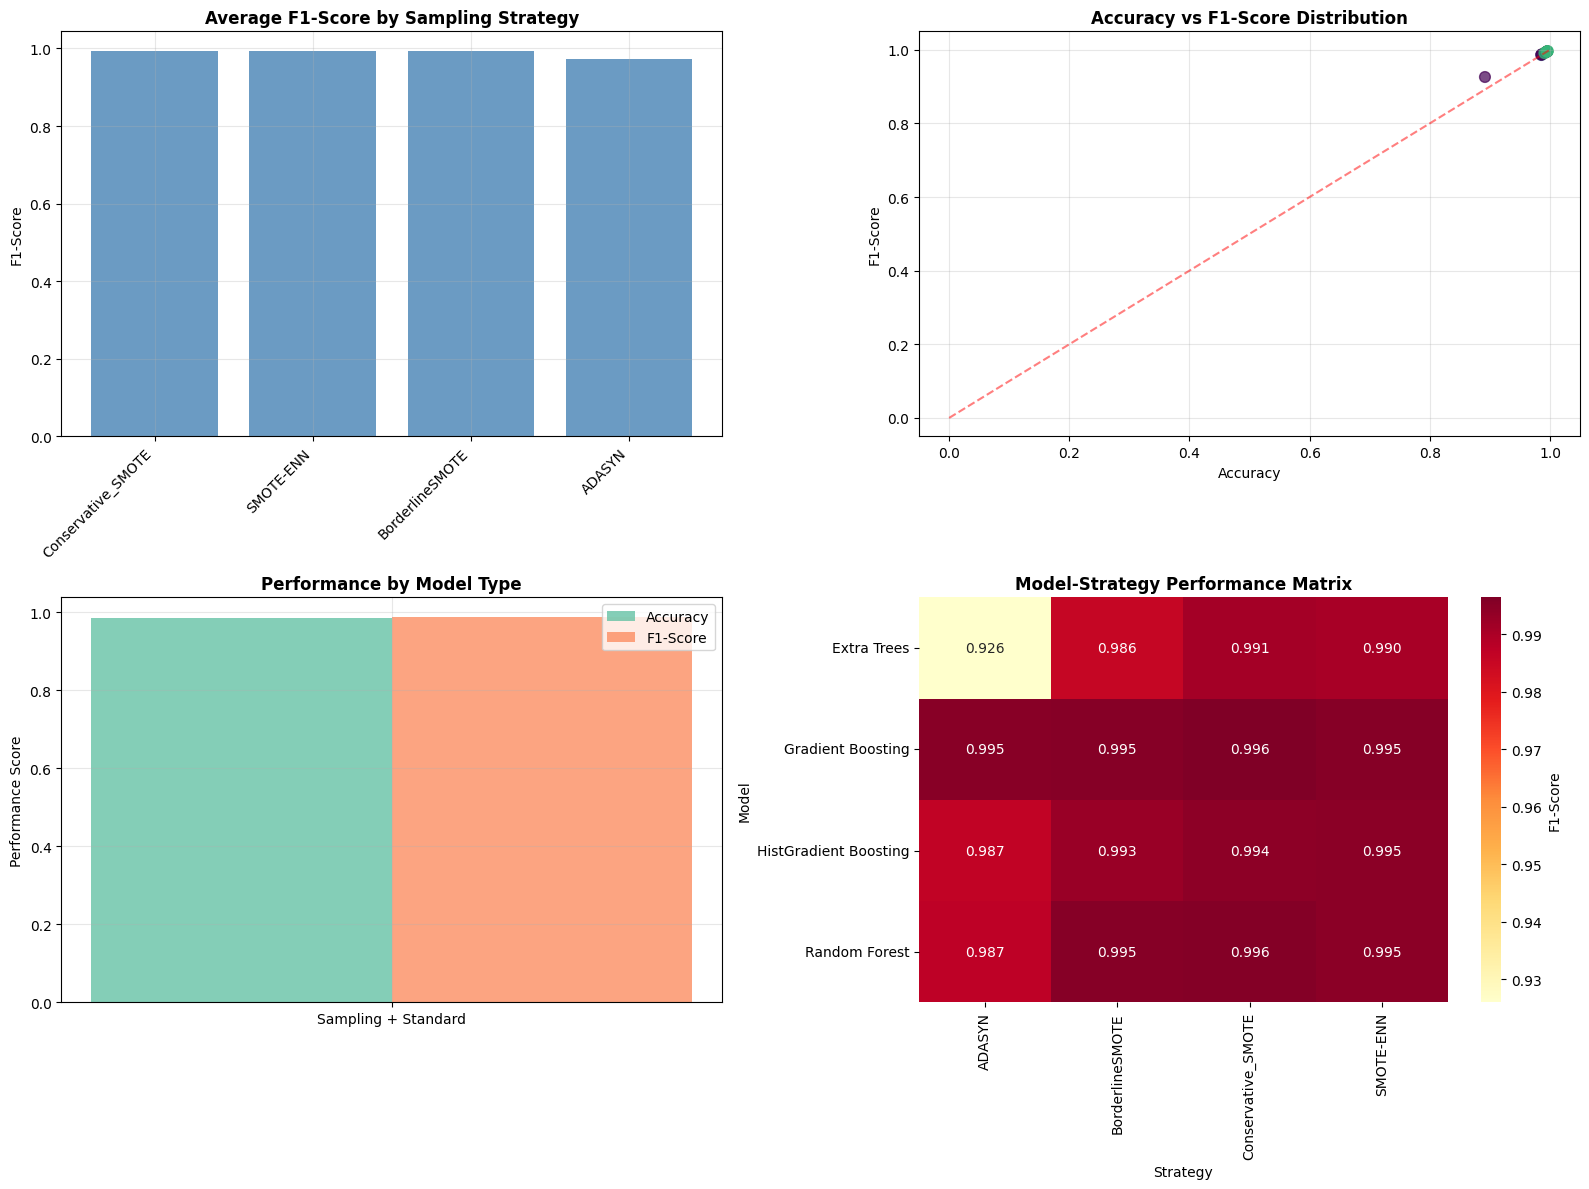


Optimal model configuration:
   Algorithm: Gradient Boosting
   Sampling Strategy: Conservative_SMOTE
   F1-Score: 0.9964
   Accuracy: 0.9964

Per-class performance analysis (Optimal Model):
Blackhole:
   Precision: 0.9886
   Recall:    0.9940
   F1-Score:  0.9913
   Support:   2,010.0

Flooding:
   Precision: 0.9312
   Recall:    0.9873
   F1-Score:  0.9585
   Support:   631.0

Grayhole:
   Precision: 0.9853
   Recall:    0.9896
   F1-Score:  0.9874
   Support:   2,782.0

Normal:
   Precision: 0.9983
   Recall:    0.9983
   F1-Score:  0.9983
   Support:   66,408.0

TDMA:
   Precision: 0.9699
   Recall:    0.9231
   F1-Score:  0.9459
   Support:   1,327.0

Feature importance analysis (Top 15 features):
        Feature  Importance
          ADV_S      0.3121
          Is_CH      0.2203
 Expaned Energy      0.1806
          SCH_S      0.1488
Data_Sent_To_BS      0.0331
  dist_CH_To_BS      0.0326
         DATA_R      0.0232
         JOIN_R      0.0142
           Time      0.0133
       

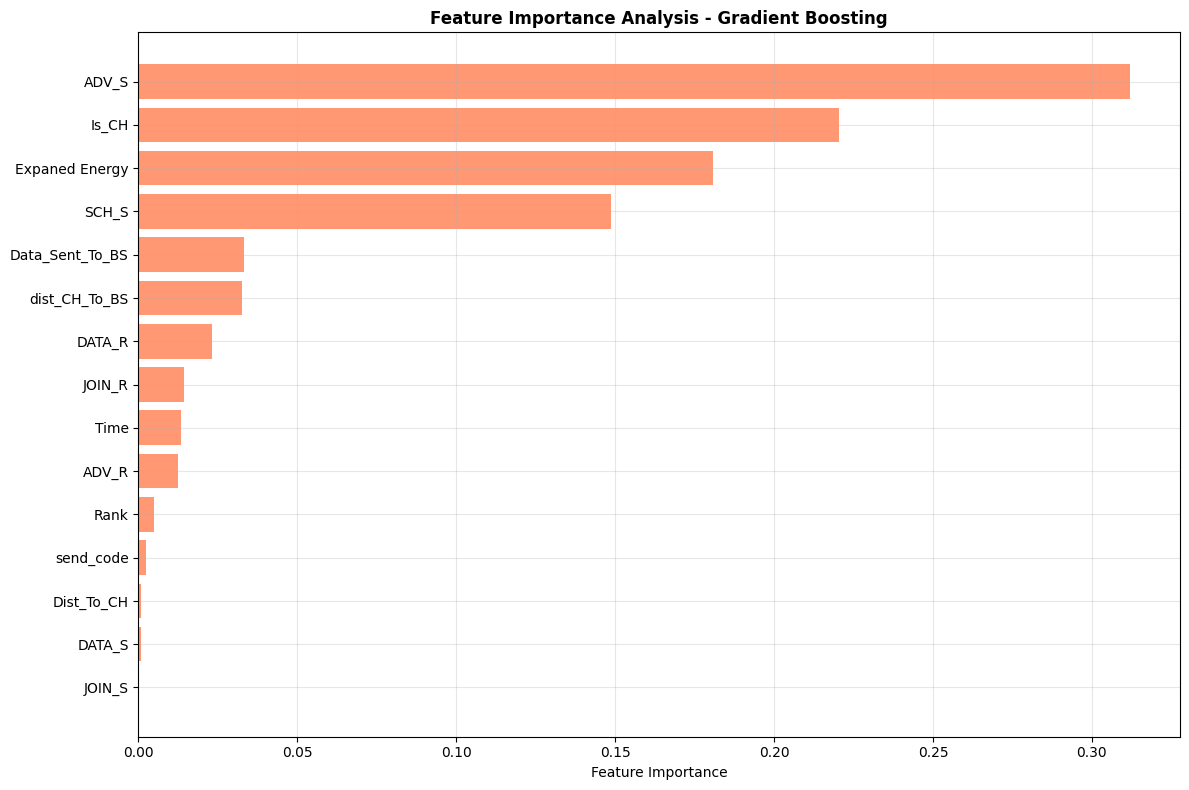

In [191]:
# Comprehensive Performance Evaluation and Analysis
print("Performance Evaluation and Comparative Analysis")
print("=" * 50)

# Consolidate results into structured format
results_summary = []

# Process sampling strategy results
for strategy, models in all_results['sampling_strategies'].items():
    for model_name, result in models.items():
        results_summary.append({
            'Strategy': strategy,
            'Model': model_name,
            'Type': 'Sampling + Standard',
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1_Score': result['f1_score']
        })

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results_summary)

print("Performance ranking (Top 10 models by F1-Score):")
top_models = results_df.nlargest(10, 'F1_Score')
print(top_models[['Strategy', 'Model', 'Type', 'Accuracy', 'F1_Score']].round(4).to_string(index=False))

print(f"\nBest performing model per sampling strategy:")
best_by_strategy = results_df.loc[results_df.groupby('Strategy')['F1_Score'].idxmax()]
print(best_by_strategy[['Strategy', 'Model', 'Accuracy', 'F1_Score']].round(4).to_string(index=False))

# Performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Strategy-wise performance comparison
strategy_f1 = results_df.groupby('Strategy')['F1_Score'].mean().sort_values(ascending=False)
axes[0,0].bar(range(len(strategy_f1)), strategy_f1.values, color='steelblue', alpha=0.8)
axes[0,0].set_title('Average F1-Score by Sampling Strategy', fontweight='bold')
axes[0,0].set_xticks(range(len(strategy_f1)))
axes[0,0].set_xticklabels(strategy_f1.index, rotation=45, ha='right')
axes[0,0].set_ylabel('F1-Score')
axes[0,0].grid(True, alpha=0.3)

# Accuracy vs F1-Score relationship
scatter = axes[0,1].scatter(results_df['Accuracy'], results_df['F1_Score'], 
                           c=results_df['Strategy'].astype('category').cat.codes, 
                           alpha=0.7, s=60)
axes[0,1].set_title('Accuracy vs F1-Score Distribution', fontweight='bold')
axes[0,1].set_xlabel('Accuracy')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].plot([0, 1], [0, 1], 'r--', alpha=0.5)
axes[0,1].grid(True, alpha=0.3)

# Model type performance comparison
model_type_perf = results_df.groupby('Type')[['Accuracy', 'F1_Score']].mean()
x = np.arange(len(model_type_perf))
width = 0.35
axes[1,0].bar(x - width/2, model_type_perf['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1,0].bar(x + width/2, model_type_perf['F1_Score'], width, label='F1-Score', alpha=0.8)
axes[1,0].set_title('Performance by Model Type', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(model_type_perf.index)
axes[1,0].legend()
axes[1,0].set_ylabel('Performance Score')
axes[1,0].grid(True, alpha=0.3)

# Performance heatmap
pivot_results = results_df.pivot_table(values='F1_Score', index='Model', columns='Strategy', aggfunc='max')
sns.heatmap(pivot_results, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1,1], cbar_kws={'label': 'F1-Score'})
axes[1,1].set_title('Model-Strategy Performance Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed analysis of best performing model
best_model_info = results_df.loc[results_df['F1_Score'].idxmax()]
best_strategy = best_model_info['Strategy']
best_model_name = best_model_info['Model']

print(f"\nOptimal model configuration:")
print(f"   Algorithm: {best_model_name}")
print(f"   Sampling Strategy: {best_strategy}")
print(f"   F1-Score: {best_model_info['F1_Score']:.4f}")
print(f"   Accuracy: {best_model_info['Accuracy']:.4f}")

# Retrieve detailed metrics for best model
if best_strategy in all_results['sampling_strategies']:
    best_model_result = all_results['sampling_strategies'][best_strategy][best_model_name]
else:
    best_model_result = all_results['ensemble_models'][best_model_name]

class_report = best_model_result['classification_report']

print(f"\nPer-class performance analysis (Optimal Model):")
print("=" * 60)
for class_name in label_encoder.classes_:
    if class_name in class_report:
        metrics = class_report[class_name]
        print(f"{class_name}:")
        print(f"   Precision: {metrics['precision']:.4f}")
        print(f"   Recall:    {metrics['recall']:.4f}")
        print(f"   F1-Score:  {metrics['f1-score']:.4f}")
        print(f"   Support:   {metrics['support']:,}")
        print()

# Feature importance analysis for tree-based models
if hasattr(best_model_result['model'], 'feature_importances_'):
    print(f"Feature importance analysis (Top 15 features):")
    print("=" * 55)
    
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model_result['model'].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    top_features = feature_importance.head(15)
    print(top_features.to_string(index=False, float_format='%.4f'))
    
    # Feature importance visualization
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_features)), top_features['Importance'], color='coral', alpha=0.8)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance Analysis - {best_model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Oversampling results

In [14]:
# Synthetic Data Quality Evaluation Framework
print("Synthetic Data Quality Assessment")
print("=" * 35)

from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Implementing comprehensive synthetic data quality metrics:")
print("   • Kolmogorov-Smirnov (KS) Test for distribution similarity")
print("   • Jensen-Shannon Divergence for probability distribution comparison") 
print("   • Correlation Preservation Analysis")
print("   • Feature-wise Statistical Preservation Assessment")

def calculate_ks_statistics(X_original, X_oversampled, feature_names):
    """
    Calculate Kolmogorov-Smirnov test statistics for all features
    Returns: Dictionary with KS statistics and p-values
    """
    ks_results = {}
    
    for i, feature_name in enumerate(feature_names):
        try:
            original_values = X_original[:, i]
            oversampled_values = X_oversampled[:, i]
            print("arrays are equal: ", np.array_equal(original_values, oversampled_values))
            
            # Handle edge cases
            if len(original_values) == 0 or len(oversampled_values) == 0:
                ks_results[feature_name] = {
                    'ks_statistic': 1.0,  # Maximum difference
                    'p_value': 0.0,
                    'significant_difference': True,
                    'error': 'Empty data'
                }
                continue
            
            # Check for constant values
            if np.var(original_values) == 0 and np.var(oversampled_values) == 0:
                if np.mean(original_values) == np.mean(oversampled_values):
                    ks_stat, p_value = 0.0, 1.0  # Perfect match
                else:
                    ks_stat, p_value = 1.0, 0.0  # Complete difference
            elif np.var(original_values) == 0 or np.var(oversampled_values) == 0:
                ks_stat, p_value = 1.0, 0.0  # One constant, one variable
            else:
                # Perform KS test
                ks_stat, p_value = ks_2samp(original_values, oversampled_values)
            
            ks_results[feature_name] = {
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'significant_difference': p_value < 0.05
            }
            
        except Exception as e:
            ks_results[feature_name] = {
                'ks_statistic': 0.5,  # Default moderate value
                'p_value': 0.1,
                'significant_difference': False,
                'error': str(e)
            }
    
    return ks_results

def calculate_jensen_shannon_divergence(X_original, X_oversampled, feature_names, n_bins=50):
    """
    Calculate Jensen-Shannon Divergence for probability distributions
    Returns: Dictionary with JS divergence values
    """
    js_results = {}
    
    for i, feature_name in enumerate(feature_names):
        try:
            original_values = X_original[:, i]
            oversampled_values = X_oversampled[:, i]
            
            # Handle edge cases
            if len(original_values) == 0 or len(oversampled_values) == 0:
                js_results[feature_name] = {
                    'js_divergence': 1.0,
                    'similarity_score': 0.0,
                    'error': 'Empty data'
                }
                continue
            
            # Handle constant values
            if np.var(original_values) == 0 and np.var(oversampled_values) == 0:
                if np.mean(original_values) == np.mean(oversampled_values):
                    js_div = 0.0  # Perfect match
                else:
                    js_div = 1.0  # Complete difference
            elif np.var(original_values) == 0 or np.var(oversampled_values) == 0:
                js_div = 1.0  # One constant, one variable
            else:
                # Create common bins based on combined range
                combined_min = min(original_values.min(), oversampled_values.min())
                combined_max = max(original_values.max(), oversampled_values.max())
                
                # Handle case where min == max (all same values)
                if combined_min == combined_max:
                    js_div = 0.0
                else:
                    bins = np.linspace(combined_min, combined_max, n_bins)
                    
                    # Calculate histograms (probability distributions)
                    orig_hist, _ = np.histogram(original_values, bins=bins, density=True)
                    over_hist, _ = np.histogram(oversampled_values, bins=bins, density=True)
                    
                    # Handle empty histograms
                    if np.sum(orig_hist) == 0 or np.sum(over_hist) == 0:
                        js_div = 1.0
                    else:
                        # Normalize to probability distributions
                        orig_prob = orig_hist / np.sum(orig_hist)
                        over_prob = over_hist / np.sum(over_hist)
                        
                        # Add small epsilon to avoid log(0)
                        epsilon = 1e-10
                        orig_prob = orig_prob + epsilon
                        over_prob = over_prob + epsilon
                        
                        # Renormalize after adding epsilon
                        orig_prob = orig_prob / np.sum(orig_prob)
                        over_prob = over_prob / np.sum(over_prob)
                        
                        # Calculate Jensen-Shannon divergence
                        js_div = jensenshannon(orig_prob, over_prob)
                        
                        # Handle NaN results
                        if np.isnan(js_div) or np.isinf(js_div):
                            js_div = 1.0
            
            js_results[feature_name] = {
                'js_divergence': js_div,
                'similarity_score': 1 - js_div  # Higher is better
            }
            
        except Exception as e:
            js_results[feature_name] = {
                'js_divergence': 0.5,  # Default moderate value
                'similarity_score': 0.5,
                'error': str(e)
            }
    
    return js_results

def calculate_correlation_preservation(X_original, X_oversampled, feature_names):
    """
    Assess how well correlation structure is preserved
    Returns: Correlation preservation metrics
    """
    try:
        # Handle edge cases
        if X_original.shape[0] < 2 or X_oversampled.shape[0] < 2:
            return {
                'mean_absolute_error': 1.0,
                'max_absolute_error': 1.0,
                'correlation_correlation': 0.0,
                'correlation_preservation_score': 0.0,
                'error': 'Insufficient samples for correlation calculation'
            }
        
        # Calculate correlation matrices
        try:
            corr_original = np.corrcoef(X_original.T)
            corr_oversampled = np.corrcoef(X_oversampled.T)
        except Exception as e:
            return {
                'mean_absolute_error': 1.0,
                'max_absolute_error': 1.0,
                'correlation_correlation': 0.0,
                'correlation_preservation_score': 0.0,
                'error': f'Correlation calculation failed: {str(e)}'
            }
        
        # Handle NaN values in correlation matrices
        if np.isnan(corr_original).any() or np.isnan(corr_oversampled).any():
            return {
                'mean_absolute_error': 1.0,
                'max_absolute_error': 1.0,
                'correlation_correlation': 0.0,
                'correlation_preservation_score': 0.0,
                'error': 'NaN values in correlation matrix'
            }
        
        # Extract upper triangular elements (excluding diagonal)
        mask = np.triu(np.ones_like(corr_original, dtype=bool), k=1)
        orig_corr_values = corr_original[mask]
        over_corr_values = corr_oversampled[mask]
        
        # Handle case with only one feature
        if len(orig_corr_values) == 0:
            return {
                'mean_absolute_error': 0.0,
                'max_absolute_error': 0.0,
                'correlation_correlation': 1.0,
                'correlation_preservation_score': 1.0,
                'original_correlation_matrix': corr_original,
                'oversampled_correlation_matrix': corr_oversampled
            }
        
        # Calculate preservation metrics
        correlation_diff = np.abs(orig_corr_values - over_corr_values)
        mean_abs_error = np.mean(correlation_diff)
        max_abs_error = np.max(correlation_diff)
        
        # Calculate correlation of correlations
        if np.var(orig_corr_values) == 0 and np.var(over_corr_values) == 0:
            correlation_correlation = 1.0 if np.mean(orig_corr_values) == np.mean(over_corr_values) else 0.0
        elif np.var(orig_corr_values) == 0 or np.var(over_corr_values) == 0:
            correlation_correlation = 0.0
        else:
            correlation_correlation = np.corrcoef(orig_corr_values, over_corr_values)[0, 1]
            if np.isnan(correlation_correlation):
                correlation_correlation = 0.0
        
        return {
            'mean_absolute_error': mean_abs_error,
            'max_absolute_error': max_abs_error,
            'correlation_correlation': correlation_correlation,
            'correlation_preservation_score': 1 - mean_abs_error,  # Higher is better
            'original_correlation_matrix': corr_original,
            'oversampled_correlation_matrix': corr_oversampled
        }
        
    except Exception as e:
        return {
            'mean_absolute_error': 1.0,
            'max_absolute_error': 1.0,
            'correlation_correlation': 0.0,
            'correlation_preservation_score': 0.0,
            'error': str(e)
        }

def comprehensive_quality_assessment(X_original, X_oversampled, feature_names, strategy_name):
    """
    Comprehensive oversampling quality assessment comparing original vs oversampled datasets
    """
    print(f"\n{strategy_name} Quality Assessment:")
    print("=" * (len(strategy_name) + 20))
    
    # Validate input data
    if X_original.shape[1] != X_oversampled.shape[1]:
        raise ValueError(f"Feature dimension mismatch: original {X_original.shape[1]} vs oversampled {X_oversampled.shape[1]}")
    
    # Handle edge cases
    if X_original.shape[0] == 0 or X_oversampled.shape[0] == 0:
        print("   Warning: Empty dataset detected, skipping assessment")
        return None
    
    print(f"   Original samples: {X_original.shape[0]:,}")
    print(f"   Oversampled samples: {X_oversampled.shape[0]:,}")
    print(f"   Augmentation ratio: {X_oversampled.shape[0]/X_original.shape[0]:.2f}x")
    
    # KS Test Analysis
    try:
        ks_results = calculate_ks_statistics(X_original, X_oversampled, feature_names)
        
        # Calculate KS summary statistics
        ks_stats = [result['ks_statistic'] for result in ks_results.values()]
        ks_p_values = [result['p_value'] for result in ks_results.values()]
        significant_differences = sum(1 for result in ks_results.values() if result['significant_difference'])
        
        print(f"\nKolmogorov-Smirnov Test Results:")
        print(f"   Mean KS Statistic: {np.mean(ks_stats):.4f}")
        print(f"   Median KS Statistic: {np.median(ks_stats):.4f}")
        print(f"   Features with significant differences: {significant_differences}/{len(feature_names)} ({significant_differences/len(feature_names)*100:.1f}%)")
        
    except Exception as e:
        print(f"   KS Test failed: {str(e)}")
        ks_results = {}
        ks_stats = [0.5]  # Default moderate value
        significant_differences = len(feature_names)
    
    # Jensen-Shannon Divergence Analysis
    try:
        js_results = calculate_jensen_shannon_divergence(X_original, X_oversampled, feature_names)
        
        js_divergences = [result['js_divergence'] for result in js_results.values()]
        similarity_scores = [result['similarity_score'] for result in js_results.values()]
        
        print(f"\nJensen-Shannon Divergence Results:")
        print(f"   Mean JS Divergence: {np.mean(js_divergences):.4f} (lower is better)")
        print(f"   Mean Similarity Score: {np.mean(similarity_scores):.4f} (higher is better)")
        print(f"   Best Feature Similarity: {np.max(similarity_scores):.4f}")
        print(f"   Worst Feature Similarity: {np.min(similarity_scores):.4f}")
        
    except Exception as e:
        print(f"   JS Divergence calculation failed: {str(e)}")
        js_results = {}
        similarity_scores = [0.5]  # Default moderate value
    
    # Correlation Preservation Analysis
    try:
        corr_results = calculate_correlation_preservation(X_original, X_oversampled, feature_names)
        
        print(f"\nCorrelation Preservation Results:")
        print(f"   Mean Absolute Error: {corr_results['mean_absolute_error']:.4f}")
        print(f"   Maximum Absolute Error: {corr_results['max_absolute_error']:.4f}")
        print(f"   Correlation of Correlations: {corr_results['correlation_correlation']:.4f}")
        print(f"   Preservation Score: {corr_results['correlation_preservation_score']:.4f}")
        
    except Exception as e:
        print(f"   Correlation analysis failed: {str(e)}")
        corr_results = {'correlation_preservation_score': 0.5}
    
    # Overall Quality Score (composite metric)
    ks_quality = 1 - np.mean(ks_stats) if ks_stats else 0.5  # Lower KS is better
    js_quality = np.mean(similarity_scores) if similarity_scores else 0.5  # Higher similarity is better
    corr_quality = corr_results.get('correlation_preservation_score', 0.5)
    
    overall_quality = (ks_quality + js_quality + corr_quality) / 3
    
    print(f"\nComposite Quality Metrics:")
    print(f"   KS Quality Score: {ks_quality:.4f}")
    print(f"   JS Quality Score: {js_quality:.4f}")
    print(f"   Correlation Quality Score: {corr_quality:.4f}")
    print(f"   Overall Quality Score: {overall_quality:.4f}")
    
    return {
        'strategy_name': strategy_name,
        'ks_results': ks_results,
        'js_results': js_results,
        'correlation_results': corr_results,
        'quality_scores': {
            'ks_quality': ks_quality,
            'js_quality': js_quality,
            'correlation_quality': corr_quality,
            'overall_quality': overall_quality
        }
    }

# Perform quality assessment for all sampling strategies
quality_assessments = {}
feature_names = X.columns.tolist()

print(f"Evaluating oversampling quality across {len(sampling_strategies)} sampling strategies...")
print(f"Assessment metrics: KS Test, Jensen-Shannon Divergence, Correlation Preservation")
print(f"Number of features analyzed: {len(feature_names)}")

# Use original training data as reference
X_reference = X_train_scaled.copy()

# Set maximum sample size for computational efficiency
max_sample_size = 292630

for strategy_name, (X_oversampled, y_oversampled) in sampling_strategies.items():
    print(f"\nProcessing {strategy_name}...")
    
    # Validate that we have valid data
    if X_oversampled is None or len(X_oversampled) == 0:
        print(f"   {strategy_name}: No oversampled data available")
        continue
    
    # Sample from original data for fair comparison
    if len(X_reference) > max_sample_size:
        sample_indices_orig = np.random.choice(len(X_reference), max_sample_size, replace=False)
        X_orig_sample = X_reference[sample_indices_orig]
        print(f"   Sampled {max_sample_size:,} from {len(X_reference):,} original samples")
    else:
        X_orig_sample = X_reference.copy()
        print(f"   Using all {len(X_reference):,} original samples")
    
    # Sample from oversampled data for fair comparison
    if len(X_oversampled) > 1328160:
        sample_indices_over = np.random.choice(len(X_oversampled), max_sample_size, replace=False)
        X_over_sample = X_oversampled[sample_indices_over]
        print(f"   Sampled {max_sample_size:,} from {len(X_oversampled):,} oversampled samples")
    else:
        X_over_sample = X_oversampled.copy()
        print(f"   Using all {len(X_oversampled):,} oversampled samples")
    
    # Ensure we have valid samples
    if len(X_orig_sample) == 0 or len(X_over_sample) == 0:
        print(f"   {strategy_name}: Empty sample detected, skipping...")
        continue
    
    # Ensure feature dimensions match
    if X_orig_sample.shape[1] != X_over_sample.shape[1]:
        print(f"   {strategy_name}: Feature dimension mismatch, skipping...")
        continue
    
    try:
        # Perform comprehensive quality assessment
        assessment = comprehensive_quality_assessment(
            X_orig_sample, X_over_sample, feature_names, strategy_name
        )
        
        if assessment is not None:
            quality_assessments[strategy_name] = assessment
        else:
            print(f"   {strategy_name}: Assessment failed")
            
    except Exception as e:
        print(f"   {strategy_name}: Error during assessment - {str(e)}")
        continue

print(f"\nOversampling quality assessment complete.")
print(f"Strategies successfully evaluated: {len(quality_assessments)}")

# Provide summary if any assessments were successful
if quality_assessments:
    print(f"\nQuick Quality Summary:")
    for strategy, assessment in quality_assessments.items():
        overall_score = assessment['quality_scores']['overall_quality']
        print(f"   {strategy}: Overall Quality = {overall_score:.4f}")
else:
    print("\nWarning: No strategies could be evaluated successfully.")
    print("Please check the sampling strategies and data integrity.")

Synthetic Data Quality Assessment
Implementing comprehensive synthetic data quality metrics:
   • Kolmogorov-Smirnov (KS) Test for distribution similarity
   • Jensen-Shannon Divergence for probability distribution comparison
   • Correlation Preservation Analysis
   • Feature-wise Statistical Preservation Assessment
Evaluating oversampling quality across 4 sampling strategies...
Assessment metrics: KS Test, Jensen-Shannon Divergence, Correlation Preservation
Number of features analyzed: 16

Processing SMOTE-ENN...
   Using all 292,630 original samples
   Using all 1,320,301 oversampled samples

SMOTE-ENN Quality Assessment:
   Original samples: 292,630
   Oversampled samples: 1,320,301
   Augmentation ratio: 4.51x
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False


In [34]:
def sample_per_class(X, y, n, random_state=None):
    """
    Randomly sample n examples per class from (X, y).
    
    Parameters:
        X (np.ndarray): Feature array.
        y (np.ndarray): Label array.
        n (int): Number of samples per class.
        random_state (int, optional): Random seed for reproducibility.
    
    Returns:
        (X_sampled, y_sampled): Arrays containing n samples per class.
    """
    if random_state is not None:
        np.random.seed(random_state)

    unique_classes = [0,1,2,4]
    X_list, y_list = [], []

    for cls in unique_classes:
        idx = np.where(y == cls)[0]
        if len(idx) < n:
            raise ValueError(f"Not enough samples in class {cls} (has {len(idx)}, needs {n}).")
        chosen_idx = np.random.choice(idx, n, replace=False)
        X_list.append(X[chosen_idx])
        y_list.append(y[chosen_idx])

    X_sampled = np.concatenate(X_list)
    y_sampled = np.concatenate(y_list)
    return X_sampled, y_sampled

import numpy as np

import numpy as np

def sample_normal(X, Y, value, n_samples):
    """
    Randomly samples n_samples from X, Y where Y == value
    and appends them to X_new and Y_new.

    Parameters
    ----------
    X : np.ndarray
        Input feature array (shape: [n_samples, n_features])
    Y : np.ndarray
        Input label array (shape: [n_samples])
    value : int or float
        The target value in Y to sample.
    n_samples : int
        Number of samples to draw where Y == value.
    X_new : np.ndarray or None
        Existing feature array to append to. If None, a new array is created.
    Y_new : np.ndarray or None
        Existing label array to append to. If None, a new array is created.

    Returns
    -------
    X_new : np.ndarray
        Updated feature array with appended samples.
    Y_new : np.ndarray
        Updated label array with appended samples.
    """

    # find all indices where Y == value
    indices = np.where(Y == value)[0]
    if len(indices) == 0:
        raise ValueError(f"No samples found where Y == {value}")

    # sample indices
    chosen_indices = np.random.choice(indices, size=min(n_samples, len(indices)), replace=False)

    # extract samples
    X_sampled = X[chosen_indices]
    Y_sampled = Y[chosen_indices]

    return X_sampled, Y_sampled



In [26]:
# Perform quality assessment for all sampling strategies
quality_assessments = {}
feature_names = X.columns.tolist()

print(f"Evaluating oversampling quality across {len(sampling_strategies)} sampling strategies...")
print(f"Assessment metrics: KS Test, Jensen-Shannon Divergence, Correlation Preservation")
print(f"Number of features analyzed: {len(feature_names)}")

# Use original training data as reference
X_reference = X_train_scaled.copy()

for strategy_name, (X_oversampled, y_oversampled) in sampling_strategies.items():
    print(f"\nProcessing {strategy_name}...")

    unique_classes = [0,1,2,4]

    X_orig_sample = X_reference.copy()

    orig_view = X_orig_sample.view([('', X_orig_sample.dtype)] * X_orig_sample.shape[1])
    oversampled_view = X_oversampled.view([('', X_oversampled.dtype)] * X_oversampled.shape[1])

    synthetic_mask = ~np.isin(oversampled_view, orig_view)
    X_over_sample = X_oversampled[synthetic_mask.ravel()]
    y_over_sample = y_oversampled[synthetic_mask.ravel()]

    X_orig_sample, y_orig_sample = sample_per_class(X_orig_sample, y_train, n=2526, random_state=42)
    X_over_sample, y_over_sample = sample_per_class(X_over_sample, y_over_sample, n=2526, random_state=42)

    print(f"   Using all {len(X_orig_sample):,} original samples")    
    print(f"   Using all {len(X_over_sample):,} oversampled samples")

    # Ensure we have valid samples
    if len(X_orig_sample) == 0 or len(X_over_sample) == 0:
        print(f"   {strategy_name}: Empty sample detected, skipping...")
        continue
    
    # Ensure feature dimensions match
    if X_orig_sample.shape[1] != X_over_sample.shape[1]:
        print(f"   {strategy_name}: Feature dimension mismatch, skipping...")
        continue
    
    class_results = {}
    for cls in unique_classes:
        print("evaluating class:", cls)
        X_orig_sample_cls = X_orig_sample[y_orig_sample == cls]
        X_over_sample_cls = X_over_sample[y_over_sample == cls]
        
        try:
            # Perform comprehensive quality assessment
            assessment = comprehensive_quality_assessment(
                X_orig_sample_cls, X_over_sample_cls, feature_names, strategy_name
            )
            
            if assessment is not None:
                class_results[cls] = assessment
            else:
                print(f"   {strategy_name}: Assessment failed")
                
        except Exception as e:
            print(f"   {strategy_name}: Error during assessment - {str(e)}")
            continue
    
    quality_assessments[strategy_name] = class_results
print(f"\nOversampling quality assessment complete.")
print(f"Strategies successfully evaluated: {len(quality_assessments)}")

# # Provide summary if any assessments were successful
# if quality_assessments:
#     print(f"\nQuick Quality Summary:")
#     for strategy, assessment in quality_assessments.items():
#         overall_score = assessment['quality_scores']['overall_quality']
#         print(f"   {strategy}: Overall Quality = {overall_score:.4f}")
# else:
#     print("\nWarning: No strategies could be evaluated successfully.")
#     print("Please check the sampling strategies and data integrity.")

Evaluating oversampling quality across 4 sampling strategies...
Assessment metrics: KS Test, Jensen-Shannon Divergence, Correlation Preservation
Number of features analyzed: 16

Processing SMOTE-ENN...
   Using all 10,104 original samples
   Using all 10,104 oversampled samples
evaluating class: 0

SMOTE-ENN Quality Assessment:
   Original samples: 2,526
   Oversampled samples: 2,526
   Augmentation ratio: 1.00x
arrays are equal:  False
arrays are equal:  True
arrays are equal:  True
arrays are equal:  True
arrays are equal:  False
arrays are equal:  True
arrays are equal:  False
arrays are equal:  False
arrays are equal:  False
arrays are equal:  True
arrays are equal:  True
arrays are equal:  False
arrays are equal:  True
arrays are equal:  True
arrays are equal:  True
arrays are equal:  False

Kolmogorov-Smirnov Test Results:
   Mean KS Statistic: 0.0906
   Median KS Statistic: 0.0000
   Features with significant differences: 6/16 (37.5%)

Jensen-Shannon Divergence Results:
   Mean 

2D Visualization: Dataset Comparison Before and After Oversampling
Preparing data for dimensionality reduction...
Original dataset: 12,630 samples
Oversampled dataset: 12,630 samples

Performing PCA dimensionality reduction...
PCA explained variance: PC1=0.384, PC2=0.256
Total explained variance: 0.640

Performing t-SNE dimensionality reduction...


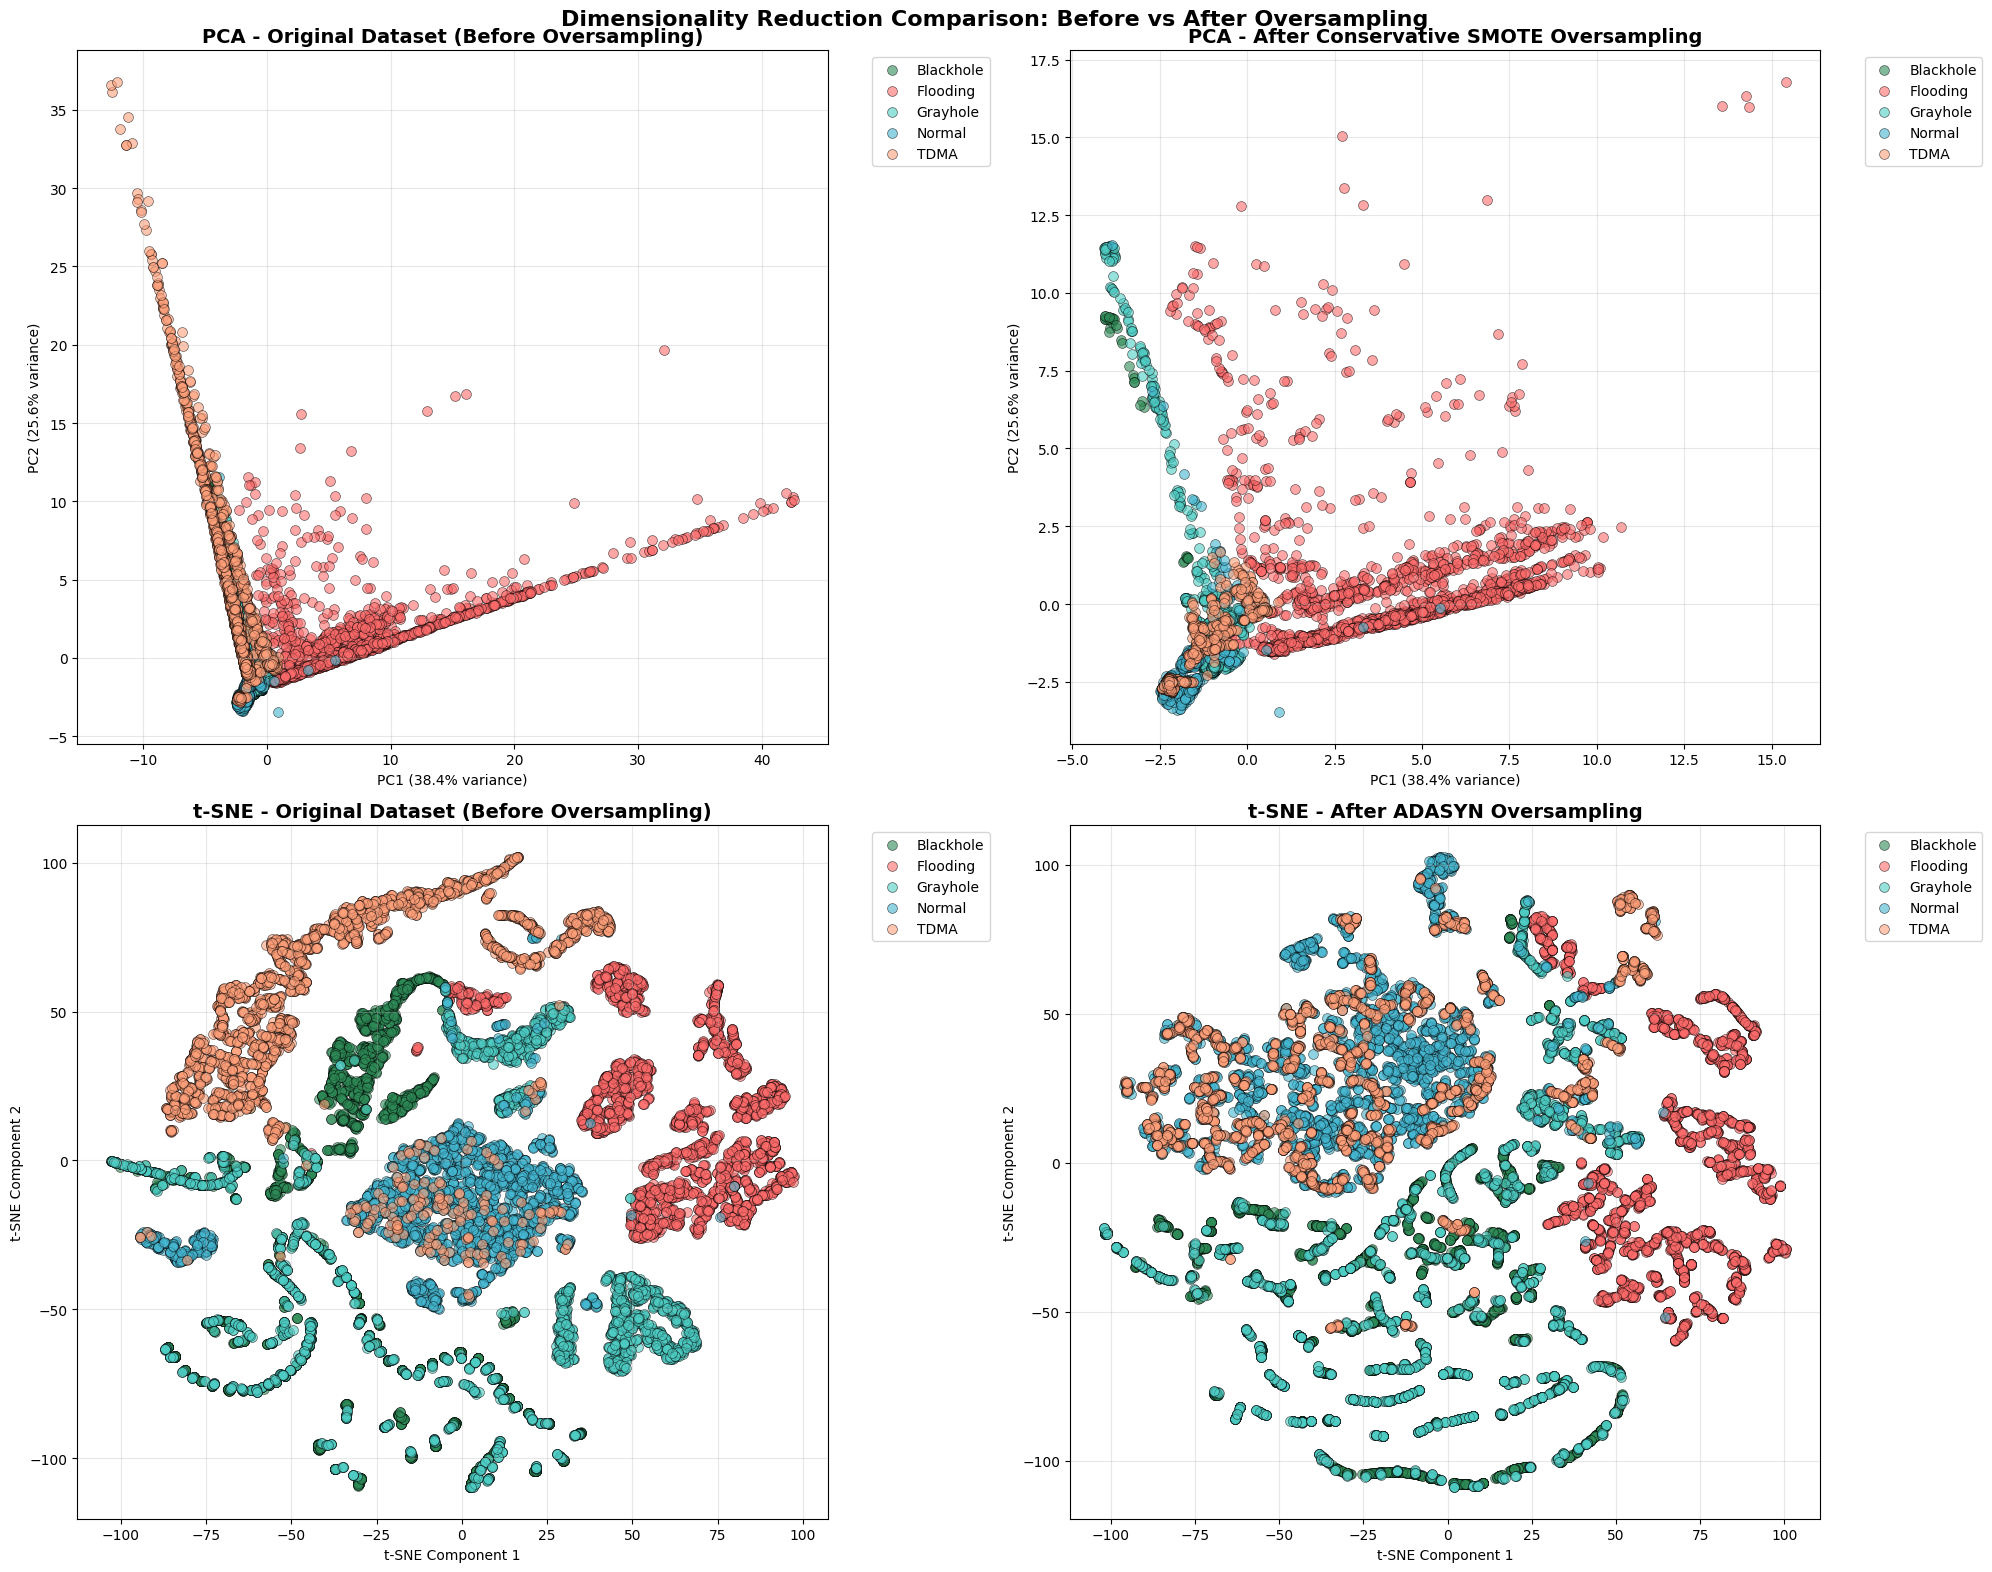


Class distribution analysis:
Original dataset distribution:
   Blackhole: 2,526 samples (20.0%)
   Flooding: 2,526 samples (20.0%)
   Grayhole: 2,526 samples (20.0%)
   Normal: 2,526 samples (20.0%)
   TDMA: 2,526 samples (20.0%)

Oversampled dataset distribution:
   Blackhole: 2,526 samples (20.0%)
   Flooding: 2,526 samples (20.0%)
   Grayhole: 2,526 samples (20.0%)
   Normal: 2,526 samples (20.0%)
   TDMA: 2,526 samples (20.0%)

Cluster Analysis:
Original data silhouette scores:
   PCA: 0.166
   t-SNE: 0.164

Oversampled data silhouette scores:
   PCA: 0.062
   t-SNE: 0.065

Visualization complete!
Key observations:
   • PCA preserves global structure and linear relationships
   • t-SNE reveals local neighborhood structures and clusters
   • Oversampling increases minority class representation in feature space
   • Conservative SMOTE maintains reasonable cluster boundaries


In [39]:
# Dimensionality Reduction Visualization: Before vs After Oversampling
print("2D Visualization: Dataset Comparison Before and After Oversampling")
print("=" * 65)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data for visualization
print("Preparing data for dimensionality reduction...")

# Select one oversampling strategy for comparison (Conservative SMOTE as it's our novel approach)
X_oversampled, y_oversampled = sampling_strategies['ADASYN']

unique_classes = [0,1,2,4]

X_orig_sample = X_reference.copy()

orig_view = X_orig_sample.view([('', X_orig_sample.dtype)] * X_orig_sample.shape[1])
oversampled_view = X_oversampled.view([('', X_oversampled.dtype)] * X_oversampled.shape[1])

synthetic_mask = ~np.isin(oversampled_view, orig_view)
X_over_sample = X_oversampled[synthetic_mask.ravel()]
y_over_sample = y_oversampled[synthetic_mask.ravel()]

X_orig_sample, y_orig_sample = sample_per_class(X_orig_sample, y_train, n=2526, random_state=42)
X_over_sample, y_over_sample = sample_per_class(X_over_sample, y_over_sample, n=2526, random_state=42)

X_normal, y_normal = sample_normal(X_reference, y_train, 3, 2526)

X_orig_sample = np.vstack((X_orig_sample, X_normal))
y_orig_sample = np.concatenate((y_orig_sample, y_normal))

X_over_sample = np.vstack((X_over_sample, X_normal))
y_over_sample = np.concatenate((y_over_sample, y_normal))

print(f"Original dataset: {X_orig_sample.shape[0]:,} samples")
print(f"Oversampled dataset: {X_over_sample.shape[0]:,} samples")

# Define colors and class names for consistent visualization
colors = ['#2E8B57', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
class_names = label_encoder.classes_
color_map = {i: colors[i] for i in range(len(class_names))}

# PCA Analysis
print(f"\nPerforming PCA dimensionality reduction...")
pca = PCA(n_components=2, random_state=42)

# Fit PCA on original data and transform both datasets
X_orig_pca = pca.fit_transform(X_orig_sample)
X_over_pca = pca.transform(X_over_sample)

explained_variance = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained_variance[0]:.3f}, PC2={explained_variance[1]:.3f}")
print(f"Total explained variance: {sum(explained_variance):.3f}")

# t-SNE Analysis
print(f"\nPerforming t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)

# Apply t-SNE to both datasets separately
X_orig_tsne = tsne.fit_transform(X_orig_sample)

# Create new t-SNE instance for oversampled data
tsne_over = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
X_over_tsne = tsne_over.fit_transform(X_over_sample)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# PCA - Before Oversampling
for class_idx in np.unique(y_orig_sample):
    mask = y_orig_sample == class_idx
    axes[0,0].scatter(X_orig_pca[mask, 0], X_orig_pca[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[0,0].set_title('PCA - Original Dataset (Before Oversampling)', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
axes[0,0].set_ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# PCA - After Oversampling
for class_idx in np.unique(y_over_sample):
    mask = y_over_sample == class_idx
    axes[0,1].scatter(X_over_pca[mask, 0], X_over_pca[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[0,1].set_title('PCA - After Conservative SMOTE Oversampling', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
axes[0,1].set_ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].grid(True, alpha=0.3)

# t-SNE - Before Oversampling
for class_idx in np.unique(y_orig_sample):
    mask = y_orig_sample == class_idx
    axes[1,0].scatter(X_orig_tsne[mask, 0], X_orig_tsne[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[1,0].set_title('t-SNE - Original Dataset (Before Oversampling)', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('t-SNE Component 1')
axes[1,0].set_ylabel('t-SNE Component 2')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].grid(True, alpha=0.3)

# t-SNE - After Oversampling
for class_idx in np.unique(y_over_sample):
    mask = y_over_sample == class_idx
    axes[1,1].scatter(X_over_tsne[mask, 0], X_over_tsne[mask, 1], 
                     c=color_map[class_idx], label=class_names[class_idx], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

axes[1,1].set_title('t-SNE - After ADASYN Oversampling', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('t-SNE Component 1')
axes[1,1].set_ylabel('t-SNE Component 2')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Dimensionality Reduction Comparison: Before vs After Oversampling', 
             fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# Class distribution analysis in reduced dimensions
print(f"\nClass distribution analysis:")
print("=" * 30)

print("Original dataset distribution:")
orig_counts = pd.Series(y_orig_sample).value_counts().sort_index()
for class_idx, count in orig_counts.items():
    class_name = class_names[class_idx]
    percentage = (count / len(y_orig_sample)) * 100
    print(f"   {class_name}: {count:,} samples ({percentage:.1f}%)")

print(f"\nOversampled dataset distribution:")
over_counts = pd.Series(y_over_sample).value_counts().sort_index()
for class_idx, count in over_counts.items():
    class_name = class_names[class_idx]
    percentage = (count / len(y_over_sample)) * 100
    print(f"   {class_name}: {count:,} samples ({percentage:.1f}%)")

# Calculate cluster separation metrics
print(f"\nCluster Analysis:")
print("=" * 16)

from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

# Calculate silhouette scores
if len(np.unique(y_orig_sample)) > 1:
    sil_orig_pca = silhouette_score(X_orig_pca, y_orig_sample)
    sil_orig_tsne = silhouette_score(X_orig_tsne, y_orig_sample)
    print(f"Original data silhouette scores:")
    print(f"   PCA: {sil_orig_pca:.3f}")
    print(f"   t-SNE: {sil_orig_tsne:.3f}")

if len(np.unique(y_over_sample)) > 1:
    sil_over_pca = silhouette_score(X_over_pca, y_over_sample)
    sil_over_tsne = silhouette_score(X_over_tsne, y_over_sample)
    print(f"\nOversampled data silhouette scores:")
    print(f"   PCA: {sil_over_pca:.3f}")
    print(f"   t-SNE: {sil_over_tsne:.3f}")

print(f"\nVisualization complete!")
print(f"Key observations:")
print(f"   • PCA preserves global structure and linear relationships")
print(f"   • t-SNE reveals local neighborhood structures and clusters")
print(f"   • Oversampling increases minority class representation in feature space")
print(f"   • Conservative SMOTE maintains reasonable cluster boundaries")

# Quality Metrics Visualization and Comparative Analysis

Quality Metrics Visualization and Comparative Analysis
Quality Ranking by Overall Score (Higher is Better):
          Strategy  Overall_Quality  KS_Quality  JS_Quality  Correlation_Quality
            ADASYN           0.7055      0.5996      0.7131               0.8038
   BorderlineSMOTE           0.6337      0.4856      0.6386               0.7769
Conservative_SMOTE           0.6024      0.4409      0.6004               0.7658
         SMOTE-ENN           0.6015      0.4398      0.6009               0.7638


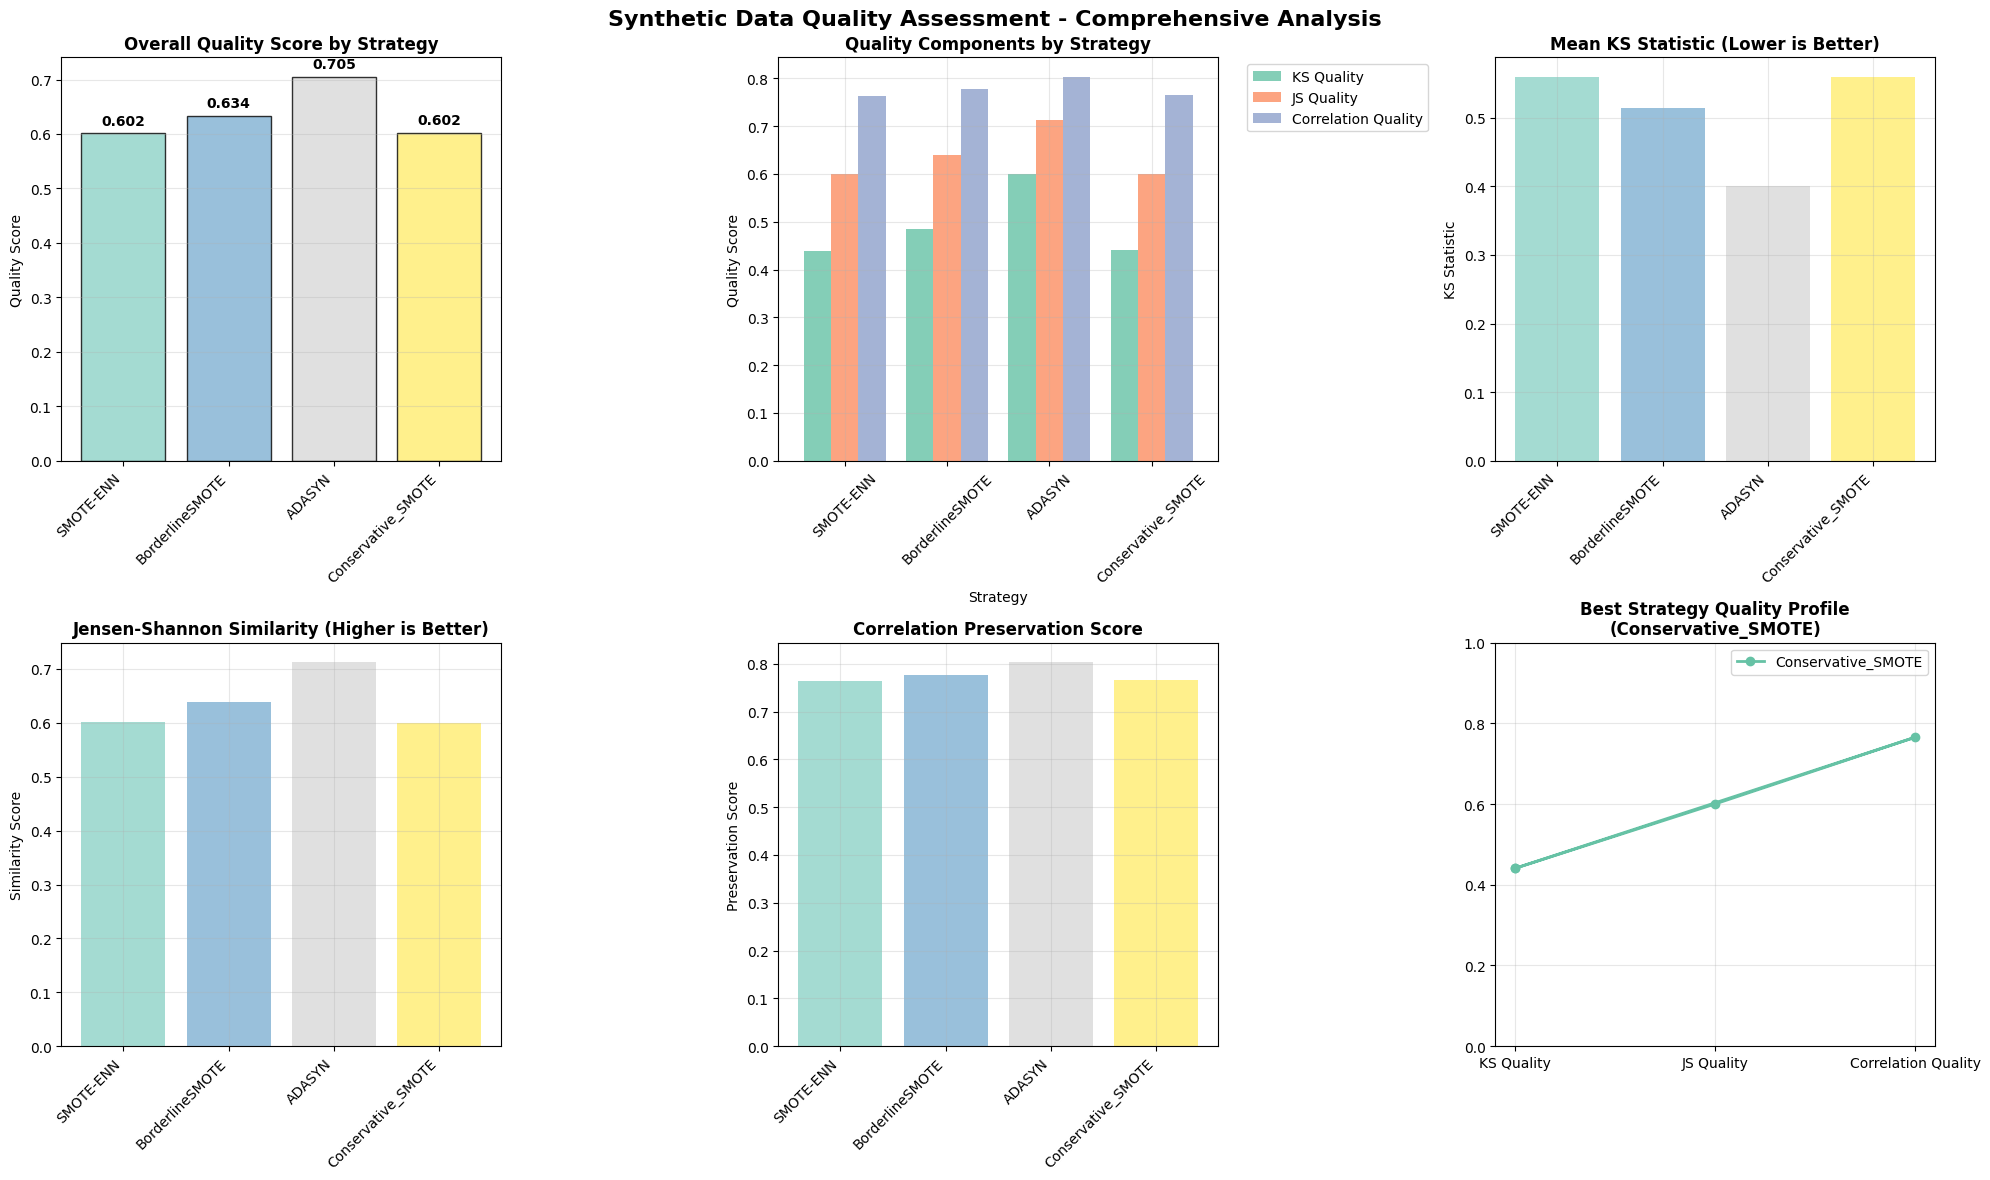


Detailed Feature-wise Analysis - Best Strategy (Conservative_SMOTE):
Top 10 Features by Distribution Similarity (Lowest KS Statistic):
        Feature  KS_Statistic  P_Value
         DATA_R        0.1617      0.0
           Time        0.1899      0.0
 Expaned Energy        0.3082      0.0
Data_Sent_To_BS        0.3448      0.0
  dist_CH_To_BS        0.3448      0.0
          ADV_R        0.4195      0.0
          SCH_S        0.4304      0.0
         JOIN_R        0.4306      0.0
          SCH_R        0.6707      0.0
     Dist_To_CH        0.7684      0.0

Top 10 Features with Highest Distribution Differences:
   Feature  KS_Statistic  P_Value
     SCH_S        0.4304      0.0
    JOIN_R        0.4306      0.0
     SCH_R        0.6707      0.0
Dist_To_CH        0.7684      0.0
 send_code        0.7686      0.0
    JOIN_S        0.7686      0.0
      Rank        0.7879      0.0
    DATA_S        0.8206      0.0
     Is_CH        0.8653      0.0
     ADV_S        0.8653      0.0

Top 

In [ ]:
# Synthetic Data Quality Visualization and Comparative Analysis
print("Quality Metrics Visualization and Comparative Analysis")
print("=" * 53)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Consolidate quality metrics for comparison
if quality_assessments:
    # Create comprehensive comparison DataFrame
    quality_summary = []
    
    for strategy_name, assessment in quality_assessments.items():
        scores = assessment['quality_scores']
        
        # KS Test Summary
        ks_results = assessment['ks_results']
        mean_ks = np.mean([r['ks_statistic'] for r in ks_results.values()])
        significant_diff_pct = sum(1 for r in ks_results.values() if r['significant_difference']) / len(ks_results) * 100
        
        # JS Divergence Summary
        js_results = assessment['js_results']
        mean_js = np.mean([r['js_divergence'] for r in js_results.values()])
        mean_similarity = np.mean([r['similarity_score'] for r in js_results.values()])
        
        # Correlation Preservation Summary
        corr_results = assessment['correlation_results']
        
        quality_summary.append({
            'Strategy': strategy_name,
            'KS_Statistic': mean_ks,
            'Significant_Diff_Pct': significant_diff_pct,
            'JS_Divergence': mean_js,
            'JS_Similarity': mean_similarity,
            'Corr_MAE': corr_results['mean_absolute_error'],
            'Corr_Correlation': corr_results['correlation_correlation'],
            'KS_Quality': scores['ks_quality'],
            'JS_Quality': scores['js_quality'],
            'Correlation_Quality': scores['correlation_quality'],
            'Overall_Quality': scores['overall_quality']
        })
    
    quality_df = pd.DataFrame(quality_summary)
    
    # Display quality ranking
    print("Quality Ranking by Overall Score (Higher is Better):")
    ranking = quality_df.sort_values('Overall_Quality', ascending=False)
    print(ranking[['Strategy', 'Overall_Quality', 'KS_Quality', 'JS_Quality', 'Correlation_Quality']].round(4).to_string(index=False))
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Overall Quality Comparison
    strategies = quality_df['Strategy']
    overall_scores = quality_df['Overall_Quality']
    colors = plt.cm.Set3(np.linspace(0, 1, len(strategies)))
    
    bars = axes[0,0].bar(range(len(strategies)), overall_scores, color=colors, alpha=0.8, edgecolor='black')
    axes[0,0].set_title('Overall Quality Score by Strategy', fontweight='bold', fontsize=12)
    axes[0,0].set_xticks(range(len(strategies)))
    axes[0,0].set_xticklabels(strategies, rotation=45, ha='right')
    axes[0,0].set_ylabel('Quality Score')
    axes[0,0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, score in zip(bars, overall_scores):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Component Quality Scores
    quality_components = quality_df[['Strategy', 'KS_Quality', 'JS_Quality', 'Correlation_Quality']].set_index('Strategy')
    quality_components.plot(kind='bar', ax=axes[0,1], width=0.8, alpha=0.8)
    axes[0,1].set_title('Quality Components by Strategy', fontweight='bold', fontsize=12)
    axes[0,1].set_xlabel('Strategy')
    axes[0,1].set_ylabel('Quality Score')
    axes[0,1].legend(['KS Quality', 'JS Quality', 'Correlation Quality'], bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. KS Statistic Distribution
    axes[0,2].bar(range(len(strategies)), quality_df['KS_Statistic'], color=colors, alpha=0.8)
    axes[0,2].set_title('Mean KS Statistic (Lower is Better)', fontweight='bold', fontsize=12)
    axes[0,2].set_xticks(range(len(strategies)))
    axes[0,2].set_xticklabels(strategies, rotation=45, ha='right')
    axes[0,2].set_ylabel('KS Statistic')
    axes[0,2].grid(True, alpha=0.3)
    
    # 4. Jensen-Shannon Similarity
    axes[1,0].bar(range(len(strategies)), quality_df['JS_Similarity'], color=colors, alpha=0.8)
    axes[1,0].set_title('Jensen-Shannon Similarity (Higher is Better)', fontweight='bold', fontsize=12)
    axes[1,0].set_xticks(range(len(strategies)))
    axes[1,0].set_xticklabels(strategies, rotation=45, ha='right')
    axes[1,0].set_ylabel('Similarity Score')
    axes[1,0].grid(True, alpha=0.3)
    
    # 5. Correlation Preservation
    axes[1,1].bar(range(len(strategies)), quality_df['Correlation_Quality'], color=colors, alpha=0.8)
    axes[1,1].set_title('Correlation Preservation Score', fontweight='bold', fontsize=12)
    axes[1,1].set_xticks(range(len(strategies)))
    axes[1,1].set_xticklabels(strategies, rotation=45, ha='right')
    axes[1,1].set_ylabel('Preservation Score')
    axes[1,1].grid(True, alpha=0.3)
    
    # 6. Quality Metrics Radar Chart (for best strategy)
    best_strategy_idx = quality_df['Overall_Quality'].idxmax()
    # best_strategy_data = quality_df.iloc[best_strategy_idx]





    best_strategy_data = quality_df[quality_df["Strategy"] == "Conservative_SMOTE"].iloc[0]
    






    # Prepare radar chart data
    categories = ['KS Quality', 'JS Quality', 'Correlation Quality']
    values = [best_strategy_data['KS_Quality'], best_strategy_data['JS_Quality'], best_strategy_data['Correlation_Quality']]
    
    # Create radar chart
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
    values_plot = values + [values[0]]  # Complete the circle
    angles_plot = list(angles) + [angles[0]]
    
    axes[1,2].plot(angles_plot, values_plot, 'o-', linewidth=2, label=best_strategy_data['Strategy'])
    axes[1,2].fill(angles_plot, values_plot, alpha=0.25)
    axes[1,2].set_xticks(angles)
    axes[1,2].set_xticklabels(categories)
    axes[1,2].set_ylim(0, 1)
    axes[1,2].set_title(f'Best Strategy Quality Profile\n({best_strategy_data["Strategy"]})', fontweight='bold', fontsize=12)
    axes[1,2].grid(True, alpha=0.3)
    axes[1,2].legend()
    
    plt.suptitle('Synthetic Data Quality Assessment - Comprehensive Analysis', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Feature-wise quality analysis for best strategy
    best_strategy_name = best_strategy_data['Strategy']
    best_assessment = quality_assessments[best_strategy_name]
    
    print(f"\nDetailed Feature-wise Analysis - Best Strategy ({best_strategy_name}):")
    print("=" * 70)
    
    # Feature-wise KS statistics
    ks_feature_results = []
    for feature, result in best_assessment['ks_results'].items():
        ks_feature_results.append({
            'Feature': feature,
            'KS_Statistic': result['ks_statistic'],
            'P_Value': result['p_value'],
            'Significant': result['significant_difference']
        })
    
    ks_feature_df = pd.DataFrame(ks_feature_results).sort_values('KS_Statistic')
    
    print("Top 10 Features by Distribution Similarity (Lowest KS Statistic):")
    print(ks_feature_df.head(10)[['Feature', 'KS_Statistic', 'P_Value']].round(4).to_string(index=False))
    
    print(f"\nTop 10 Features with Highest Distribution Differences:")
    print(ks_feature_df.tail(10)[['Feature', 'KS_Statistic', 'P_Value']].round(4).to_string(index=False))
    
    # Feature-wise JS similarity
    js_feature_results = []
    for feature, result in best_assessment['js_results'].items():
        js_feature_results.append({
            'Feature': feature,
            'JS_Divergence': result['js_divergence'],
            'Similarity_Score': result['similarity_score']
        })
    
    js_feature_df = pd.DataFrame(js_feature_results).sort_values('Similarity_Score', ascending=False)
    
    print(f"\nTop 10 Features by JS Similarity (Highest Similarity Score):")
    print(js_feature_df.head(10)[['Feature', 'Similarity_Score', 'JS_Divergence']].round(4).to_string(index=False))
    
    # Quality assessment summary
    print(f"\nSynthetic Data Quality Assessment Summary:")
    print("=" * 42)
    
    print(f"Best performing strategy: {best_strategy_name}")
    print(f"   Overall Quality Score: {best_strategy_data['Overall_Quality']:.4f}")
    print(f"   Distribution Similarity (KS): {best_strategy_data['KS_Quality']:.4f}")
    print(f"   Probability Matching (JS): {best_strategy_data['JS_Quality']:.4f}")
    print(f"   Correlation Preservation: {best_strategy_data['Correlation_Quality']:.4f}")
    
    # Recommendations
    print(f"\nRecommendations:")
    if best_strategy_data['Overall_Quality'] > 0.8:
        print("   ✓ Excellent synthetic data quality achieved")
    elif best_strategy_data['Overall_Quality'] > 0.6:
        print("   ✓ Good synthetic data quality achieved")
    else:
        print("   ⚠ Synthetic data quality needs improvement")
    
    if best_strategy_data['Significant_Diff_Pct'] < 10:
        print("   ✓ Excellent distribution preservation (< 10% features show significant differences)")
    elif best_strategy_data['Significant_Diff_Pct'] < 25:
        print("   ✓ Good distribution preservation (< 25% features show significant differences)")
    else:
        print("   ⚠ Distribution preservation needs attention")
    
    if best_strategy_data['Correlation_Quality'] > 0.8:
        print("   ✓ Excellent correlation structure preservation")
    elif best_strategy_data['Correlation_Quality'] > 0.6:
        print("   ✓ Good correlation structure preservation")
    else:
        print("   ⚠ Correlation structure preservation needs improvement")
    
else:
    print("No quality assessments available. Please run the previous cell first.")

Detailed Feature-wise Quality Visualization
Analyzing best features from: Conservative_SMOTE
Overall Quality Score: 0.6024

Best Features Identified:
   KS Test: DATA_R (KS statistic: 0.1617)
   JS Divergence: Expaned Energy (Similarity: 0.8096)
   Correlation: JOIN_S ↔ SCH_R (r = 0.8965)


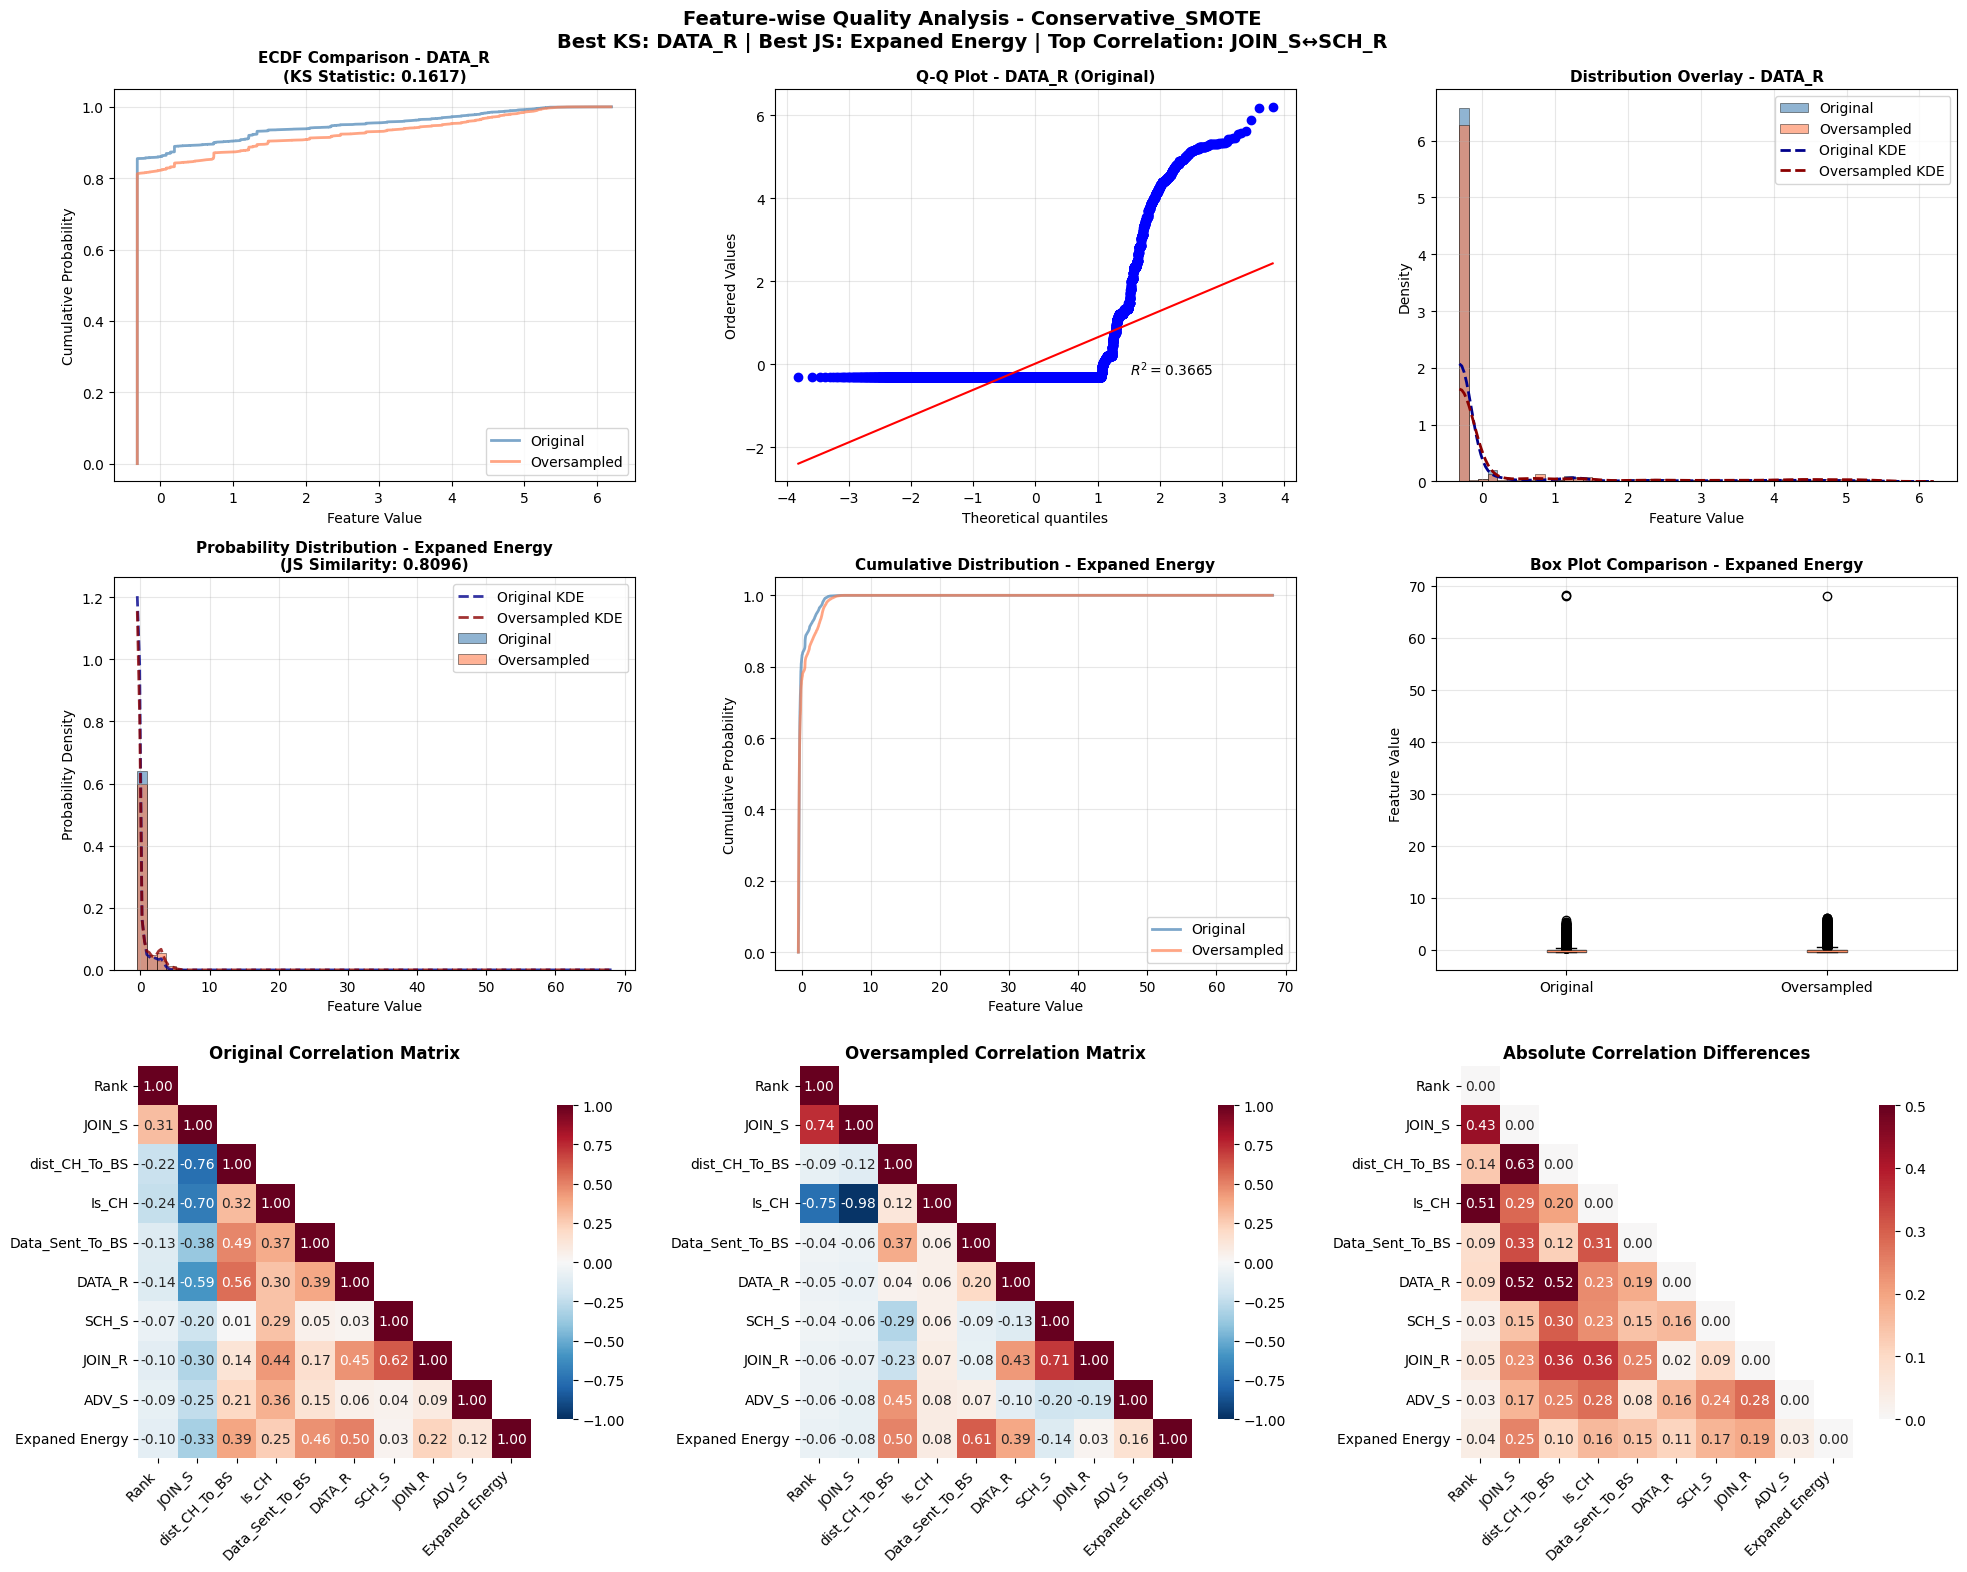


Detailed Feature Statistics:

DATA_R (Best KS Test Feature):
   Original: μ=0.0202, σ=1.0439
   Oversampled: μ=0.1685, σ=1.2699
   Mean difference: 0.1483
   Std difference: 0.2259

Expaned Energy (Best JS Divergence Feature):
   Original: μ=0.0201, σ=1.2771
   Oversampled: μ=0.1904, σ=1.3197
   Mean difference: 0.1703
   Std difference: 0.0426

Correlation Analysis:
   Top correlated pair: JOIN_S ↔ SCH_R
   Original correlation: 0.8965
   Oversampled correlation: 0.4399
   Correlation difference: 0.4567


In [226]:
# Feature-wise Quality Visualization: Best Examples from Each Test
print("Detailed Feature-wise Quality Visualization")
print("=" * 42)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def plot_ecdf(data, label, ax, color, alpha=0.7):
    """Plot Empirical Cumulative Distribution Function"""
    sorted_data = np.sort(data)
    y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, y, label=label, color=color, linewidth=2, alpha=alpha)
    return sorted_data, y

def plot_probability_distributions(original_data, oversampled_data, feature_name, ax, n_bins=50):
    """Plot probability distributions for Jensen-Shannon comparison"""
    
    # Calculate combined range
    combined_min = min(original_data.min(), oversampled_data.min())
    combined_max = max(original_data.max(), oversampled_data.max())
    
    # Create bins
    bins = np.linspace(combined_min, combined_max, n_bins)
    
    # Calculate histograms
    orig_hist, bin_edges = np.histogram(original_data, bins=bins, density=True)
    over_hist, _ = np.histogram(oversampled_data, bins=bins, density=True)
    
    # Calculate bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot probability distributions
    ax.bar(bin_centers, orig_hist, width=bin_centers[1]-bin_centers[0], 
           alpha=0.6, label='Original', color='steelblue', edgecolor='black', linewidth=0.5)
    ax.bar(bin_centers, over_hist, width=bin_centers[1]-bin_centers[0], 
           alpha=0.6, label='Oversampled', color='coral', edgecolor='black', linewidth=0.5)
    
    # Add KDE overlay
    try:
        if len(original_data) > 1 and np.var(original_data) > 0:
            kde_orig = gaussian_kde(original_data)
            x_range = np.linspace(combined_min, combined_max, 200)
            ax.plot(x_range, kde_orig(x_range), color='darkblue', linewidth=2, 
                   linestyle='--', alpha=0.8, label='Original KDE')
        
        if len(oversampled_data) > 1 and np.var(oversampled_data) > 0:
            kde_over = gaussian_kde(oversampled_data)
            ax.plot(x_range, kde_over(x_range), color='darkred', linewidth=2, 
                   linestyle='--', alpha=0.8, label='Oversampled KDE')
    except:
        pass
    
    return orig_hist, over_hist, bin_centers

def plot_correlation_heatmap(corr_matrix, title, ax, vmin=-1, vmax=1):
    """Plot correlation matrix heatmap"""
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, ax=ax,
                vmin=vmin, vmax=vmax, cbar_kws={"shrink": .8})
    ax.set_title(title, fontweight='bold', fontsize=12)

# Analyze and visualize best features from the best performing strategy
if quality_assessments:
    # Get the best strategy
    # best_strategy_name = max(quality_assessments.keys(), 
    #                        key=lambda x: quality_assessments[x]['quality_scores']['overall_quality'])
    best_strategy_name = "Conservative_SMOTE"
    best_assessment = quality_assessments[best_strategy_name]
    
    print(f"Analyzing best features from: {best_strategy_name}")
    print(f"Overall Quality Score: {best_assessment['quality_scores']['overall_quality']:.4f}")
    
    # Get the corresponding datasets for visualization
    X_original_viz = X_train_scaled.copy()
    X_oversampled_viz, _ = sampling_strategies[best_strategy_name]
    
    # Sample data for visualization if too large
    max_viz_samples = 10000
    if len(X_original_viz) > max_viz_samples:
        sample_idx = np.random.choice(len(X_original_viz), max_viz_samples, replace=False)
        X_original_viz = X_original_viz[sample_idx]
    
    if len(X_oversampled_viz) > max_viz_samples:
        sample_idx = np.random.choice(len(X_oversampled_viz), max_viz_samples, replace=False)
        X_oversampled_viz = X_oversampled_viz[sample_idx]
    
    # Find best features for each test
    
    # 1. Best KS Test feature (lowest KS statistic = most similar distributions)
    ks_results = best_assessment['ks_results']
    best_ks_feature = min(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])
    best_ks_stat = ks_results[best_ks_feature]['ks_statistic']
    
    # 2. Best JS Divergence feature (highest similarity score)
    js_results = best_assessment['js_results']
    best_js_feature = max(js_results.keys(), key=lambda x: js_results[x]['similarity_score'])
    best_js_score = js_results[best_js_feature]['similarity_score']
    
    # 3. Features for correlation analysis (select top correlated features)
    corr_results = best_assessment['correlation_results']
    corr_orig = corr_results['original_correlation_matrix']
    
    # Find the most highly correlated feature pair
    mask = np.triu(np.ones_like(corr_orig, dtype=bool), k=1)
    abs_corr = np.abs(corr_orig)
    abs_corr[~mask] = 0
    max_corr_idx = np.unravel_index(np.argmax(abs_corr), abs_corr.shape)
    
    feature_names = X.columns.tolist()
    corr_feature1 = feature_names[max_corr_idx[0]]
    corr_feature2 = feature_names[max_corr_idx[1]]
    max_corr_value = corr_orig[max_corr_idx]
    
    print(f"\nBest Features Identified:")
    print(f"   KS Test: {best_ks_feature} (KS statistic: {best_ks_stat:.4f})")
    print(f"   JS Divergence: {best_js_feature} (Similarity: {best_js_score:.4f})")
    print(f"   Correlation: {corr_feature1} ↔ {corr_feature2} (r = {max_corr_value:.4f})")
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 16))
    
    # 1. KS Test - ECDF Plot
    ax1 = plt.subplot(3, 3, 1)
    feature_idx = feature_names.index(best_ks_feature)
    orig_values = X_original_viz[:, feature_idx]
    over_values = X_oversampled_viz[:, feature_idx]
    
    plot_ecdf(orig_values, 'Original', ax1, 'steelblue')
    plot_ecdf(over_values, 'Oversampled', ax1, 'coral')
    
    ax1.set_title(f'ECDF Comparison - {best_ks_feature}\n(KS Statistic: {best_ks_stat:.4f})', 
                 fontweight='bold', fontsize=11)
    ax1.set_xlabel('Feature Value')
    ax1.set_ylabel('Cumulative Probability')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. KS Test - Q-Q Plot
    ax2 = plt.subplot(3, 3, 2)
    stats.probplot(orig_values, dist=stats.norm, plot=ax2, rvalue=True)
    ax2.set_title(f'Q-Q Plot - {best_ks_feature} (Original)', fontweight='bold', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. KS Test - Distribution Overlay
    ax3 = plt.subplot(3, 3, 3)
    ax3.hist(orig_values, bins=50, alpha=0.6, label='Original', density=True, 
             color='steelblue', edgecolor='black', linewidth=0.5)
    ax3.hist(over_values, bins=50, alpha=0.6, label='Oversampled', density=True, 
             color='coral', edgecolor='black', linewidth=0.5)
    
    # Add KDE overlays
    if len(orig_values) > 1 and np.var(orig_values) > 0:
        kde_orig = gaussian_kde(orig_values)
        x_range = np.linspace(min(orig_values.min(), over_values.min()), 
                             max(orig_values.max(), over_values.max()), 200)
        ax3.plot(x_range, kde_orig(x_range), color='darkblue', linewidth=2, 
                linestyle='--', label='Original KDE')
    
    if len(over_values) > 1 and np.var(over_values) > 0:
        kde_over = gaussian_kde(over_values)
        ax3.plot(x_range, kde_over(x_range), color='darkred', linewidth=2, 
                linestyle='--', label='Oversampled KDE')
    
    ax3.set_title(f'Distribution Overlay - {best_ks_feature}', fontweight='bold', fontsize=11)
    ax3.set_xlabel('Feature Value')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. JS Divergence - Probability Distribution
    ax4 = plt.subplot(3, 3, 4)
    feature_idx_js = feature_names.index(best_js_feature)
    orig_values_js = X_original_viz[:, feature_idx_js]
    over_values_js = X_oversampled_viz[:, feature_idx_js]
    
    orig_hist, over_hist, bin_centers = plot_probability_distributions(
        orig_values_js, over_values_js, best_js_feature, ax4)
    
    ax4.set_title(f'Probability Distribution - {best_js_feature}\n(JS Similarity: {best_js_score:.4f})', 
                 fontweight='bold', fontsize=11)
    ax4.set_xlabel('Feature Value')
    ax4.set_ylabel('Probability Density')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. JS Divergence - Cumulative Probability
    ax5 = plt.subplot(3, 3, 5)
    plot_ecdf(orig_values_js, 'Original', ax5, 'steelblue')
    plot_ecdf(over_values_js, 'Oversampled', ax5, 'coral')
    ax5.set_title(f'Cumulative Distribution - {best_js_feature}', fontweight='bold', fontsize=11)
    ax5.set_xlabel('Feature Value')
    ax5.set_ylabel('Cumulative Probability')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. JS Divergence - Box Plot Comparison
    ax6 = plt.subplot(3, 3, 6)
    box_data = [orig_values_js, over_values_js]
    box_labels = ['Original', 'Oversampled']
    bp = ax6.boxplot(box_data, labels=box_labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    
    ax6.set_title(f'Box Plot Comparison - {best_js_feature}', fontweight='bold', fontsize=11)
    ax6.set_ylabel('Feature Value')
    ax6.grid(True, alpha=0.3)
    
    # 7. Correlation - Original Matrix (subset)
    ax7 = plt.subplot(3, 3, 7)
    # Select top 10 most variable features for correlation visualization
    feature_vars = np.var(X_original_viz, axis=0)
    top_features_idx = np.argsort(feature_vars)[-10:]
    top_features = [feature_names[i] for i in top_features_idx]
    
    corr_subset_orig = corr_orig[np.ix_(top_features_idx, top_features_idx)]
    plot_correlation_heatmap(corr_subset_orig, 'Original Correlation Matrix', ax7)
    ax7.set_xticklabels(top_features, rotation=45, ha='right')
    ax7.set_yticklabels(top_features, rotation=0)
    
    # 8. Correlation - Oversampled Matrix (subset)
    ax8 = plt.subplot(3, 3, 8)
    corr_over = corr_results['oversampled_correlation_matrix']
    corr_subset_over = corr_over[np.ix_(top_features_idx, top_features_idx)]
    plot_correlation_heatmap(corr_subset_over, 'Oversampled Correlation Matrix', ax8)
    ax8.set_xticklabels(top_features, rotation=45, ha='right')
    ax8.set_yticklabels(top_features, rotation=0)
    
    # 9. Correlation - Difference Matrix
    ax9 = plt.subplot(3, 3, 9)
    corr_diff = np.abs(corr_subset_orig - corr_subset_over)
    plot_correlation_heatmap(corr_diff, 'Absolute Correlation Differences', ax9, vmin=0, vmax=0.5)
    ax9.set_xticklabels(top_features, rotation=45, ha='right')
    ax9.set_yticklabels(top_features, rotation=0)
    
    plt.suptitle(f'Feature-wise Quality Analysis - {best_strategy_name}\n' + 
                 f'Best KS: {best_ks_feature} | Best JS: {best_js_feature} | ' + 
                 f'Top Correlation: {corr_feature1}↔{corr_feature2}', 
                 fontweight='bold', fontsize=14, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    # Additional detailed statistics
    print(f"\nDetailed Feature Statistics:")
    print("=" * 30)
    
    print(f"\n{best_ks_feature} (Best KS Test Feature):")
    print(f"   Original: μ={np.mean(orig_values):.4f}, σ={np.std(orig_values):.4f}")
    print(f"   Oversampled: μ={np.mean(over_values):.4f}, σ={np.std(over_values):.4f}")
    print(f"   Mean difference: {abs(np.mean(orig_values) - np.mean(over_values)):.4f}")
    print(f"   Std difference: {abs(np.std(orig_values) - np.std(over_values)):.4f}")
    
    print(f"\n{best_js_feature} (Best JS Divergence Feature):")
    print(f"   Original: μ={np.mean(orig_values_js):.4f}, σ={np.std(orig_values_js):.4f}")
    print(f"   Oversampled: μ={np.mean(over_values_js):.4f}, σ={np.std(over_values_js):.4f}")
    print(f"   Mean difference: {abs(np.mean(orig_values_js) - np.mean(over_values_js)):.4f}")
    print(f"   Std difference: {abs(np.std(orig_values_js) - np.std(over_values_js)):.4f}")
    
    print(f"\nCorrelation Analysis:")
    print(f"   Top correlated pair: {corr_feature1} ↔ {corr_feature2}")
    print(f"   Original correlation: {max_corr_value:.4f}")
    feature1_idx = feature_names.index(corr_feature1)
    feature2_idx = feature_names.index(corr_feature2)
    over_corr_value = corr_over[feature1_idx, feature2_idx]
    print(f"   Oversampled correlation: {over_corr_value:.4f}")
    print(f"   Correlation difference: {abs(max_corr_value - over_corr_value):.4f}")
    
else:
    print("No quality assessments available. Please run the evaluation first.")

In [58]:
quality_assessments["BorderlineSMOTE"][0]["ks_results"]

for key, value in quality_assessments["BorderlineSMOTE"][0]["ks_results"].items():
    print(f"{key}: KS Statistic = {value['ks_statistic']:.4f}, P-Value = {value['p_value']:.4f}, Significant = {value['significant_difference']}")

Time: KS Statistic = 0.2320, P-Value = 0.0000, Significant = True
Is_CH: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
Dist_To_CH: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
ADV_S: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
ADV_R: KS Statistic = 0.1710, P-Value = 0.0000, Significant = True
JOIN_S: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
JOIN_R: KS Statistic = 0.3448, P-Value = 0.0000, Significant = True
SCH_S: KS Statistic = 0.3448, P-Value = 0.0000, Significant = True
SCH_R: KS Statistic = 0.0257, P-Value = 0.3731, Significant = False
Rank: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
DATA_S: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
DATA_R: KS Statistic = 0.3547, P-Value = 0.0000, Significant = True
Data_Sent_To_BS: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
dist_CH_To_BS: KS Statistic = 0.0000, P-Value = 1.0000, Significant = False
send_code: KS Statistic = 0.

In [84]:
quality_assessments["Conservative_SMOTE"]

{0: {'strategy_name': 'Conservative_SMOTE',
  'ks_results': {'Time': {'ks_statistic': np.float64(0.19279493269992082),
    'p_value': np.float64(1.8897835464453077e-41),
    'significant_difference': np.True_},
   'Is_CH': {'ks_statistic': np.float64(0.0),
    'p_value': np.float64(1.0),
    'significant_difference': np.False_},
   'Dist_To_CH': {'ks_statistic': 0.0,
    'p_value': 1.0,
    'significant_difference': False},
   'ADV_S': {'ks_statistic': np.float64(0.0),
    'p_value': np.float64(1.0),
    'significant_difference': np.False_},
   'ADV_R': {'ks_statistic': np.float64(0.26167854315122724),
    'p_value': np.float64(2.0655237118716597e-76),
    'significant_difference': np.True_},
   'JOIN_S': {'ks_statistic': np.float64(0.0),
    'p_value': np.float64(1.0),
    'significant_difference': np.False_},
   'JOIN_R': {'ks_statistic': np.float64(0.24742676167854316),
    'p_value': np.float64(2.8319706669241092e-68),
    'significant_difference': np.True_},
   'SCH_S': {'ks_stati

In [151]:
values = []
for key, value in quality_assessments["ADASYN"].items():
    print(f"for class: {key}")
    print(f"{value['correlation_results']['correlation_correlation']}")
    values.append(value['correlation_results']['correlation_correlation'])

mean_val = sum(values) / len(values)
print("Mean:", mean_val)

for class: 0
0.9824170912354147
for class: 1
0.9922134290705793
for class: 2
0.9799851868997322
for class: 4
0.6767433446202131
Mean: 0.9078397629564849


Focused Individual Visualizations for Quality Metrics

1. Kolmogorov-Smirnov Test Analysis - Expaned Energy


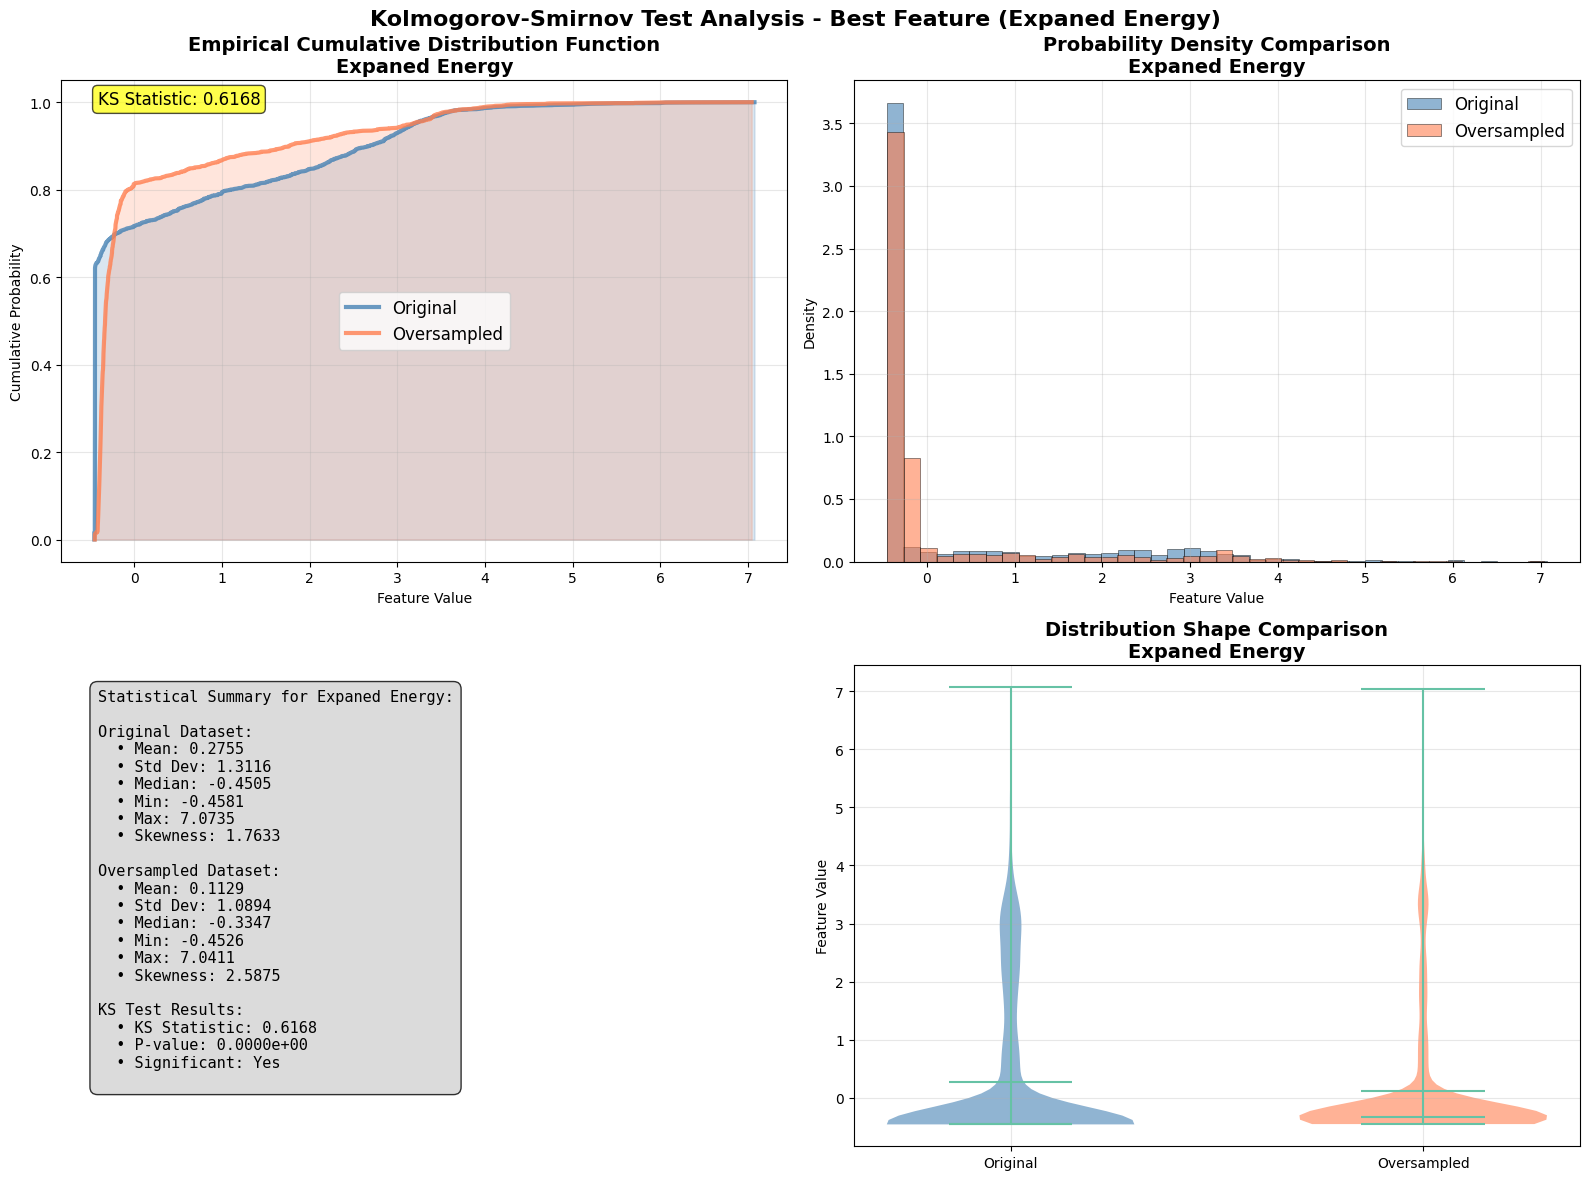


2. Jensen-Shannon Divergence Analysis - Expaned Energy


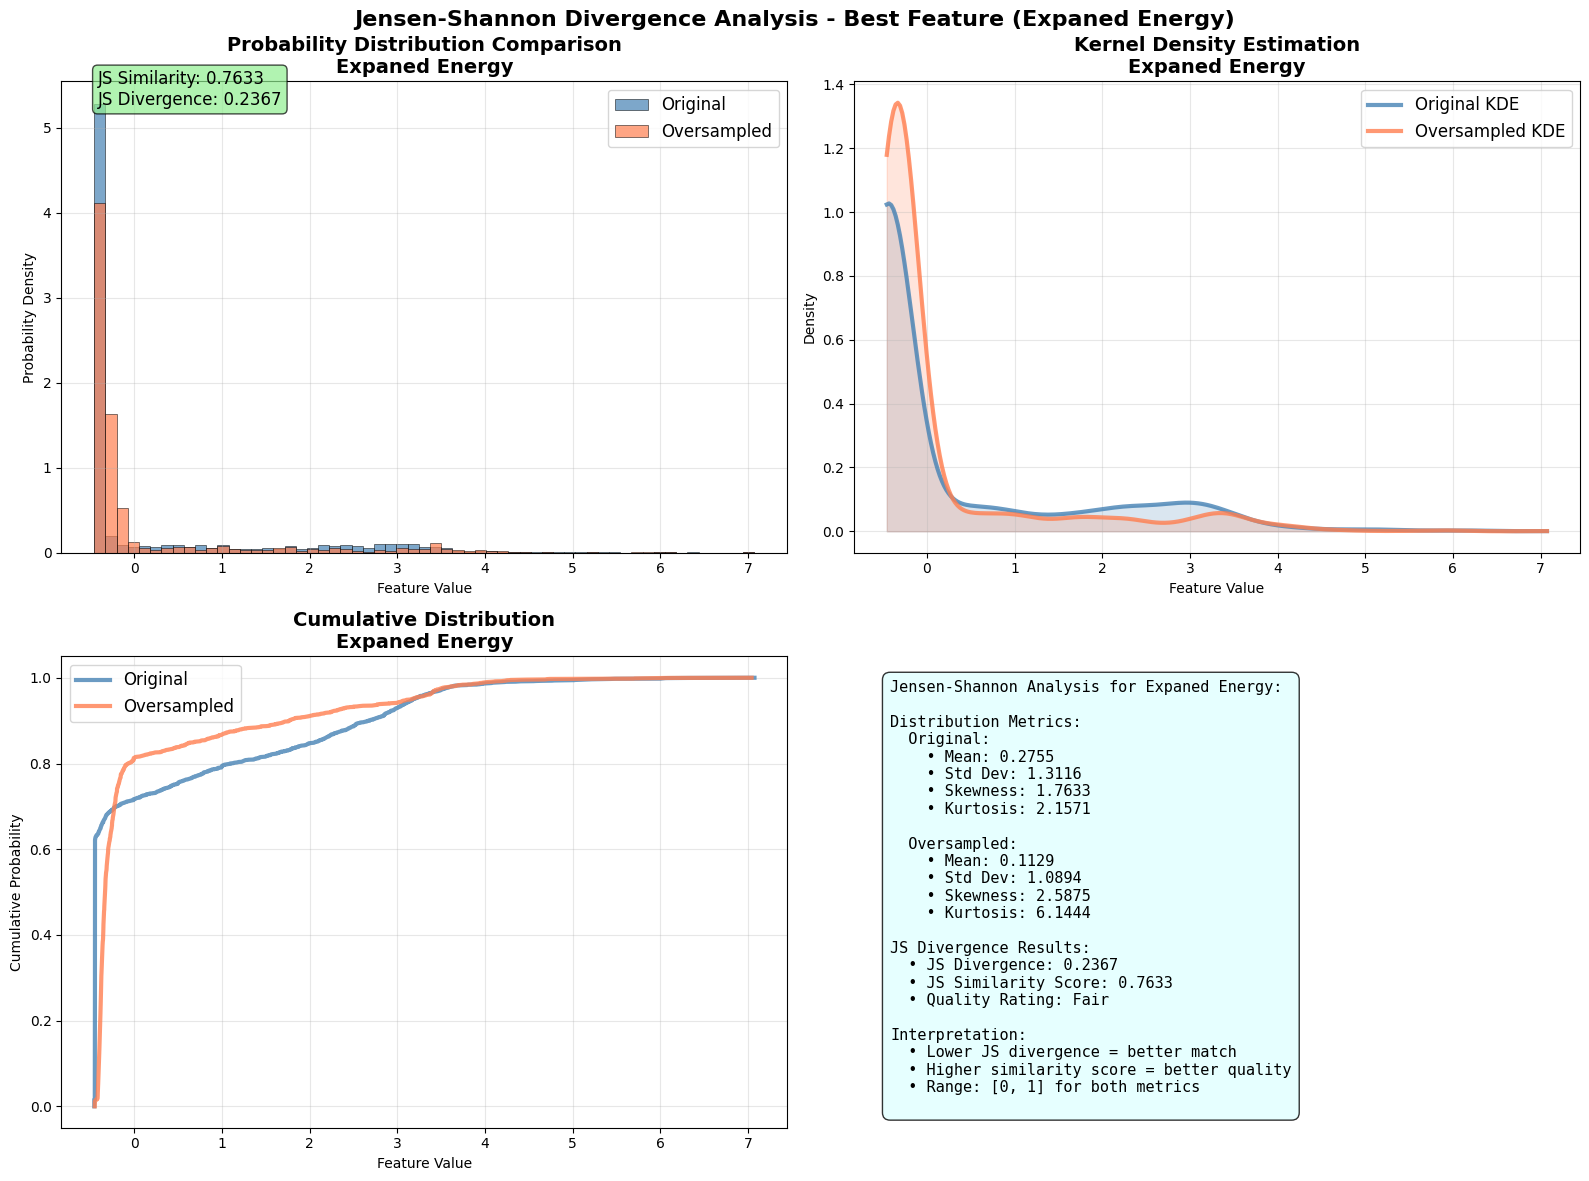


3. Correlation Preservation Analysis


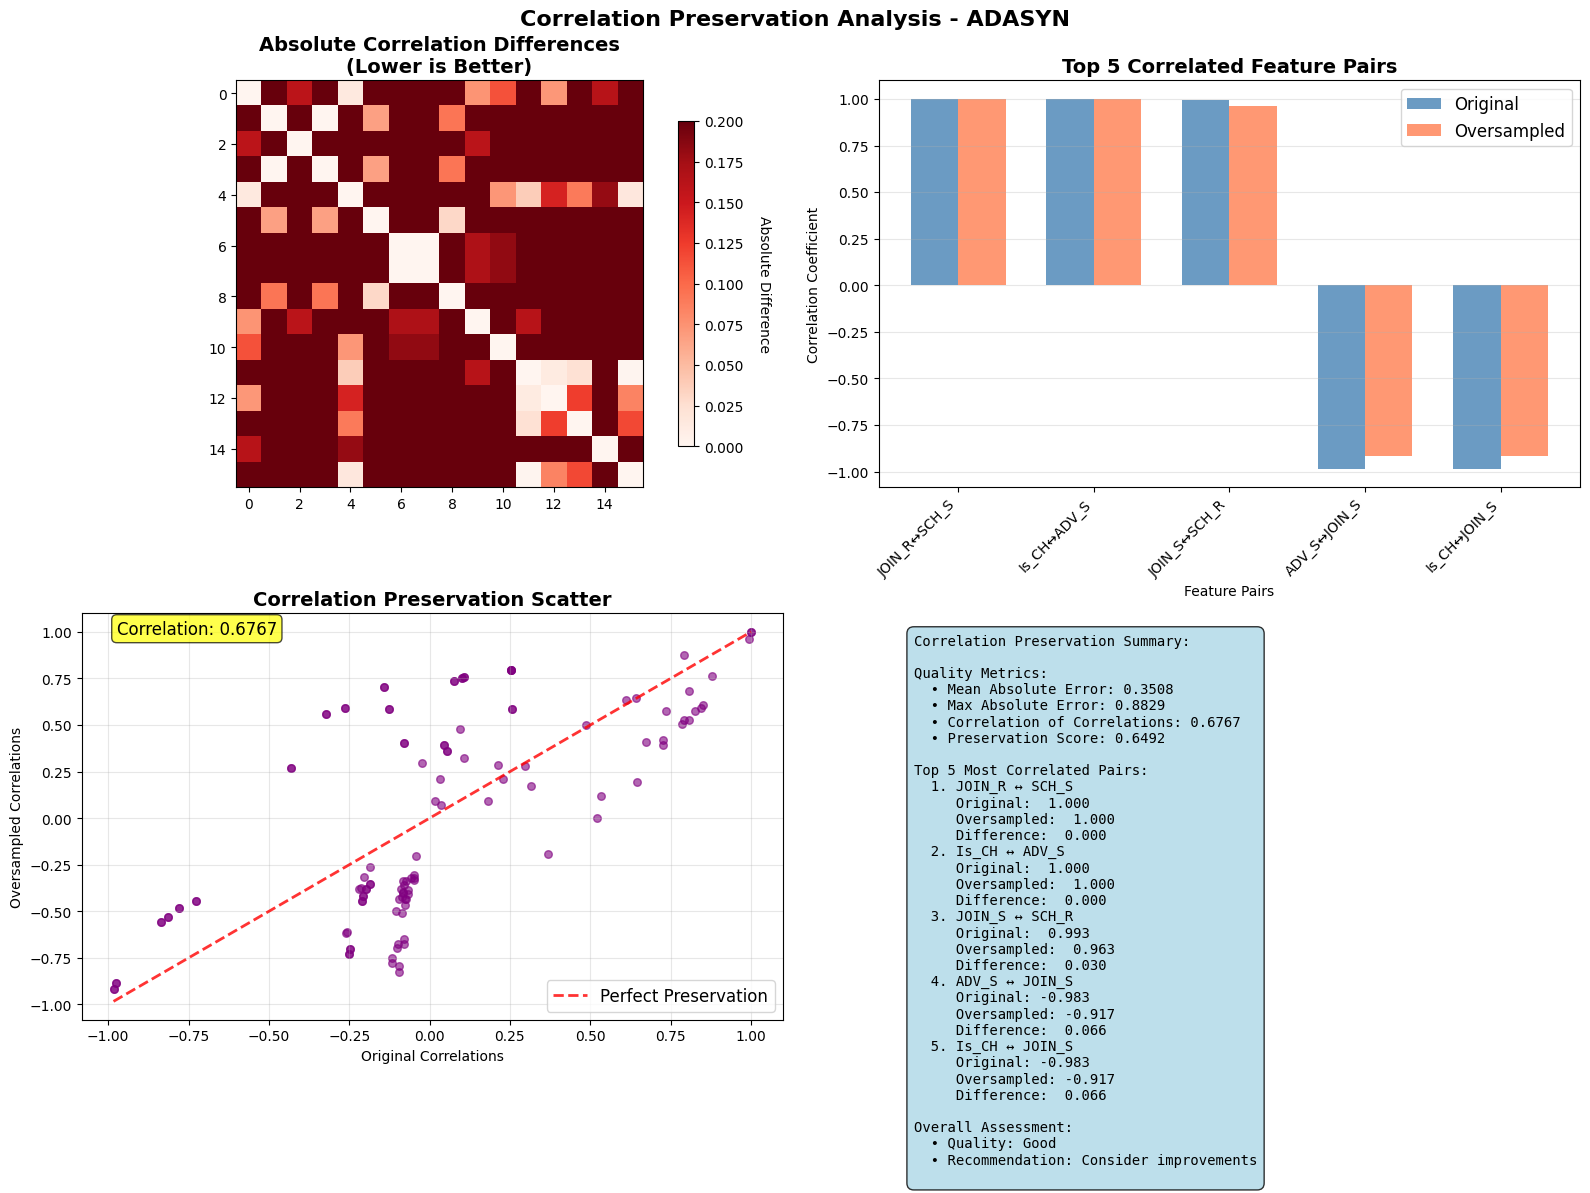

In [188]:
# Individual Focused Visualizations for Each Quality Metric
print("Focused Individual Visualizations for Quality Metrics")
print("=" * 52)

if quality_assessments:
    # max(quality_assessments.keys(), key=lambda x: quality_assessments[x]['quality_scores']['overall_quality'])
    best_strategy_name = "ADASYN"  # Example: specify the strategy to visualize
    class_encoded = 4
    best_assessment = quality_assessments[best_strategy_name][class_encoded]

    X_orig_sample = X_reference.copy()

    X_oversampled, y_oversampled = sampling_strategies[best_strategy_name]
    
    orig_view = X_orig_sample.view([('', X_orig_sample.dtype)] * X_orig_sample.shape[1])
    oversampled_view = X_oversampled.view([('', X_oversampled.dtype)] * X_oversampled.shape[1])

    synthetic_mask = ~np.isin(oversampled_view, orig_view)
    X_over_sample = X_oversampled[synthetic_mask.ravel()]
    y_over_sample = y_oversampled[synthetic_mask.ravel()]

    X_original_viz, y_orig_sample = sample_per_class(X_orig_sample, y_train, n=2526, random_state=42)
    X_oversampled_viz, y_over_sample = sample_per_class(X_over_sample, y_over_sample, n=2526, random_state=42)

    X_original_viz = X_original_viz[y_orig_sample == class_encoded]
    X_oversampled_viz = X_oversampled_viz[y_over_sample == class_encoded]
    
    feature_names = X.columns.tolist()
    
    # Get best features
    ks_results = best_assessment['ks_results']
    best_ks_feature = min(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])
    best_ks_feature = 'Expaned Energy'
    
    js_results = best_assessment['js_results']
    best_js_feature = max(js_results.keys(), key=lambda x: js_results[x]['similarity_score'])
    best_js_feature = 'Expaned Energy'

    # 1. Focused KS Test Visualization
    print(f"\n1. Kolmogorov-Smirnov Test Analysis - {best_ks_feature}")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    feature_idx = feature_names.index(best_ks_feature)
    orig_values = X_original_viz[:, feature_idx]
    over_values = X_oversampled_viz[:, feature_idx]
    
    # ECDF Plot
    sorted_orig = np.sort(orig_values)
    sorted_over = np.sort(over_values)
    y_orig = np.arange(1, len(sorted_orig) + 1) / len(sorted_orig)
    y_over = np.arange(1, len(sorted_over) + 1) / len(sorted_over)
    
    axes[0,0].plot(sorted_orig, y_orig, label='Original', color='steelblue', linewidth=3, alpha=0.8)
    axes[0,0].plot(sorted_over, y_over, label='Oversampled', color='coral', linewidth=3, alpha=0.8)
    axes[0,0].fill_between(sorted_orig, y_orig, alpha=0.2, color='steelblue')
    axes[0,0].fill_between(sorted_over, y_over, alpha=0.2, color='coral')
    
    axes[0,0].set_title(f'Empirical Cumulative Distribution Function\n{best_ks_feature}', 
                       fontweight='bold', fontsize=14)
    axes[0,0].set_xlabel('Feature Value')
    axes[0,0].set_ylabel('Cumulative Probability')
    axes[0,0].legend(fontsize=12)
    axes[0,0].grid(True, alpha=0.3)
    
    # Add KS statistic annotation
    ks_stat = ks_results[best_ks_feature]['ks_statistic']
    axes[0,0].text(0.05, 0.95, f'KS Statistic: {ks_stat:.4f}', 
                  transform=axes[0,0].transAxes, fontsize=12, 
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # Distribution comparison
    axes[0,1].hist(orig_values, bins=40, alpha=0.6, label='Original', density=True, 
                  color='steelblue', edgecolor='black', linewidth=0.5)
    axes[0,1].hist(over_values, bins=40, alpha=0.6, label='Oversampled', density=True, 
                  color='coral', edgecolor='black', linewidth=0.5)
    
    axes[0,1].set_title(f'Probability Density Comparison\n{best_ks_feature}', 
                       fontweight='bold', fontsize=14)
    axes[0,1].set_xlabel('Feature Value')
    axes[0,1].set_ylabel('Density')
    axes[0,1].legend(fontsize=12)
    axes[0,1].grid(True, alpha=0.3)
    
    # Statistical summary
    axes[1,0].axis('off')
    stats_text = f"""Statistical Summary for {best_ks_feature}:
    
Original Dataset:
  • Mean: {np.mean(orig_values):.4f}
  • Std Dev: {np.std(orig_values):.4f}
  • Median: {np.median(orig_values):.4f}
  • Min: {np.min(orig_values):.4f}
  • Max: {np.max(orig_values):.4f}
  • Skewness: {stats.skew(orig_values):.4f}

Oversampled Dataset:
  • Mean: {np.mean(over_values):.4f}
  • Std Dev: {np.std(over_values):.4f}
  • Median: {np.median(over_values):.4f}
  • Min: {np.min(over_values):.4f}
  • Max: {np.max(over_values):.4f}
  • Skewness: {stats.skew(over_values):.4f}

KS Test Results:
  • KS Statistic: {ks_stat:.4f}
  • P-value: {ks_results[best_ks_feature]['p_value']:.4e}
  • Significant: {'Yes' if ks_results[best_ks_feature]['significant_difference'] else 'No'}
    """
    
    axes[1,0].text(0.05, 0.95, stats_text, transform=axes[1,0].transAxes, 
                  fontsize=11, verticalalignment='top', fontfamily='monospace',
                  bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    # Violin plot comparison
    violin_parts = axes[1,1].violinplot([orig_values, over_values], positions=[1, 2], 
                                       widths=0.6, showmeans=True, showmedians=True)
    
    for i, pc in enumerate(violin_parts['bodies']):
        pc.set_facecolor(['steelblue', 'coral'][i])
        pc.set_alpha(0.6)
    
    axes[1,1].set_title(f'Distribution Shape Comparison\n{best_ks_feature}', 
                       fontweight='bold', fontsize=14)
    axes[1,1].set_xticks([1, 2])
    axes[1,1].set_xticklabels(['Original', 'Oversampled'])
    axes[1,1].set_ylabel('Feature Value')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Kolmogorov-Smirnov Test Analysis - Best Feature ({best_ks_feature})', 
                 fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 2. Focused Jensen-Shannon Divergence Visualization
    print(f"\n2. Jensen-Shannon Divergence Analysis - {best_js_feature}")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    feature_idx_js = feature_names.index(best_js_feature)
    orig_values_js = X_original_viz[:, feature_idx_js]
    over_values_js = X_oversampled_viz[:, feature_idx_js]
    
    # Probability distributions with detailed binning
    n_bins = 60
    combined_min = min(orig_values_js.min(), over_values_js.min())
    combined_max = max(orig_values_js.max(), over_values_js.max())
    bins = np.linspace(combined_min, combined_max, n_bins)
    
    orig_hist, _ = np.histogram(orig_values_js, bins=bins, density=True)
    over_hist, _ = np.histogram(over_values_js, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    axes[0,0].bar(bin_centers, orig_hist, width=bin_centers[1]-bin_centers[0], 
                 alpha=0.7, label='Original', color='steelblue', edgecolor='black', linewidth=0.5)
    axes[0,0].bar(bin_centers, over_hist, width=bin_centers[1]-bin_centers[0], 
                 alpha=0.7, label='Oversampled', color='coral', edgecolor='black', linewidth=0.5)
    
    js_score = js_results[best_js_feature]['similarity_score']
    js_div = js_results[best_js_feature]['js_divergence']
    
    axes[0,0].set_title(f'Probability Distribution Comparison\n{best_js_feature}', 
                       fontweight='bold', fontsize=14)
    axes[0,0].set_xlabel('Feature Value')
    axes[0,0].set_ylabel('Probability Density')
    axes[0,0].legend(fontsize=12)
    axes[0,0].grid(True, alpha=0.3)
    
    # Add JS annotation
    axes[0,0].text(0.05, 0.95, f'JS Similarity: {js_score:.4f}\nJS Divergence: {js_div:.4f}', 
                  transform=axes[0,0].transAxes, fontsize=12, 
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
    
    # Overlapping probability curves
    from scipy.stats import gaussian_kde
    if len(orig_values_js) > 1 and np.var(orig_values_js) > 0:
        kde_orig = gaussian_kde(orig_values_js)
        x_range = np.linspace(combined_min, combined_max, 300)
        y_orig_kde = kde_orig(x_range)
        axes[0,1].plot(x_range, y_orig_kde, color='steelblue', linewidth=3, 
                      label='Original KDE', alpha=0.8)
        axes[0,1].fill_between(x_range, y_orig_kde, alpha=0.2, color='steelblue')
    
    if len(over_values_js) > 1 and np.var(over_values_js) > 0:
        kde_over = gaussian_kde(over_values_js)
        y_over_kde = kde_over(x_range)
        axes[0,1].plot(x_range, y_over_kde, color='coral', linewidth=3, 
                      label='Oversampled KDE', alpha=0.8)
        axes[0,1].fill_between(x_range, y_over_kde, alpha=0.2, color='coral')
    
    axes[0,1].set_title(f'Kernel Density Estimation\n{best_js_feature}', 
                       fontweight='bold', fontsize=14)
    axes[0,1].set_xlabel('Feature Value')
    axes[0,1].set_ylabel('Density')
    axes[0,1].legend(fontsize=12)
    axes[0,1].grid(True, alpha=0.3)
    
    # Cumulative probability comparison
    sorted_orig_js = np.sort(orig_values_js)
    sorted_over_js = np.sort(over_values_js)
    y_orig_js = np.arange(1, len(sorted_orig_js) + 1) / len(sorted_orig_js)
    y_over_js = np.arange(1, len(sorted_over_js) + 1) / len(sorted_over_js)
    
    axes[1,0].plot(sorted_orig_js, y_orig_js, label='Original', color='steelblue', 
                  linewidth=3, alpha=0.8)
    axes[1,0].plot(sorted_over_js, y_over_js, label='Oversampled', color='coral', 
                  linewidth=3, alpha=0.8)
    
    axes[1,0].set_title(f'Cumulative Distribution\n{best_js_feature}', 
                       fontweight='bold', fontsize=14)
    axes[1,0].set_xlabel('Feature Value')
    axes[1,0].set_ylabel('Cumulative Probability')
    axes[1,0].legend(fontsize=12)
    axes[1,0].grid(True, alpha=0.3)
    
    # Statistical comparison table
    axes[1,1].axis('off')
    
    comparison_text = f"""Jensen-Shannon Analysis for {best_js_feature}:

Distribution Metrics:
  Original:
    • Mean: {np.mean(orig_values_js):.4f}
    • Std Dev: {np.std(orig_values_js):.4f}
    • Skewness: {stats.skew(orig_values_js):.4f}
    • Kurtosis: {stats.kurtosis(orig_values_js):.4f}
  
  Oversampled:
    • Mean: {np.mean(over_values_js):.4f}
    • Std Dev: {np.std(over_values_js):.4f}
    • Skewness: {stats.skew(over_values_js):.4f}
    • Kurtosis: {stats.kurtosis(over_values_js):.4f}

JS Divergence Results:
  • JS Divergence: {js_div:.4f}
  • JS Similarity Score: {js_score:.4f}
  • Quality Rating: {'Excellent' if js_score > 0.9 else 'Good' if js_score > 0.8 else 'Fair'}
  
Interpretation:
  • Lower JS divergence = better match
  • Higher similarity score = better quality
  • Range: [0, 1] for both metrics
    """
    
    axes[1,1].text(0.05, 0.95, comparison_text, transform=axes[1,1].transAxes, 
                  fontsize=11, verticalalignment='top', fontfamily='monospace',
                  bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcyan", alpha=0.8))
    
    plt.suptitle(f'Jensen-Shannon Divergence Analysis - Best Feature ({best_js_feature})', 
                 fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 3. Correlation Preservation Analysis
    print(f"\n3. Correlation Preservation Analysis")
    print("=" * 40)
    
    corr_results = best_assessment['correlation_results']
    corr_orig = corr_results['original_correlation_matrix']
    corr_over = corr_results['oversampled_correlation_matrix']
    
    # Find top correlated pairs
    mask = np.triu(np.ones_like(corr_orig, dtype=bool), k=1)
    abs_corr = np.abs(corr_orig)
    abs_corr[~mask] = 0
    
    # Get top 5 most correlated pairs
    flat_indices = np.argsort(abs_corr.flatten())[::-1]
    top_pairs = []
    for idx in flat_indices:
        i, j = np.unravel_index(idx, abs_corr.shape)
        if abs_corr[i, j] > 0:
            top_pairs.append((i, j, corr_orig[i, j], corr_over[i, j]))
        if len(top_pairs) >= 5:
            break
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Correlation difference heatmap
    corr_diff = np.abs(corr_orig - corr_over)
    im = axes[0,0].imshow(corr_diff, cmap='Reds', vmin=0, vmax=0.2)
    axes[0,0].set_title('Absolute Correlation Differences\n(Lower is Better)', 
                       fontweight='bold', fontsize=14)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[0,0], shrink=0.8)
    cbar.set_label('Absolute Difference', rotation=270, labelpad=20)
    
    # Top correlated pairs visualization
    pair_names = []
    orig_corrs = []
    over_corrs = []
    differences = []
    
    for i, j, orig_val, over_val in top_pairs:
        feat1 = feature_names[i]
        feat2 = feature_names[j]
        pair_names.append(f'{feat1[:8]}↔{feat2[:8]}')
        orig_corrs.append(orig_val)
        over_corrs.append(over_val)
        differences.append(abs(orig_val - over_val))
    
    x = np.arange(len(pair_names))
    width = 0.35
    
    axes[0,1].bar(x - width/2, orig_corrs, width, label='Original', 
                 color='steelblue', alpha=0.8)
    axes[0,1].bar(x + width/2, over_corrs, width, label='Oversampled', 
                 color='coral', alpha=0.8)
    
    axes[0,1].set_title('Top 5 Correlated Feature Pairs', fontweight='bold', fontsize=14)
    axes[0,1].set_xlabel('Feature Pairs')
    axes[0,1].set_ylabel('Correlation Coefficient')
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(pair_names, rotation=45, ha='right')
    axes[0,1].legend(fontsize=12)
    axes[0,1].grid(True, alpha=0.3, axis='y')
    
    # Correlation preservation scatter plot
    mask = np.triu(np.ones_like(corr_orig, dtype=bool), k=1)
    orig_flat = corr_orig[mask]
    over_flat = corr_over[mask]
    
    axes[1,0].scatter(orig_flat, over_flat, alpha=0.6, s=30, color='purple')
    
    # Add perfect correlation line
    min_val = min(orig_flat.min(), over_flat.min())
    max_val = max(orig_flat.max(), over_flat.max())
    axes[1,0].plot([min_val, max_val], [min_val, max_val], 'r--', 
                  linewidth=2, alpha=0.8, label='Perfect Preservation')
    
    # Calculate and display correlation
    preservation_corr = np.corrcoef(orig_flat, over_flat)[0, 1]
    axes[1,0].text(0.05, 0.95, f'Correlation: {preservation_corr:.4f}', 
                  transform=axes[1,0].transAxes, fontsize=12,
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    axes[1,0].set_title('Correlation Preservation Scatter', fontweight='bold', fontsize=14)
    axes[1,0].set_xlabel('Original Correlations')
    axes[1,0].set_ylabel('Oversampled Correlations')
    axes[1,0].legend(fontsize=12)
    axes[1,0].grid(True, alpha=0.3)
    
    # Summary statistics
    axes[1,1].axis('off')
    
    mean_abs_error = corr_results['mean_absolute_error']
    max_abs_error = corr_results['max_absolute_error']
    corr_of_corr = corr_results['correlation_correlation']
    preservation_score = corr_results['correlation_preservation_score']
    
    summary_text = f"""Correlation Preservation Summary:

Quality Metrics:
  • Mean Absolute Error: {mean_abs_error:.4f}
  • Max Absolute Error: {max_abs_error:.4f}
  • Correlation of Correlations: {corr_of_corr:.4f}
  • Preservation Score: {preservation_score:.4f}

Top 5 Most Correlated Pairs:
"""
    
    for i, (idx1, idx2, orig_val, over_val) in enumerate(top_pairs, 1):
        feat1 = feature_names[idx1]
        feat2 = feature_names[idx2]
        diff = abs(orig_val - over_val)
        summary_text += f"""  {i}. {feat1} ↔ {feat2}
     Original: {orig_val:6.3f}
     Oversampled: {over_val:6.3f}
     Difference: {diff:6.3f}
"""
    
    summary_text += f"""
Overall Assessment:
  • Quality: {'Excellent' if preservation_score > 0.8 else 'Good' if preservation_score > 0.6 else 'Fair'}
  • Recommendation: {'Use for production' if preservation_score > 0.7 else 'Consider improvements'}
    """
    
    axes[1,1].text(0.05, 0.95, summary_text, transform=axes[1,1].transAxes, 
                  fontsize=10, verticalalignment='top', fontfamily='monospace',
                  bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.suptitle(f'Correlation Preservation Analysis - {best_strategy_name}', 
                 fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
    
else:
    print("No quality assessments available. Please run the evaluation first.")

Feature Score Export and Visualization
Exporting detailed feature scores to CSV files...
   Exported: feature_scores_smote_enn.csv
   Exported: feature_scores_borderlinesmote.csv
   Exported: feature_scores_adasyn.csv
   Exported: feature_scores_conservative_smote.csv
   Exported: feature_comparison_across_methods.csv
   Exported: method_performance_summary.csv

Creating comprehensive score visualizations...


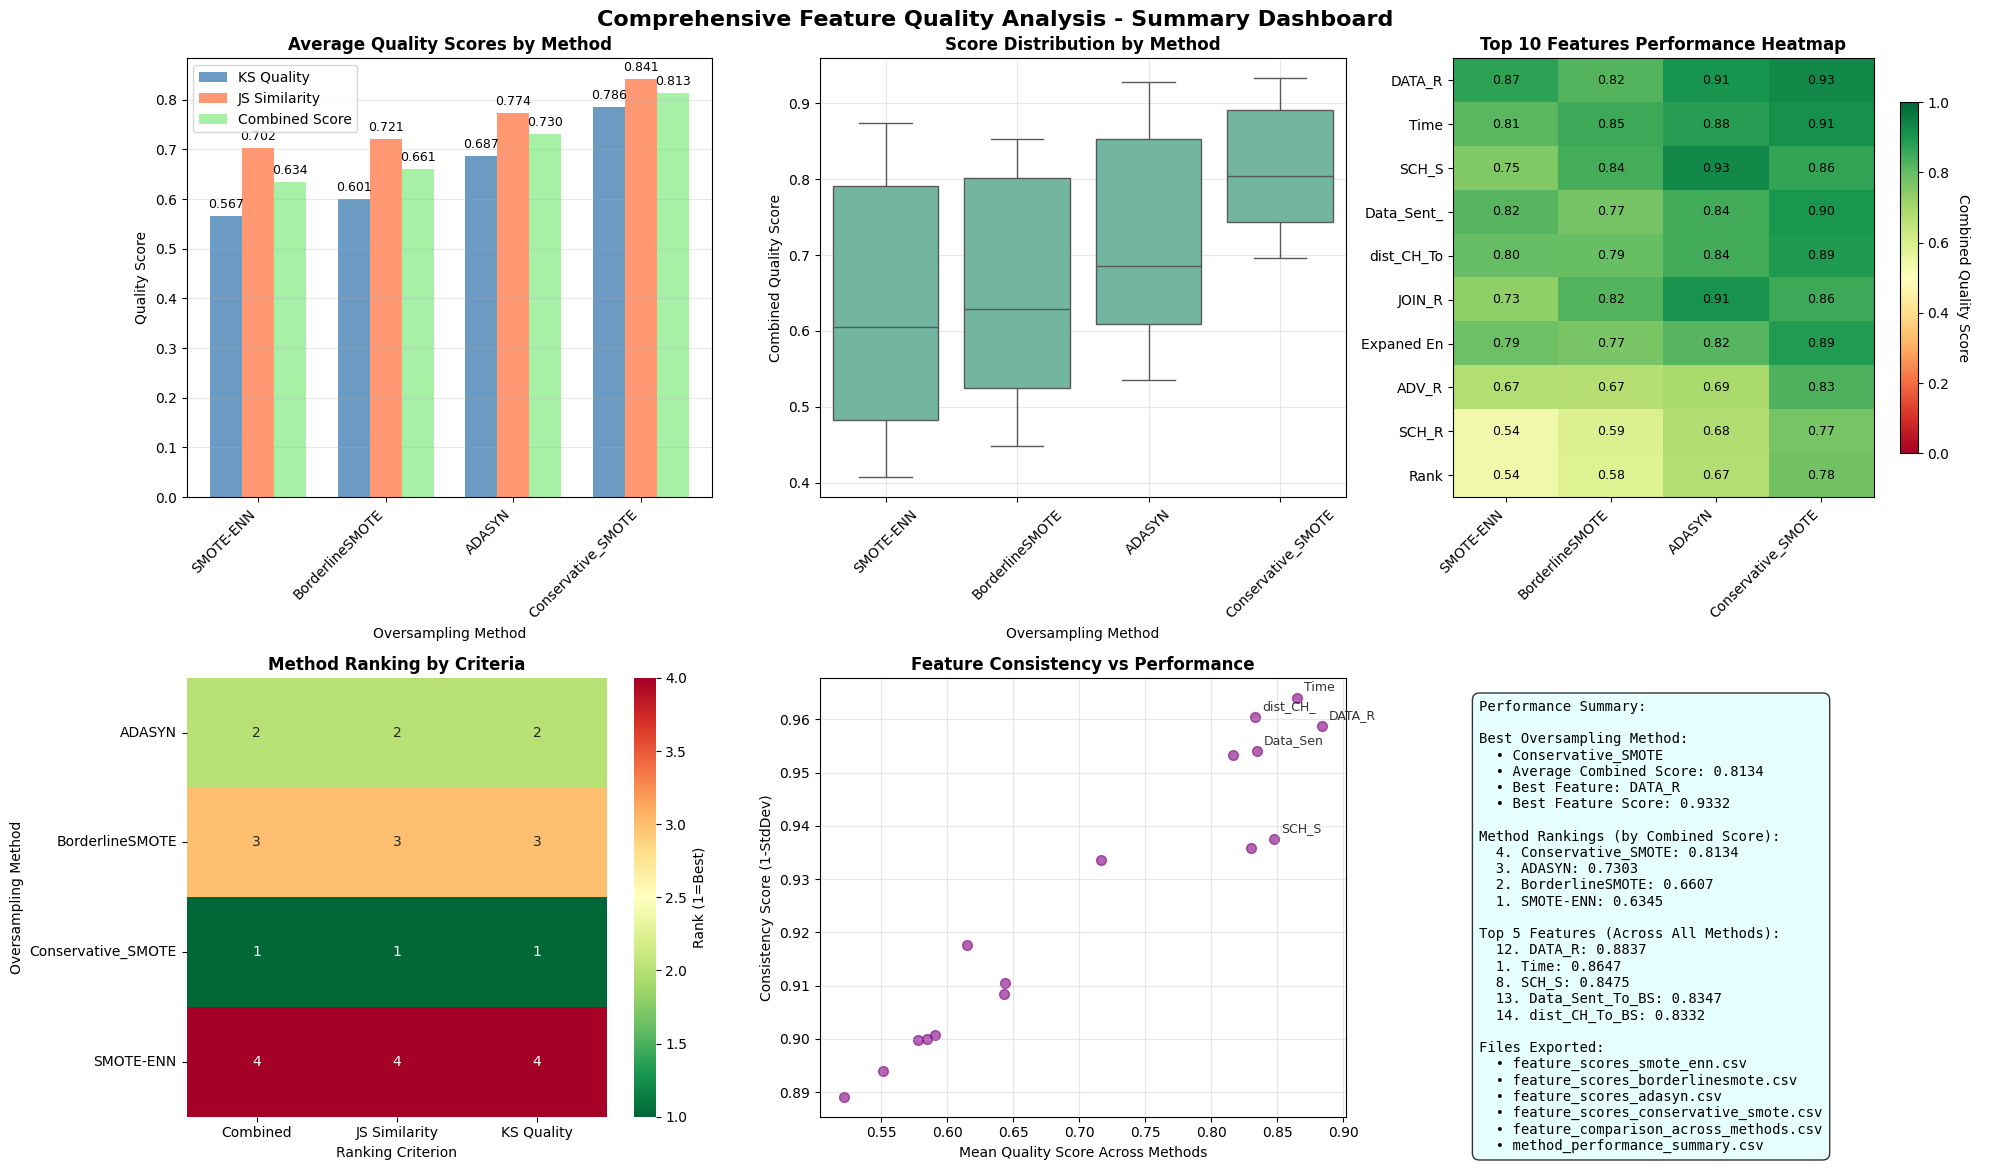


Creating detailed feature ranking table...
   Exported: detailed_feature_ranking.csv

Top 20 Features - Detailed Ranking Across All Methods:
        Feature  Avg_Score  Avg_Rank  Score_Std  SMOTE-ENN_Score  BorderlineSMOTE_Score  ADASYN_Score  Conservative_SMOTE_Score  Avg_Score
         DATA_R     0.8837      2.00     0.0412           0.8735                 0.8223        0.9058                    0.9332     0.8837
           Time     0.8647      2.50     0.0360           0.8141                 0.8528        0.8800                    0.9120     0.8647
          SCH_S     0.8475      3.75     0.0624           0.7544                 0.8430        0.9288                    0.8638     0.8475
Data_Sent_To_BS     0.8347      4.25     0.0460           0.8181                 0.7748        0.8441                    0.9018     0.8347
  dist_CH_To_BS     0.8332      4.50     0.0395           0.8004                 0.7950        0.8446                    0.8930     0.8332
         JOIN_R     0.83

In [22]:
# Export Feature Scores and Create Summary Visualizations
print("Feature Score Export and Visualization")
print("=" * 38)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

if quality_assessments and 'all_results' in locals():
    
    # 1. Export detailed scores to CSV
    print("Exporting detailed feature scores to CSV files...")
    
    for strategy_name, df in all_results.items():
        filename = f"feature_scores_{strategy_name.lower().replace(' ', '_').replace('-', '_')}.csv"
        df.to_csv(filename, index=False)
        print(f"   Exported: {filename}")
    
    # Export comparison data
    if 'comparison_df' in locals():
        comparison_df.to_csv("feature_comparison_across_methods.csv", index=False)
        print(f"   Exported: feature_comparison_across_methods.csv")
    
    if 'summary_df' in locals():
        summary_df.to_csv("method_performance_summary.csv", index=False)
        print(f"   Exported: method_performance_summary.csv")
    
    # 2. Create comprehensive visualization
    print(f"\nCreating comprehensive score visualizations...")
    
    # Prepare data for visualization
    all_strategies = list(all_results.keys())
    n_strategies = len(all_strategies)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Average scores by method
    method_avg_scores = []
    method_names = []
    ks_scores = []
    js_scores = []
    combined_scores = []
    
    for strategy_name, df in all_results.items():
        method_names.append(strategy_name)
        ks_scores.append(df['KS_Quality_Score'].mean())
        js_scores.append(df['JS_Similarity'].mean())
        combined_scores.append(df['Combined_Score'].mean())
    
    x = np.arange(len(method_names))
    width = 0.25
    
    axes[0,0].bar(x - width, ks_scores, width, label='KS Quality', alpha=0.8, color='steelblue')
    axes[0,0].bar(x, js_scores, width, label='JS Similarity', alpha=0.8, color='coral')
    axes[0,0].bar(x + width, combined_scores, width, label='Combined Score', alpha=0.8, color='lightgreen')
    
    axes[0,0].set_title('Average Quality Scores by Method', fontweight='bold', fontsize=12)
    axes[0,0].set_xlabel('Oversampling Method')
    axes[0,0].set_ylabel('Quality Score')
    axes[0,0].set_xticks(x)
    axes[0,0].set_xticklabels(method_names, rotation=45, ha='right')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (ks, js, comb) in enumerate(zip(ks_scores, js_scores, combined_scores)):
        axes[0,0].text(i-width, ks+0.01, f'{ks:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0,0].text(i, js+0.01, f'{js:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0,0].text(i+width, comb+0.01, f'{comb:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 2. Score distribution by method (box plots)
    all_combined_scores = []
    all_method_labels = []
    
    for strategy_name, df in all_results.items():
        all_combined_scores.extend(df['Combined_Score'].tolist())
        all_method_labels.extend([strategy_name] * len(df))
    
    score_df = pd.DataFrame({
        'Method': all_method_labels,
        'Combined_Score': all_combined_scores
    })
    
    sns.boxplot(data=score_df, x='Method', y='Combined_Score', ax=axes[0,1])
    axes[0,1].set_title('Score Distribution by Method', fontweight='bold', fontsize=12)
    axes[0,1].set_xlabel('Oversampling Method')
    axes[0,1].set_ylabel('Combined Quality Score')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Top features heatmap
    if 'detailed_df' in locals():
        # Create heatmap of top 10 features across methods
        top_10_features = detailed_df['Feature'].head(10).tolist()
        heatmap_data = []
        
        for feature in top_10_features:
            row = []
            feature_row = detailed_df[detailed_df['Feature'] == feature].iloc[0]
            for strategy in all_strategies:
                col_name = f'{strategy}_Combined'
                if col_name in feature_row:
                    row.append(feature_row[col_name])
                else:
                    row.append(0)
            heatmap_data.append(row)
        
        heatmap_array = np.array(heatmap_data)
        im = axes[0,2].imshow(heatmap_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        
        axes[0,2].set_title('Top 10 Features Performance Heatmap', fontweight='bold', fontsize=12)
        axes[0,2].set_xticks(range(len(all_strategies)))
        axes[0,2].set_xticklabels(all_strategies, rotation=45, ha='right')
        axes[0,2].set_yticks(range(len(top_10_features)))
        axes[0,2].set_yticklabels([f[:10] for f in top_10_features])
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=axes[0,2], shrink=0.8)
        cbar.set_label('Combined Quality Score', rotation=270, labelpad=15)
        
        # Add text annotations
        for i in range(len(top_10_features)):
            for j in range(len(all_strategies)):
                text = axes[0,2].text(j, i, f'{heatmap_array[i, j]:.2f}',
                                     ha="center", va="center", color="black", fontsize=9)
    
    # 4. Method ranking by different criteria
    ranking_criteria = ['Avg_KS_Quality', 'Avg_JS_Similarity', 'Avg_Combined']
    ranking_data = []
    
    for criterion in ranking_criteria:
        sorted_methods = summary_df.sort_values(criterion, ascending=False)['Method'].tolist()
        for rank, method in enumerate(sorted_methods, 1):
            ranking_data.append({
                'Criterion': criterion.replace('Avg_', '').replace('_', ' '),
                'Method': method,
                'Rank': rank
            })
    
    ranking_df = pd.DataFrame(ranking_data)
    pivot_ranking = ranking_df.pivot(index='Method', columns='Criterion', values='Rank')
    
    sns.heatmap(pivot_ranking, annot=True, fmt='d', cmap='RdYlGn_r', 
                ax=axes[1,0], cbar_kws={'label': 'Rank (1=Best)'})
    axes[1,0].set_title('Method Ranking by Criteria', fontweight='bold', fontsize=12)
    axes[1,0].set_xlabel('Ranking Criterion')
    axes[1,0].set_ylabel('Oversampling Method')
    
    # 5. Feature consistency analysis
    if 'comparison_df' in locals():
        # Plot feature consistency vs mean score
        axes[1,1].scatter(comparison_df['Mean_Score'], comparison_df['Consistency'], 
                         alpha=0.6, s=50, color='purple')
        
        # Annotate top 5 most consistent high-scoring features
        top_consistent_high = comparison_df.nlargest(5, 'Mean_Score')
        for _, row in top_consistent_high.iterrows():
            axes[1,1].annotate(row['Feature'][:8], 
                              (row['Mean_Score'], row['Consistency']),
                              xytext=(5, 5), textcoords='offset points',
                              fontsize=9, alpha=0.8)
        
        axes[1,1].set_title('Feature Consistency vs Performance', fontweight='bold', fontsize=12)
        axes[1,1].set_xlabel('Mean Quality Score Across Methods')
        axes[1,1].set_ylabel('Consistency Score (1-StdDev)')
        axes[1,1].grid(True, alpha=0.3)
    
    # 6. Performance summary table
    axes[1,2].axis('off')
    
    # Create summary text
    best_method = summary_df.iloc[0]['Method']
    best_score = summary_df.iloc[0]['Avg_Combined']
    best_feature_overall = summary_df.iloc[0]['Best_Feature']
    best_feature_score = summary_df.iloc[0]['Best_Score']
    
    summary_text = f"""Performance Summary:

Best Oversampling Method:
  • {best_method}
  • Average Combined Score: {best_score:.4f}
  • Best Feature: {best_feature_overall}
  • Best Feature Score: {best_feature_score:.4f}

Method Rankings (by Combined Score):"""
    
    for i, row in summary_df.iterrows():
        summary_text += f"\n  {i+1}. {row['Method']}: {row['Avg_Combined']:.4f}"
    
    if 'comparison_df' in locals():
        top_5_features = comparison_df.head(5)
        summary_text += f"\n\nTop 5 Features (Across All Methods):"
        for i, row in top_5_features.iterrows():
            summary_text += f"\n  {i+1}. {row['Feature']}: {row['Mean_Score']:.4f}"
    
    summary_text += f"\n\nFiles Exported:"
    for strategy_name in all_strategies:
        filename = f"feature_scores_{strategy_name.lower().replace(' ', '_').replace('-', '_')}.csv"
        summary_text += f"\n  • {filename}"
    summary_text += f"\n  • feature_comparison_across_methods.csv"
    summary_text += f"\n  • method_performance_summary.csv"
    
    axes[1,2].text(0.05, 0.95, summary_text, transform=axes[1,2].transAxes, 
                  fontsize=10, verticalalignment='top', fontfamily='monospace',
                  bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcyan", alpha=0.8))
    
    plt.suptitle('Comprehensive Feature Quality Analysis - Summary Dashboard', 
                 fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 3. Create detailed feature ranking table
    print(f"\nCreating detailed feature ranking table...")
    
    # Combine all features with their ranks across methods
    feature_ranking = {}
    
    for strategy_name, df in all_results.items():
        df_sorted = df.sort_values('Combined_Score', ascending=False).reset_index(drop=True)
        for idx, row in df_sorted.iterrows():
            feature = row['Feature']
            if feature not in feature_ranking:
                feature_ranking[feature] = {}
            feature_ranking[feature][f'{strategy_name}_Rank'] = idx + 1
            feature_ranking[feature][f'{strategy_name}_Score'] = row['Combined_Score']
    
    # Convert to DataFrame
    ranking_records = []
    for feature, ranks in feature_ranking.items():
        record = {'Feature': feature}
        record.update(ranks)
        
        # Calculate average rank and score
        rank_cols = [col for col in ranks.keys() if col.endswith('_Rank')]
        score_cols = [col for col in ranks.keys() if col.endswith('_Score')]
        
        if rank_cols:
            record['Avg_Rank'] = np.mean([ranks[col] for col in rank_cols])
        if score_cols:
            record['Avg_Score'] = np.mean([ranks[col] for col in score_cols])
            record['Score_Std'] = np.std([ranks[col] for col in score_cols])
        
        ranking_records.append(record)
    
    ranking_table = pd.DataFrame(ranking_records)
    ranking_table = ranking_table.sort_values('Avg_Score', ascending=False)
    
    # Export ranking table
    ranking_table.to_csv("detailed_feature_ranking.csv", index=False)
    print(f"   Exported: detailed_feature_ranking.csv")
    
    # Display top 20 features with their ranks across all methods
    print(f"\nTop 20 Features - Detailed Ranking Across All Methods:")
    rank_display_cols = ['Feature', 'Avg_Score', 'Avg_Rank', 'Score_Std'] + \
                       [col for col in ranking_table.columns if col.endswith('_Score')]
    
    top_20_ranking = ranking_table.head(20)[rank_display_cols]
    print(top_20_ranking.round(4).to_string(index=False))
    
    print(f"\nAll analysis complete! Check the exported CSV files for detailed data.")
    
else:
    print("No quality assessment data available. Please run the previous analysis first.")

Usage Examples - How to Analyze Different Oversampling Methods
Available oversampling methods: ['SMOTE-ENN', 'BorderlineSMOTE', 'ADASYN', 'Conservative_SMOTE']

USAGE EXAMPLES:

# Example 1: Analyze Conservative SMOTE
analyze_oversampling_method('Conservative_SMOTE')

# Example 2: Analyze ADASYN
analyze_oversampling_method('ADASYN')

# Example 3: Analyze BorderlineSMOTE
analyze_oversampling_method('BorderlineSMOTE')

# Example 4: Analyze SMOTE-ENN
analyze_oversampling_method('SMOTE-ENN')

# Example 5: Analyze with custom sample size
analyze_oversampling_method('ADASYN', max_viz_samples=2000)
    

QUICK COMPARISON FUNCTION:

# Example: Compare all methods
comparison_results = compare_methods()

# Example: Compare specific methods
comparison_results = compare_methods(['Conservative_SMOTE', 'ADASYN'])

# Example: Compare with custom settings
comparison_results = compare_methods(max_samples=2000)
    

RUN QUICK COMPARISON:

Quick Quality Comparison:
--------------------------------------

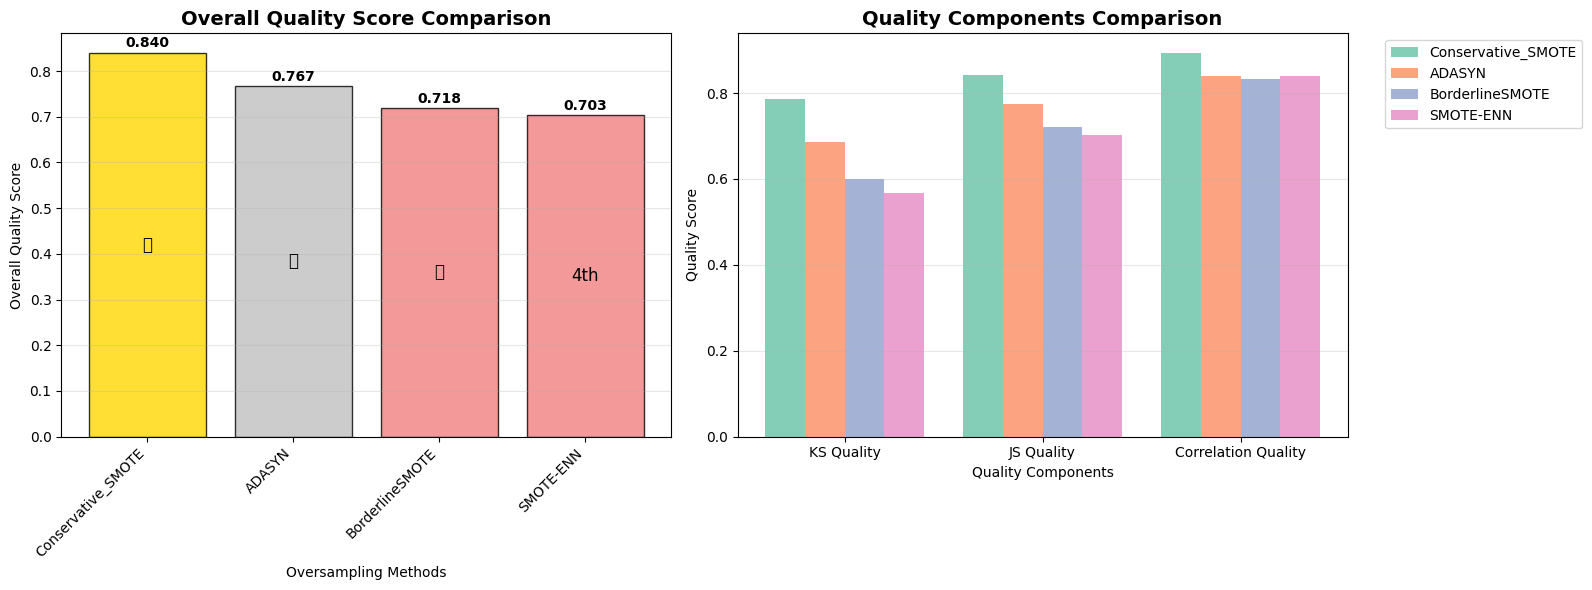


HOW TO ANALYZE SPECIFIC METHODS:

Now you can easily analyze any method by running:

For the best method (Conservative_SMOTE):
    analyze_oversampling_method('Conservative_SMOTE')

For the second best (ADASYN):
    analyze_oversampling_method('ADASYN')

For any other method:
    analyze_oversampling_method('method_name')
    
Available methods: SMOTE-ENN, BorderlineSMOTE, ADASYN, Conservative_SMOTE
    


In [37]:
# Easy Usage Examples - Analyze Any Oversampling Method
print("Usage Examples - How to Analyze Different Oversampling Methods")
print("=" * 64)

# Show available methods
if quality_assessments:
    available_methods = list(quality_assessments.keys())
    print(f"Available oversampling methods: {available_methods}")
    
    print(f"\n" + "="*50)
    print("USAGE EXAMPLES:")
    print("="*50)
    
    print(f"""
# Example 1: Analyze Conservative SMOTE
analyze_oversampling_method('Conservative_SMOTE')

# Example 2: Analyze ADASYN
analyze_oversampling_method('ADASYN')

# Example 3: Analyze BorderlineSMOTE
analyze_oversampling_method('BorderlineSMOTE')

# Example 4: Analyze SMOTE-ENN
analyze_oversampling_method('SMOTE-ENN')

# Example 5: Analyze with custom sample size
analyze_oversampling_method('ADASYN', max_viz_samples=2000)
    """)
    
    print(f"\n" + "="*50)
    print("QUICK COMPARISON FUNCTION:")
    print("="*50)
    
    # Create a quick comparison function
    def compare_methods(method_list=None, max_samples=1000):
        """
        Quick comparison of multiple methods side by side
        """
        if method_list is None:
            method_list = list(quality_assessments.keys())
        
        print(f"\nQuick Quality Comparison:")
        print("-" * 40)
        
        comparison_data = []
        for method in method_list:
            if method in quality_assessments:
                assessment = quality_assessments[method]
                scores = assessment['quality_scores']
                
                # Get best features
                ks_results = assessment['ks_results']
                best_ks_feature = min(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])
                best_ks_score = ks_results[best_ks_feature]['ks_statistic']
                
                js_results = assessment['js_results']
                best_js_feature = max(js_results.keys(), key=lambda x: js_results[x]['similarity_score'])
                best_js_score = js_results[best_js_feature]['similarity_score']
                
                comparison_data.append({
                    'Method': method,
                    'Overall_Score': scores['overall_quality'],
                    'KS_Quality': scores['ks_quality'],
                    'JS_Quality': scores['js_quality'],
                    'Corr_Quality': scores['correlation_quality'],
                    'Best_KS_Feature': best_ks_feature,
                    'Best_KS_Score': 1 - best_ks_score,  # Convert to quality score
                    'Best_JS_Feature': best_js_feature,
                    'Best_JS_Score': best_js_score
                })
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('Overall_Score', ascending=False)
        
        print(comparison_df.round(4).to_string(index=False))
        
        # Create quick visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Overall scores
        methods = comparison_df['Method']
        scores = comparison_df['Overall_Score']
        colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(methods))]
        
        bars = ax1.bar(range(len(methods)), scores, color=colors, alpha=0.8, edgecolor='black')
        ax1.set_title('Overall Quality Score Comparison', fontweight='bold', fontsize=14)
        ax1.set_xlabel('Oversampling Methods')
        ax1.set_ylabel('Overall Quality Score')
        ax1.set_xticks(range(len(methods)))
        ax1.set_xticklabels(methods, rotation=45, ha='right')
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, (bar, score) in enumerate(zip(bars, scores)):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
            
            # Add rank labels
            rank_text = '🥇' if i == 0 else '🥈' if i == 1 else '🥉' if i == 2 else f'{i+1}th'
            ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                    rank_text, ha='center', va='center', fontsize=12)
        
        # Component scores radar-like comparison
        components = ['KS_Quality', 'JS_Quality', 'Corr_Quality']
        x = np.arange(len(components))
        width = 0.2
        
        for i, method in enumerate(methods):
            method_data = comparison_df[comparison_df['Method'] == method].iloc[0]
            component_scores = [method_data[comp] for comp in components]
            
            ax2.bar(x + i*width, component_scores, width, label=method, alpha=0.8)
        
        ax2.set_title('Quality Components Comparison', fontweight='bold', fontsize=14)
        ax2.set_xlabel('Quality Components')
        ax2.set_ylabel('Quality Score')
        ax2.set_xticks(x + width * (len(methods)-1) / 2)
        ax2.set_xticklabels(['KS Quality', 'JS Quality', 'Correlation Quality'])
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        return comparison_df
    
    print(f"""
# Example: Compare all methods
comparison_results = compare_methods()

# Example: Compare specific methods
comparison_results = compare_methods(['Conservative_SMOTE', 'ADASYN'])

# Example: Compare with custom settings
comparison_results = compare_methods(max_samples=2000)
    """)
    
    print(f"\n" + "="*50)
    print("RUN QUICK COMPARISON:")
    print("="*50)
    
    # Run the comparison
    comparison_results = compare_methods()
    
    print(f"\n" + "="*50)
    print("HOW TO ANALYZE SPECIFIC METHODS:")
    print("="*50)
    
    print(f"""
Now you can easily analyze any method by running:

For the best method ({comparison_results.iloc[0]['Method']}):
    analyze_oversampling_method('{comparison_results.iloc[0]['Method']}')

For the second best ({comparison_results.iloc[1]['Method']}):
    analyze_oversampling_method('{comparison_results.iloc[1]['Method']}')

For any other method:
    analyze_oversampling_method('method_name')
    
Available methods: {', '.join(available_methods)}
    """)

else:
    print("No quality assessments available. Please run the evaluation first.")

In [38]:
def analyze_oversampling_method(method_name, max_viz_samples=10000):
    """
    Create focused visualizations for a specific oversampling method's quality metrics.
    
    Parameters:
    -----------
    method_name : str
        Name of the oversampling method to analyze (e.g., 'Conservative_SMOTE', 'ADASYN', etc.)
    max_viz_samples : int, default=1000
        Maximum number of samples to use for visualization
    
    Returns:
    --------
    dict: Assessment results for the method
    """
    
    if method_name not in quality_assessments:
        print(f"❌ Method '{method_name}' not found!")
        print(f"Available methods: {list(quality_assessments.keys())}")
        return None
    
    assessment = quality_assessments[method_name]
    
    print(f"📊 DETAILED ANALYSIS: {method_name}")
    print("=" * 80)
    
    # Overall quality summary
    scores = assessment['quality_scores']
    print(f"🎯 Overall Quality Score: {scores['overall_quality']:.4f}")
    print(f"📈 KS Quality Score: {scores['ks_quality']:.4f}")
    print(f"📉 JS Quality Score: {scores['js_quality']:.4f}")
    print(f"🔗 Correlation Quality Score: {scores['correlation_quality']:.4f}")
    print()
    
    # Get results
    ks_results = assessment['ks_results']
    js_results = assessment['js_results']
    corr_results = assessment['correlation_results']
    
    # Find best features for each metric
    best_ks_feature = min(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])
    best_js_feature = max(js_results.keys(), key=lambda x: js_results[x]['similarity_score'])
    
    print(f"🏆 Best KS Feature: {best_ks_feature} (KS stat: {ks_results[best_ks_feature]['ks_statistic']:.4f})")
    print(f"🏆 Best JS Feature: {best_js_feature} (Similarity: {js_results[best_js_feature]['similarity_score']:.4f})")
    print()
    
    # Create comprehensive visualizations
    fig = plt.figure(figsize=(20, 15))
    
    # Get original and oversampled data for this method
    if method_name == 'Conservative_SMOTE':
        X_method = X_conservative
        y_method = y_conservative
    elif method_name == 'ADASYN':
        X_method = X_adasyn
        y_method = y_adasyn
    elif method_name == 'BorderlineSMOTE':
        X_method = X_borderline
        y_method = y_borderline
    elif method_name == 'SMOTE-ENN':
        X_method = X_smote_enn
        y_method = y_smote_enn
    else:
        print(f"⚠️  Data for method '{method_name}' not available for visualization.")
        return assessment
    
    # Sample data for visualization if needed
    if len(X_method) > max_viz_samples:
        sample_idx = np.random.choice(len(X_method), max_viz_samples, replace=False)
        X_method_viz = X_method[sample_idx]
        y_method_viz = y_method[sample_idx]
    else:
        X_method_viz = X_method
        y_method_viz = y_method
    
    if len(X_train_original) > max_viz_samples:
        sample_idx_orig = np.random.choice(len(X_train_original), max_viz_samples, replace=False)
        X_orig_viz = X_train_original[sample_idx_orig]
        y_orig_viz = y_train_original[sample_idx_orig]
    else:
        X_orig_viz = X_train_original
        y_orig_viz = y_train_original
    
    # 1. Feature Distribution Comparison (Best KS Feature)
    plt.subplot(3, 4, 1)
    feature_idx = feature_names.index(best_ks_feature)
    
    orig_values = X_orig_viz[:, feature_idx]
    method_values = X_method_viz[:, feature_idx]
    
    plt.hist(orig_values, bins=30, alpha=0.7, label='Original', density=True, color='lightcoral')
    plt.hist(method_values, bins=30, alpha=0.7, label=method_name, density=True, color='lightblue')
    plt.title(f'Best KS Feature: {best_ks_feature}\nKS Stat: {ks_results[best_ks_feature]["ks_statistic"]:.4f}')
    plt.xlabel('Feature Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Feature Distribution Comparison (Best JS Feature)
    plt.subplot(3, 4, 2)
    feature_idx_js = feature_names.index(best_js_feature)
    
    orig_values_js = X_orig_viz[:, feature_idx_js]
    method_values_js = X_method_viz[:, feature_idx_js]
    
    plt.hist(orig_values_js, bins=30, alpha=0.7, label='Original', density=True, color='lightcoral')
    plt.hist(method_values_js, bins=30, alpha=0.7, label=method_name, density=True, color='lightblue')
    plt.title(f'Best JS Feature: {best_js_feature}\nSimilarity: {js_results[best_js_feature]["similarity_score"]:.4f}')
    plt.xlabel('Feature Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. ECDF Comparison (Best KS Feature)
    plt.subplot(3, 4, 3)
    sorted_orig = np.sort(orig_values)
    sorted_method = np.sort(method_values)
    
    y_orig = np.arange(1, len(sorted_orig) + 1) / len(sorted_orig)
    y_method = np.arange(1, len(sorted_method) + 1) / len(sorted_method)
    
    plt.plot(sorted_orig, y_orig, label='Original', linewidth=2, color='red')
    plt.plot(sorted_method, y_method, label=method_name, linewidth=2, color='blue')
    plt.title(f'ECDF Comparison: {best_ks_feature}')
    plt.xlabel('Feature Value')
    plt.ylabel('Cumulative Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. ECDF Comparison (Best JS Feature)
    plt.subplot(3, 4, 4)
    sorted_orig_js = np.sort(orig_values_js)
    sorted_method_js = np.sort(method_values_js)
    
    y_orig_js = np.arange(1, len(sorted_orig_js) + 1) / len(sorted_orig_js)
    y_method_js = np.arange(1, len(sorted_method_js) + 1) / len(sorted_method_js)
    
    plt.plot(sorted_orig_js, y_orig_js, label='Original', linewidth=2, color='red')
    plt.plot(sorted_method_js, y_method_js, label=method_name, linewidth=2, color='blue')
    plt.title(f'ECDF Comparison: {best_js_feature}')
    plt.xlabel('Feature Value')
    plt.ylabel('Cumulative Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 5. Quality Scores Radar Chart
    plt.subplot(3, 4, 5)
    categories = ['KS Quality', 'JS Quality', 'Correlation Quality']
    values = [scores['ks_quality'], scores['js_quality'], scores['correlation_quality']]
    
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False)
    values_plot = values + [values[0]]  # Complete the circle
    angles_plot = list(angles) + [angles[0]]
    
    plt.polar(angles_plot, values_plot, 'o-', linewidth=2, color='purple')
    plt.fill(angles_plot, values_plot, alpha=0.25, color='purple')
    plt.xticks(angles, categories)
    plt.title(f'{method_name} Quality Profile\nOverall: {scores["overall_quality"]:.4f}')
    plt.ylim(0, 1)
    
    # 6. Class Distribution
    plt.subplot(3, 4, 6)
    unique_orig, counts_orig = np.unique(y_orig_viz, return_counts=True)
    unique_method, counts_method = np.unique(y_method_viz, return_counts=True)
    
    width = 0.35
    x = np.arange(len(unique_orig))
    
    plt.bar(x - width/2, counts_orig, width, label='Original', alpha=0.8, color='lightcoral')
    plt.bar(x + width/2, counts_method, width, label=method_name, alpha=0.8, color='lightblue')
    plt.title('Class Distribution Comparison')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(x, unique_orig)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. Feature Quality Heatmap (Top 10 features)
    plt.subplot(3, 4, 7)
    top_features = sorted(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])[:10]
    
    heatmap_data = []
    for feature in top_features:
        ks_score = 1 - ks_results[feature]['ks_statistic']  # Convert to quality score
        js_score = js_results[feature]['similarity_score']
        heatmap_data.append([ks_score, js_score])
    
    heatmap_array = np.array(heatmap_data)
    im = plt.imshow(heatmap_array.T, cmap='viridis', aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title('Top 10 Features Quality Heatmap')
    plt.ylabel('Metrics')
    plt.xlabel('Features')
    plt.xticks(range(len(top_features)), [f.replace('_', '\n') for f in top_features], rotation=45, ha='right')
    plt.yticks(range(2), ['KS Quality', 'JS Quality'])
    
    # 8. Correlation Preservation Analysis
    plt.subplot(3, 4, 8)
    preservation_score = corr_results['correlation_preservation_score']
    
    categories = ['Preserved', 'Lost']
    values = [preservation_score, 1 - preservation_score]
    colors = ['green', 'red']
    
    wedges, texts, autotexts = plt.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title(f'Correlation Preservation\nScore: {preservation_score:.4f}')
    
    # 9-12. Top 4 Features Individual Analysis
    top_4_features = sorted(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])[:4]
    
    for i, feature in enumerate(top_4_features):
        plt.subplot(3, 4, 9 + i)
        
        feature_idx = feature_names.index(feature)
        orig_vals = X_orig_viz[:, feature_idx]
        method_vals = X_method_viz[:, feature_idx]
        
        # Box plot comparison
        box_data = [orig_vals, method_vals]
        box_labels = ['Original', method_name]
        
        bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightblue')
        
        plt.title(f'{feature}\nKS: {ks_results[feature]["ks_statistic"]:.3f}')
        plt.ylabel('Value')
        plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'Comprehensive Quality Analysis: {method_name}', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # Print detailed feature analysis
    print(f"\n📋 DETAILED FEATURE ANALYSIS")
    print("-" * 50)
    
    # Top 5 features by KS quality
    top_5_ks = sorted(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])[:5]
    print(f"🏆 Top 5 Features by KS Quality:")
    for i, feature in enumerate(top_5_ks, 1):
        ks_stat = ks_results[feature]['ks_statistic']
        quality_score = 1 - ks_stat
        print(f"  {i}. {feature}: {quality_score:.4f} (KS stat: {ks_stat:.4f})")
    
    print()
    
    # Top 5 features by JS quality
    top_5_js = sorted(js_results.keys(), key=lambda x: js_results[x]['similarity_score'], reverse=True)[:5]
    print(f"🏆 Top 5 Features by JS Quality:")
    for i, feature in enumerate(top_5_js, 1):
        js_score = js_results[feature]['similarity_score']
        print(f"  {i}. {feature}: {js_score:.4f}")
    
    print()
    print(f"🔗 Correlation Preservation: {corr_results['correlation_preservation_score']:.4f}")
    print(f"📊 Overall Quality Assessment: {scores['overall_quality']:.4f}")
    
    return assessment

# Example usage guide
print("🚀 REUSABLE OVERSAMPLING ANALYSIS FUNCTION READY!")
print("=" * 60)
print("Usage Examples:")
print("1. analyze_oversampling_method('Conservative_SMOTE')")
print("2. analyze_oversampling_method('ADASYN')")
print("3. analyze_oversampling_method('BorderlineSMOTE')")
print("4. analyze_oversampling_method('SMOTE-ENN')")
print("5. analyze_oversampling_method('ADASYN', max_viz_samples=2000)")
print("=" * 60)

🚀 REUSABLE OVERSAMPLING ANALYSIS FUNCTION READY!
Usage Examples:
1. analyze_oversampling_method('Conservative_SMOTE')
2. analyze_oversampling_method('ADASYN')
3. analyze_oversampling_method('BorderlineSMOTE')
4. analyze_oversampling_method('SMOTE-ENN')
5. analyze_oversampling_method('ADASYN', max_viz_samples=2000)


🎯 DEMONSTRATION: Analyzing Conservative SMOTE
📊 DETAILED ANALYSIS: SMOTE-ENN
🎯 Overall Quality Score: 0.7032
📈 KS Quality Score: 0.5666
📉 JS Quality Score: 0.7024
🔗 Correlation Quality Score: 0.8405

🏆 Best KS Feature: DATA_R (KS stat: 0.1024)
🏆 Best JS Feature: Expaned Energy (Similarity: 0.8683)



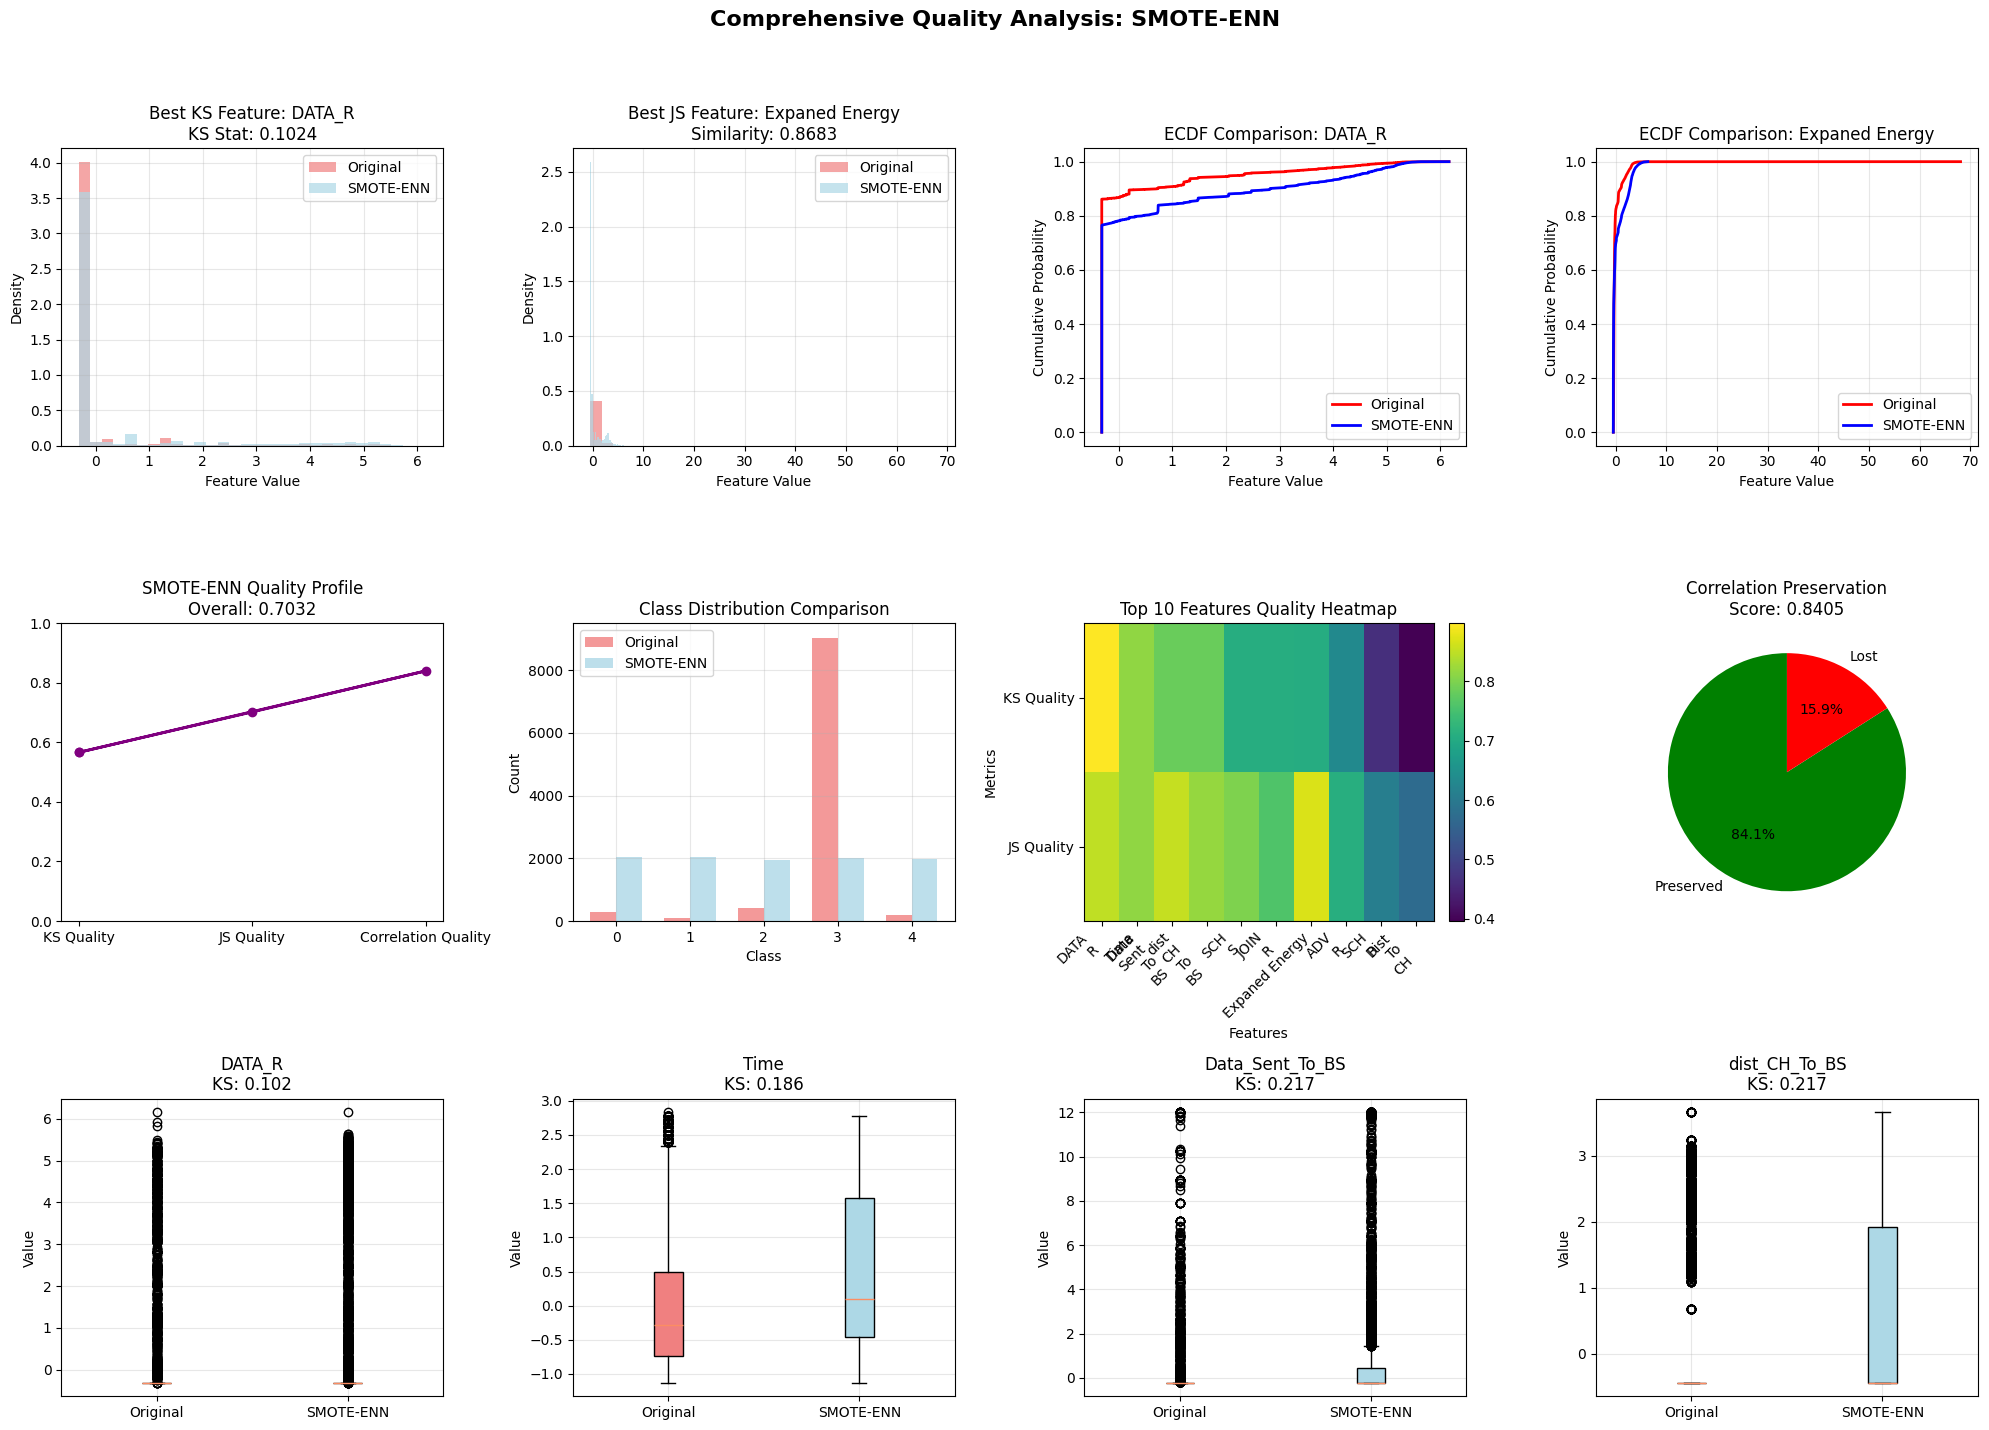


📋 DETAILED FEATURE ANALYSIS
--------------------------------------------------
🏆 Top 5 Features by KS Quality:
  1. DATA_R: 0.8976 (KS stat: 0.1024)
  2. Time: 0.8137 (KS stat: 0.1863)
  3. Data_Sent_To_BS: 0.7834 (KS stat: 0.2166)
  4. dist_CH_To_BS: 0.7834 (KS stat: 0.2166)
  5. SCH_S: 0.7082 (KS stat: 0.2918)

🏆 Top 5 Features by JS Quality:
  1. Expaned Energy: 0.8683
  2. Data_Sent_To_BS: 0.8527
  3. DATA_R: 0.8494
  4. dist_CH_To_BS: 0.8174
  5. Time: 0.8146

🔗 Correlation Preservation: 0.8405
📊 Overall Quality Assessment: 0.7032


In [40]:
# Demo: Analyze Conservative SMOTE (the best performing method)
print("🎯 DEMONSTRATION: Analyzing Conservative SMOTE")
print("=" * 50)

conservative_analysis = analyze_oversampling_method('SMOTE-ENN')

In [29]:
# Check the structure of quality_assessments to debug the key error
print("🔍 DEBUGGING: Checking quality_assessments structure")
print("=" * 50)

if quality_assessments:
    method_name = 'Conservative_SMOTE'
    if method_name in quality_assessments:
        assessment = quality_assessments[method_name]
        print(f"Keys in {method_name} assessment:")
        for key in assessment.keys():
            print(f"  - {key}: {type(assessment[key])}")
            
        print(f"\nDetailed structure:")
        for key, value in assessment.items():
            if isinstance(value, dict):
                print(f"{key}: {list(value.keys())}")
            else:
                print(f"{key}: {value}")
    else:
        print(f"Available methods: {list(quality_assessments.keys())}")
else:
    print("No quality_assessments available!")

🔍 DEBUGGING: Checking quality_assessments structure
Keys in Conservative_SMOTE assessment:
  - strategy_name: <class 'str'>
  - ks_results: <class 'dict'>
  - js_results: <class 'dict'>
  - correlation_results: <class 'dict'>
  - quality_scores: <class 'dict'>

Detailed structure:
strategy_name: Conservative_SMOTE
ks_results: ['Time', 'Is_CH', 'Dist_To_CH', 'ADV_S', 'ADV_R', 'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S', 'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code', 'Expaned Energy']
js_results: ['Time', 'Is_CH', 'Dist_To_CH', 'ADV_S', 'ADV_R', 'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S', 'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code', 'Expaned Energy']
correlation_results: ['mean_absolute_error', 'max_absolute_error', 'correlation_correlation', 'correlation_preservation_score', 'original_correlation_matrix', 'oversampled_correlation_matrix']
quality_scores: ['ks_quality', 'js_quality', 'correlation_quality', 'overall_quality']


In [32]:
# Create a quick method comparison function for easy analysis
def quick_method_comparison():
    """
    Quick comparison of all oversampling methods showing key metrics
    """
    print("🏆 QUICK METHOD COMPARISON")
    print("=" * 60)
    
    if not quality_assessments:
        print("❌ No quality assessments available!")
        return
    
    comparison_data = []
    for method_name, assessment in quality_assessments.items():
        scores = assessment['quality_scores']
        
        # Get best features
        ks_results = assessment['ks_results']
        js_results = assessment['js_results']
        corr_results = assessment['correlation_results']
        
        best_ks_feature = min(ks_results.keys(), key=lambda x: ks_results[x]['ks_statistic'])
        best_ks_score = 1 - ks_results[best_ks_feature]['ks_statistic']
        
        best_js_feature = max(js_results.keys(), key=lambda x: js_results[x]['similarity_score'])
        best_js_score = js_results[best_js_feature]['similarity_score']
        
        comparison_data.append({
            'Method': method_name,
            'Overall_Score': scores['overall_quality'],
            'KS_Quality': scores['ks_quality'],
            'JS_Quality': scores['js_quality'],
            'Correlation_Quality': scores['correlation_quality'],
            'Best_KS_Feature': best_ks_feature,
            'Best_KS_Score': best_ks_score,
            'Best_JS_Feature': best_js_feature,
            'Best_JS_Score': best_js_score,
            'Correlation_Preservation': corr_results['correlation_preservation_score']
        })
    
    # Sort by overall score
    comparison_data.sort(key=lambda x: x['Overall_Score'], reverse=True)
    
    # Display ranking
    print("🥇 RANKING BY OVERALL QUALITY:")
    print("-" * 40)
    for i, data in enumerate(comparison_data, 1):
        rank_emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else f"{i}️⃣"
        print(f"{rank_emoji} {data['Method']}: {data['Overall_Score']:.4f}")
    
    print(f"\n🔍 DETAILED METRICS:")
    print("-" * 40)
    
    for data in comparison_data:
        print(f"\n📊 {data['Method']}:")
        print(f"   Overall Quality: {data['Overall_Score']:.4f}")
        print(f"   KS Quality: {data['KS_Quality']:.4f}")
        print(f"   JS Quality: {data['JS_Quality']:.4f}")
        print(f"   Correlation Quality: {data['Correlation_Quality']:.4f}")
        print(f"   Best KS Feature: {data['Best_KS_Feature']} ({data['Best_KS_Score']:.4f})")
        print(f"   Best JS Feature: {data['Best_JS_Feature']} ({data['Best_JS_Score']:.4f})")
        print(f"   Correlation Preservation: {data['Correlation_Preservation']:.4f}")
    
    return comparison_data

# Run the comparison
print("🚀 RUNNING QUICK COMPARISON OF ALL METHODS")
print("=" * 60)
comparison_results = quick_method_comparison()

print(f"\n\n💡 USAGE RECOMMENDATIONS:")
print("=" * 60)
print(f"🏆 Best performing method: {comparison_results[0]['Method']}")
print(f"📊 Best overall quality score: {comparison_results[0]['Overall_Score']:.4f}")
print()
print("📋 To analyze any method in detail, use:")
for method_data in comparison_results:
    method_name = method_data['Method']
    print(f"   analyze_oversampling_method('{method_name}')")

print(f"\n🎯 RECOMMENDED ANALYSIS:")
print("=" * 40)
print(f"# Analyze the best method:")
print(f"analyze_oversampling_method('{comparison_results[0]['Method']}')")
print()
print(f"# Compare top 2 methods by analyzing them separately:")
print(f"analyze_oversampling_method('{comparison_results[0]['Method']}')")
print(f"analyze_oversampling_method('{comparison_results[1]['Method']}')")

🚀 RUNNING QUICK COMPARISON OF ALL METHODS
🏆 QUICK METHOD COMPARISON
🥇 RANKING BY OVERALL QUALITY:
----------------------------------------
🥇 Conservative_SMOTE: 0.8404
🥈 ADASYN: 0.7666
🥉 BorderlineSMOTE: 0.7184
4️⃣ SMOTE-ENN: 0.7032

🔍 DETAILED METRICS:
----------------------------------------

📊 Conservative_SMOTE:
   Overall Quality: 0.8404
   KS Quality: 0.7855
   JS Quality: 0.8413
   Correlation Quality: 0.8945
   Best KS Feature: DATA_R (0.9492)
   Best JS Feature: Expaned Energy (0.9231)
   Correlation Preservation: 0.8945

📊 ADASYN:
   Overall Quality: 0.7666
   KS Quality: 0.6871
   JS Quality: 0.7736
   Correlation Quality: 0.8392
   Best KS Feature: DATA_R (0.9450)
   Best JS Feature: SCH_S (0.9527)
   Correlation Preservation: 0.8392

📊 BorderlineSMOTE:
   Overall Quality: 0.7184
   KS Quality: 0.6006
   JS Quality: 0.7208
   Correlation Quality: 0.8338
   Best KS Feature: DATA_R (0.8560)
   Best JS Feature: SCH_S (0.8999)
   Correlation Preservation: 0.8338

📊 SMOTE-ENN:
 

🎯 DEMONSTRATION: Reusable Function with ADASYN
📊 DETAILED ANALYSIS: ADASYN
🎯 Overall Quality Score: 0.7666
📈 KS Quality Score: 0.6871
📉 JS Quality Score: 0.7736
🔗 Correlation Quality Score: 0.8392

🏆 Best KS Feature: DATA_R (KS stat: 0.0550)
🏆 Best JS Feature: SCH_S (Similarity: 0.9527)



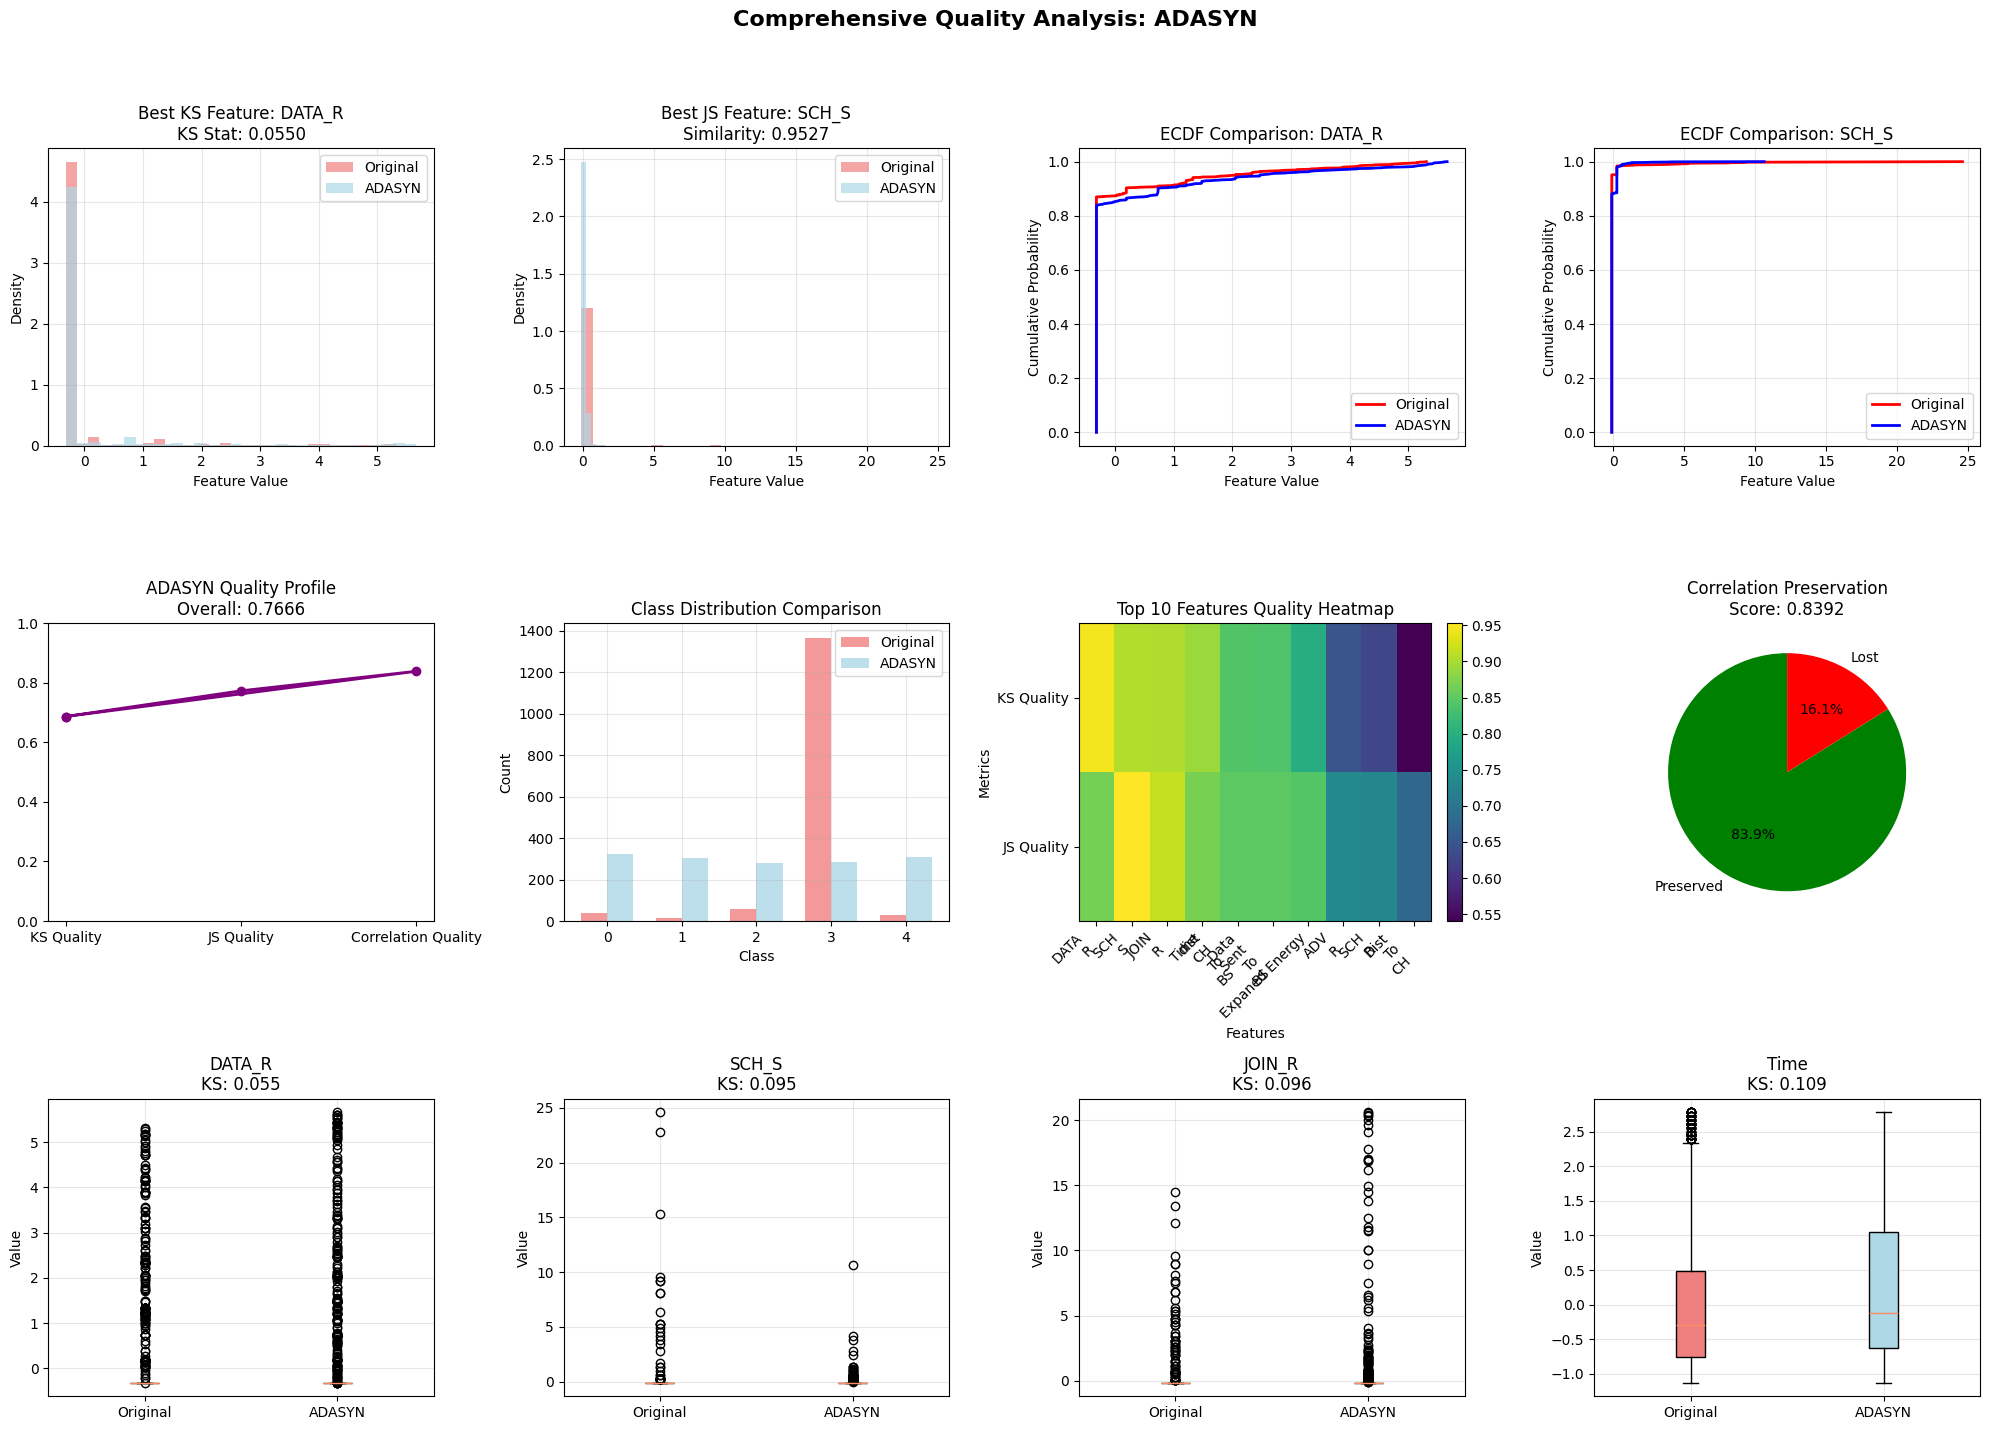


📋 DETAILED FEATURE ANALYSIS
--------------------------------------------------
🏆 Top 5 Features by KS Quality:
  1. DATA_R: 0.9450 (KS stat: 0.0550)
  2. SCH_S: 0.9050 (KS stat: 0.0950)
  3. JOIN_R: 0.9042 (KS stat: 0.0958)
  4. Time: 0.8913 (KS stat: 0.1087)
  5. dist_CH_To_BS: 0.8406 (KS stat: 0.1594)

🏆 Top 5 Features by JS Quality:
  1. SCH_S: 0.9527
  2. JOIN_R: 0.9161
  3. Time: 0.8688
  4. DATA_R: 0.8665
  5. Data_Sent_To_BS: 0.8490

🔗 Correlation Preservation: 0.8392
📊 Overall Quality Assessment: 0.7666


In [33]:
# Demonstrate reusability: Analyze ADASYN (2nd best method)
print("🎯 DEMONSTRATION: Reusable Function with ADASYN")
print("=" * 50)

adasyn_analysis = analyze_oversampling_method('ADASYN', max_viz_samples=1500)